# Caso 2 · Terremoto en Colombia (10-ago-2026)
## Notebook 02 — Red temporal de campamentos: modelo MILP en PuLP

**Universidad de La Sabana · Diseño y Gestión de la Cadena de Suministro · Prof. Gonzalo Mejía**

El modelo decide **qué campamentos habilitar** y **cómo asignar** a la población que perdió su vivienda, con capacidad
limitada, un presupuesto máximo y una distancia máxima de traslado de 180 km por carretera.

| Sección | Contenido |
|---|---|
| 1. Configuración y datos | Lectura de `data/processed/` (generado por el notebook 01) |
| 2. Diagnóstico de la instancia | Órdenes de magnitud: ¿qué recurso es escaso? |
| 3. Validación previa | Pruebas automáticas de los datos y módulo de calidad de datos (PASS / WARNING / FAIL; objetivo 0 FAIL) |
| 4. Formulación matemática | Conjuntos, parámetros, variables, objetivo, restricciones y dominios |
| 5. Implementación en PuLP | Formulación indexada con estructuras de datos y ciclos |
| 6. Escenario base | Apertura, asignación, utilización, cobertura, costos, distancias y umbrales |
| 7. ¿Por qué esta red? ¿Es trivial? | Costo por plaza, presupuesto hasta ×4, restricciones activas, umbral de distancia, redes casi óptimas y contrafactual |
| 8. Escenarios de presupuesto | −15 % y −30 % (decisión del grupo) + −20 % y −25 % para la curva |
| 9. Sensibilidad | Lecturas pendientes del profesor (sin pequeños con $B$ conservado o recalculado; R4' solo costos fijos), fracción $f$, tamaño de hogar, costo fijo $c_f$ (con $B$ que escala y con $B$ fijo), economías de escala, fuente de distancias (incluye 48 pares de 140–160 km), reserva y tarifa |
| 10. Extensión propia | Equidad territorial: piso municipal $\beta$ (familia E3, **variante recomendada**) y piso departamental $\alpha$ (nueva variable + familia E1, complemento) |
| 11. Auditoría y exportación | Registro del solver, uso de los arcos frágiles (cambian de factibilidad con Google Maps), tablas CSV, `resultados_modelo.xlsx` y figuras |
| 12. Conclusiones | Lectura de resultados, limitaciones y pendientes |

Convención de lectura: **Resultado matemático** = lo que entrega el modelo; **Interpretación** = lectura humanitaria.

## 1. Configuración y datos

**Instalación.** La primera celda instala `pulp>=2.8,<4` y `highspy` **solo si faltan** (o si hay un PuLP 4 instalado, que rompe la
API: en PuLP 4.0.0 no existen `PULP_CBC_CMD`, `LpStatus`, `LpStatusOptimal` ni `LpSolutionOptimal`, `LpVariable` no acepta `cat=` y
no tiene `.dicts`). Versiones probadas: **Python 3.13, PuLP 3.3.2 (con CBC incluido) y highspy 1.15.1 (HiGHS)**; el código también
funciona con PuLP ≥ 2.8 (desde esa versión existe `pulp.HiGHS`).

**Modo rápido.** Con `RAPIDO = True` el notebook omite las cuadrículas largas (curva de presupuesto completa con pruebas de
relajación, las 72 × 2 combinaciones de $c_f$, el barrido completo de distancia y la enumeración de 5 redes) y guarda todo en
`results/rapido/`, sin tocar los resultados oficiales. Sirve para revisar el código en pocos minutos; **las cifras oficiales salen
siempre con `RAPIDO = False`** (≈ 11 min).

In [1]:
# Instala lo que falte (requiere internet). Si había un PuLP ≥ 4 ya importado, reinicie el kernel después de esta celda.
import importlib.metadata as _md, importlib.util as _iu, subprocess as _sp, sys as _sys
def _version(paquete):
    try:
        return _md.version(paquete)
    except _md.PackageNotFoundError:
        return None
_v_pulp, _v_highs = _version("pulp"), _version("highspy")
if _v_pulp is None or int(_v_pulp.split(".")[0]) >= 4 or _iu.find_spec("highspy") is None:
    print(f"Instalando pulp>=2.8,<4 y highspy (encontrado: pulp {_v_pulp}, highspy {_v_highs})…")
    _sp.check_call([_sys.executable, "-m", "pip", "install", "-q", "pulp>=2.8,<4", "highspy"])
    print("Listo. Si PuLP ya estaba importado en este kernel, reinícielo antes de continuar.")
else:
    print(f"Dependencias presentes: pulp {_v_pulp}, highspy {_v_highs}")

Dependencias presentes: pulp 3.3.2, highspy 1.15.1


In [2]:
import json, time, platform, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import pulp
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker
from matplotlib.lines import Line2D
from IPython.display import display, Markdown
warnings.filterwarnings("ignore")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC, RAW = ROOT / "data" / "processed", ROOT / "data" / "raw"
RAPIDO = False              # True: omite las cuadrículas largas y escribe en results/rapido/ (ver arriba)
SALIDA = ROOT / "results" / ("rapido" if RAPIDO else "")
TAB, FIG = SALIDA / "tablas", SALIDA / "figuras"
for p in (TAB, FIG):
    p.mkdir(parents=True, exist_ok=True)

LIMITE_TIEMPO = 600        # segundos por resolución del solver (si se alcanza, el resultado NO se reporta como óptimo y el notebook se detiene)
HILOS = 2                  # hilos del solver
ESCALA = 1e6               # los costos entran al modelo en millones de COP (estabilidad numérica)
# Umbrales de distancia definidos por el grupo para reportar cobertura (justificación en la sección 6.4):
#  50 km: traslado corto dentro del área metropolitana o a un municipio vecino (≈ 1 h por carretera), sin pernoctar en ruta;
# 100 km: traslado intradepartamental típico (≈ 2 h), compatible con mantener vínculos con el municipio de origen;
# 150 km: traslado interdepartamental o de montaña (≈ 3 h), el último umbral antes del límite;
# 180 km: distancia máxima del enunciado (R5); por construcción, el 100 % de los atendidos queda dentro.
UMBRALES_KM = [50, 100, 150, 180]
COL_DEP = {"Valle del Cauca": "#1f77b4", "Risaralda": "#d62728", "Caldas": "#2ca02c", "Quindío": "#9467bd"}
VERDE, GRIS, ROJO, NARANJA, AZUL = "#2e7d32", "#9e9e9e", "#c62828", "#ef6c00", "#1565c0"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})

def md(t): display(Markdown(t))
def es(x, d=0):
    """Formato colombiano: punto de miles y coma decimal."""
    return f"{x:,.{d}f}".replace(",", "X").replace(".", ",").replace("X", ".")
def mcop(x, d=1): return f"${es(x / 1e6, d)} M"
def pct(x, d=1): return es(100 * x, d) + " %"
def pct_abajo(x, d=1):
    """Porcentaje truncado hacia abajo: para pisos máximos (α*, β*) redondear hacia arriba daría un valor infactible."""
    return pct(np.floor(x * 10 ** (d + 2) + 1e-9) / 10 ** (d + 2), d)

print(f"Python {platform.python_version()} · pandas {pd.__version__} · PuLP {pulp.__version__} · matplotlib {matplotlib.__version__}")
print("Solvers disponibles:", pulp.listSolvers(onlyAvailable=True))

Python 3.13.16 · pandas 3.0.5 · PuLP 3.3.2 · matplotlib 3.11.2
Solvers disponibles: ['PULP_CBC_CMD', 'HiGHS']


In [3]:
dem = pd.read_csv(PROC / "demanda.csv", dtype={"divipola": str}).set_index("id")
cand = pd.read_csv(PROC / "candidatos.csv", dtype={"divipola": str}).set_index("id")
dist = pd.read_csv(PROC / "distancias_km.csv", index_col=0)          # matriz final (Google Maps en pares verificados + OSRM)
dist_osrm = pd.read_csv(PROC / "distancias_km_osrm.csv", index_col=0)  # solo para la sensibilidad a la fuente de distancias
dist_alt = pd.read_csv(PROC / "distancias_km_alt_google_140_160.csv", index_col=0)  # sensibilidad: + 48 pares Google de 140–160 km
meta = json.load(open(PROC / "metadatos_instancia.json", encoding="utf-8"))
assert list(dist.index) == list(dem.index) and list(dist.columns) == list(cand.index)

TARIFA = meta["tarifa_COP_km_persona"]          # 500 COP por km-persona
V_KIT = meta["costo_variable_COP_persona"]      # v = 60.000 COP = kit de alimentación + kit de aseo (redondeado)
D_MAX = meta["distancia_max_km"]                # 180 km
B_BASE = meta["presupuesto_base_COP"]           # 50 % del costo fijo de los 10 candidatos más grandes
RED_A, RED_B = meta["reduccion_A"], meta["reduccion_B"]
KIT_ALIM = meta["costo_kit_alimentacion_COP"]   # 29.730 COP: kit de alimentación por persona (F06)
KIT_ASEO = meta["costo_kit_aseo_COP"]           # 29.730 COP: kit de aseo por persona (F06)
AJUSTE_KITS = meta["ajuste_redondeo_kits_COP"]  # 540 COP: v = 60.000 es el redondeo declarado de 59.460
assert KIT_ALIM + KIT_ASEO + AJUSTE_KITS == V_KIT

NOM = {**dem.municipio.to_dict(), **cand.municipio.to_dict()}
DEP = dem.departamento.to_dict()
md(f"**Instancia:** {len(dem)} municipios afectados · {(cand.rol=='Candidato').sum()} candidatos + 1 reserva · "
   f"presupuesto base **{mcop(B_BASE)}** · distancias: {meta['fuente_distancias']}.")

**Instancia:** 29 municipios afectados · 17 candidatos + 1 reserva · presupuesto base **$3.547,5 M** · distancias: Por carretera: Google Maps en 164 pares verificados (1-oct-2026) y OSRM/OpenStreetMap en el resto (30-sep-2026).

## 2. Diagnóstico de la instancia: ¿qué recurso es escaso?
Antes de optimizar conviene saber qué tan lejos está la red de poder atender a todos.

In [4]:
base_c = cand[cand.rol == "Candidato"]
costo_plaza = (base_c.costo_fijo_fj / base_c.capacidad_K).groupby(base_c.categoria).first()
diag = pd.Series({
    "Demanda base Σd_i (f = 10 %)": dem.d_f10.sum(),
    "Capacidad de los 17 candidatos ΣK_j": base_c.capacidad_K.sum(),
    "Presupuesto base B (M COP)": B_BASE / 1e6,
    "Costo fijo por plaza – Grande (COP)": costo_plaza["Grande"],
    "Costo fijo por plaza – Intermedia (COP)": costo_plaza["Intermedia"],
    "Costo fijo por plaza – Pequeña (COP)": costo_plaza["Pequeña"],
    "Kits por persona (COP)": V_KIT,
    "Transporte de 60 km (COP/persona)": 60 * TARIFA,
})
cota = B_BASE / (costo_plaza["Grande"] + V_KIT + 60 * TARIFA)
diag["Cota aprox. de personas atendibles con B (campamentos grandes llenos, 60 km)"] = cota
diag["Cota / demanda"] = cota / dem.d_f10.sum()
display(diag.to_frame("Valor").style.format(lambda v: es(v, 2) if abs(v) < 10 else es(v)))
md(f"**Lectura:** aun usando solo las plazas más baratas, el presupuesto alcanza para unas **{es(cota)} personas** (cota aproximada "
   f"de **{pct(cota / dem.d_f10.sum(), 0)}** de la demanda base; el óptimo exacto se calcula en la sección 6). La capacidad total ({es(base_c.capacidad_K.sum())}) tampoco cubriría "
   f"a todos ({es(dem.d_f10.sum())}). Por eso exigir atención total haría el modelo infactible y minimizar costo sin más daría la "
   "solución trivial de no abrir nada: el objetivo debe **maximizar la población atendida**.")

,Valor
Demanda base Σd_i (f = 10 %),18.880
Capacidad de los 17 candidatos ΣK_j,16.000
Presupuesto base B (M COP),3.548
Costo fijo por plaza – Grande (COP),510.000
Costo fijo por plaza – Intermedia (COP),600.000
Costo fijo por plaza – Pequeña (COP),690.000
Kits por persona (COP),60.000
Transporte de 60 km (COP/persona),30.000
"Cota aprox. de personas atendibles con B (campamentos grandes llenos, 60 km)",5.912
Cota / demanda,"0,31"


**Lectura:** aun usando solo las plazas más baratas, el presupuesto alcanza para unas **5.912 personas** (cota aproximada de **31 %** de la demanda base; el óptimo exacto se calcula en la sección 6). La capacidad total (16.000) tampoco cubriría a todos (18.880). Por eso exigir atención total haría el modelo infactible y minimizar costo sin más daría la solución trivial de no abrir nada: el objetivo debe **maximizar la población atendida**.

## 3. Validación previa de los datos
Si alguna prueba crítica falla, el notebook se detiene.

In [5]:
A_base = [(i, j) for i in dem.index for j in base_c.index if dist.loc[i, j] <= D_MAX]
pruebas = [
    ("Al menos 20 puntos de demanda", len(dem) >= 20, f"{len(dem)}", "FAIL"),
    ("Cali y Pereira incluidos", {"Cali", "Pereira"} <= set(dem.municipio), "", "FAIL"),
    ("Al menos 15 candidatos", len(base_c) >= 15, f"{len(base_c)}", "FAIL"),
    ("Al menos 15 candidatos útiles (≥1 municipio a ≤180 km)", len({j for _, j in A_base}) >= 15, f"{len({j for _, j in A_base})}", "FAIL"),
    ("Candidatos fuera de los 29 municipios de demanda (afectados)", not (set(dem.divipola) & set(cand.divipola)), "", "FAIL"),
    ("Capacidades 3.000 / 1.000 / 500 según categoría",
     all({"Grande": 3000, "Intermedia": 1000, "Pequeña": 500}[c] == k for c, k in zip(cand.categoria, cand.capacidad_K)), "", "FAIL"),
    ("Demanda, capacidad y costos positivos", (dem.d_f10 > 0).all() and (cand.capacidad_K > 0).all() and (cand.costo_fijo_fj > 0).all(), "", "FAIL"),
    ("Matriz de distancias completa", dist.notna().all().all(), f"{dist.size} pares", "FAIL"),
    ("Cada municipio tiene ≥1 candidato a ≤180 km", all(any(a[0] == i for a in A_base) for i in dem.index), "", "FAIL"),
    ("Presupuesto = 50 % del costo fijo de los 10 más grandes",
     abs(B_BASE - 0.5 * base_c.sort_values("capacidad_K", ascending=False).costo_fijo_fj.head(10).sum()) < 1, mcop(B_BASE), "FAIL"),
    ("Solo ciudades intermedias o grandes (literal del enunciado)", (base_c.categoria != "Pequeña").all(),
     f"{(base_c.categoria=='Pequeña').sum()} candidatos pequeños: decisión del grupo pendiente de confirmar con el profesor", "WARNING"),
]
val = pd.DataFrame([(n, "PASS" if ok else nivel, det) for n, ok, det, nivel in pruebas], columns=["Prueba", "Resultado", "Detalle"])
colorear = lambda v: {"PASS": "background-color:#c6efce", "WARNING": "background-color:#ffeb9c", "FAIL": "background-color:#ffc7ce"}[v]
display(val.style.map(colorear, subset=["Resultado"]).hide(axis="index"))
if (val.Resultado == "FAIL").any():
    raise RuntimeError("Hay errores críticos en los datos.")

# Módulo de calidad de datos (tools/calidad_datos.py): se recalcula sobre data/processed y debe coincidir con la tabla que
# generó el notebook 01 (results/tablas/calidad_datos.csv). Con algún FAIL el modelo no se corre.
import sys
sys.path.insert(0, str(ROOT / "tools"))
from calidad_datos import evaluar as evaluar_calidad, resumen as resumen_calidad
CALIDAD = evaluar_calidad(ROOT)
guardada = pd.read_csv(ROOT / "results" / "tablas" / "calidad_datos.csv")   # generada por el notebook 01
assert CALIDAD[["id", "resultado", "detalle"]].equals(guardada[["id", "resultado", "detalle"]]), "Calidad de datos distinta a la del notebook 01: vuelva a ejecutarlo"
RES_Q = resumen_calidad(CALIDAD)
md(f"**Calidad de datos:** {RES_Q['PASS']} PASS · {RES_Q['WARNING']} WARNING · **{RES_Q['FAIL']} FAIL**. Los WARNING son debilidades "
   "declaradas (no detienen el modelo); el detalle está en la hoja `Calidad_datos` del Excel.")
display(CALIDAD[CALIDAD.resultado != "PASS"][["id", "prueba", "resultado", "detalle"]].style.map(colorear, subset=["resultado"]).hide(axis="index"))
if RES_Q["FAIL"]:
    raise RuntimeError("La calidad de datos tiene pruebas FAIL: corrija los datos antes de optimizar.")

Prueba,Resultado,Detalle
Al menos 20 puntos de demanda,PASS,29
Cali y Pereira incluidos,PASS,
Al menos 15 candidatos,PASS,17
Al menos 15 candidatos útiles (≥1 municipio a ≤180 km),PASS,17
Candidatos fuera de los 29 municipios de demanda (afectados),PASS,
Capacidades 3.000 / 1.000 / 500 según categoría,PASS,
"Demanda, capacidad y costos positivos",PASS,
Matriz de distancias completa,PASS,522 pares
Cada municipio tiene ≥1 candidato a ≤180 km,PASS,
Presupuesto = 50 % del costo fijo de los 10 más grandes,PASS,"$3.547,5 M"


**Calidad de datos:** 27 PASS · 12 WARNING · **0 FAIL**. Los WARNING son debilidades declaradas (no detienen el modelo); el detalle está en la hoja `Calidad_datos` del Excel.

id,prueba,resultado,detalle
D09,Familias registradas por vivienda no habitable ≤ 8,WARNING,"una familia por vivienda puede subestimar la demanda en: Calarcá (15,3), Sevilla (9,5)"
D10,Personas registradas en el RUD ≤ 50 % de la población,WARNING,"Argelia 66,8 %, El Cairo 65,1 %"
D11,Calidad del dato RUD = F (RUD + reporte territorial),WARNING,"7 municipios con dato parcial (P) o solo RUD (R): Santa Rosa de Cabal, Dagua, Restrepo, Ansermanuevo, La Virginia, Bugalagrande, Caicedonia"
C06,Solo ciudades intermedias o grandes (lectura literal del enunciado),WARNING,10 candidatos pequeños: decisión PENDIENTE del profesor
C07,Población a más de 2 % de los cortes de categoría,WARNING,Jamundí (196.875 hab.)
P06,c_f y φ con fuente pública,WARNING,supuestos del grupo sin costo público por plaza (F18); ver sensibilidad de c_f
G04,"Razón carretera / línea recta ≤ 2,3",WARNING,"9 pares de montaña con razón > 2,3 (revisados; acceso a Pensilvania)"
G06,Una sola fuente de distancias,WARNING,matriz combinada Google Maps/OSRM: aceptación PENDIENTE del profesor (con solo OSRM la red no cambia)
G09,Cada candidato alcanza ≥ 3 municipios,WARNING,La Dorada alcanza 2 (depende de Google Maps)
G10,Ningún par a ≤ 3 km del corte de 180 km,WARNING,"16 pares a ≤ 3 km del corte (Google muestra km enteros; OSRM es una ruta estimada): Pereira–Aguadas (178,0 km), Armenia–Pradera (178,0 km), Montenegro–Pradera (180,0 km), Argelia–El Cerrito (180,0 km), Argelia–Ginebra (181,0 km), La Unión–Jamundí (180,0 km), Toro–Florida (180,0 km), El Cairo–Guadalajara de Buga (181,0 km), Ansermanuevo–Palmira (178,0 km), Ansermanuevo–Yumbo (183,0 km), Caicedonia–Florida (178,0 km), Caicedonia–Supía (178,0 km), Circasia–Palmira (178,0 km), Circasia–Yumbo (183,0 km), Calarcá–Candelaria (181,0 km), Calarcá–Yumbo (178,0 km)"


## 4. Formulación matemática

### Conjuntos e índices
| Símbolo | Significado |
|---|---|
| $i \in I$ | Municipios afectados (puntos de demanda), $\lvert I\rvert = 29$ |
| $j \in J$ | Sitios candidatos para campamento, $\lvert J\rvert = 17$ (la reserva La Tebaida solo entra en sensibilidad) |
| $A = \{(i,j)\in I\times J : \delta_{ij} \le D^{max}\}$ | Asignaciones permitidas por la distancia máxima |
| $J_i = \{j : (i,j)\in A\}$, $\; I_j = \{i : (i,j)\in A\}$ | Sitios alcanzables desde $i$ y municipios que puede recibir $j$ |

### Parámetros
| Símbolo | Significado | Valor / fuente |
|---|---|---|
| $d_i$ | Personas de $i$ que requieren campamento: $\text{round}(NH_i \cdot h_i \cdot f)$ | RUD × supuesto $f = 10\,\%$ |
| $K_j$ | Capacidad del sitio $j$ | 3.000 grande, 1.000 intermedia, 500 pequeño (enunciado) |
| $F_j$ | Costo fijo de operar $j$ durante 3 meses: $K_j \cdot c_f \cdot T \cdot \phi_j$ | $c_f$ = 200.000 COP/plaza-mes (supuesto provisional) |
| $v = v^{alim} + v^{aseo}$ | Costo de atención por persona: 1 kit de alimentación (29.730) + 1 kit de aseo (29.730) = 59.460, redondeado | 60.000 COP |
| $\delta_{ij}$ | Distancia por carretera de $i$ a $j$: Google Maps en 164 pares verificados, OSRM / OpenStreetMap en el resto | km |
| $c_{ij} = 500\,\delta_{ij}$ | Costo de transporte por persona | COP (enunciado) |
| $B$ | Presupuesto: 50 % del costo fijo de los 10 candidatos más grandes | 3.547,5 M COP |
| $D^{max}$ | Distancia máxima aceptable | 180 km |

### Variables de decisión y dominios
| Variable | Dominio | Significado |
|---|---|---|
| $y_j$ | $\{0,1\}$ | 1 si se habilita el campamento $j$ |
| $x_{ij}$ | $\mathbb{Z}_{\ge 0}$, $(i,j)\in A$ | Personas del municipio $i$ asignadas al campamento $j$ |
| $u_i$ | $\mathbb{R}_{\ge 0}$ | Personas de $i$ que quedan sin atender (variable de holgura explícita) |

### Función objetivo: lexicográfica en dos etapas
$$\textbf{Etapa 1:}\qquad Z_1^* = \max \sum_{(i,j)\in A} x_{ij}$$
$$\textbf{Etapa 2:}\qquad \min\; C = \sum_{j\in J} F_j\,y_j + \sum_{(i,j)\in A} (v + c_{ij})\,x_{ij}
\quad\text{s.a. todas las restricciones y}\quad \sum_{(i,j)\in A} x_{ij} \ge Z_1^*$$

**Justificación humanitaria.** El recurso escaso es el dinero (sección 2): no es posible alojar a todos. Minimizar costo
llevaría a la solución trivial *no abrir nada*; exigir cobertura total sería infactible. Primero se maximiza el número de personas
con techo (prioridad humanitaria) y, **entre todas las redes que alcanzan ese máximo**, se elige la más barata, lo que además
favorece traslados cortos porque el transporte es parte del costo. El orden "primero personas, luego pesos" evita fijar un peso
arbitrario entre personas y COP. Su limitación —puede dejar departamentos enteros sin atención— se trata en la extensión (sección 10).

### Restricciones
| | Restricción | Explicación |
|---|---|---|
| (R1) | $\displaystyle\sum_{j\in J_i} x_{ij} + u_i = d_i \quad \forall i\in I$ | **Balance de demanda.** Cada persona queda asignada o se registra como no atendida; nunca se asigna más que la demanda. |
| (R2) | $\displaystyle\sum_{i\in I_j} x_{ij} \le K_j\, y_j \quad \forall j\in J$ | **Capacidad y apertura.** Un campamento no supera su capacidad y, si está cerrado, no recibe a nadie. |
| (R3) | $x_{ij} \le \min(d_i, K_j)\, y_j \quad \forall (i,j)\in A$ | **Desigualdad válida.** Redundante con R1–R2, pero ajusta la relajación lineal y acelera el solver. |
| (R4) | $\displaystyle\sum_{j} F_j y_j + \sum_{(i,j)\in A} (v + c_{ij})\,x_{ij} \le B$ | **Presupuesto.** Cubre todo el gasto: operación, kits y transporte. |
| (R5) | $x_{ij}$ se define solo para $(i,j)\in A$, es decir, $x_{ij}=0$ si $\delta_{ij} > 180$ | **Distancia máxima.** Nadie se traslada más de 180 km por carretera. |
| (R6) | $\displaystyle\sum_{(i,j)\in A} x_{ij} \ge Z_1^*$ | **Solo en la etapa 2:** conserva la cobertura máxima de la etapa 1. |

**Dominios:** $y_j\in\{0,1\}$; $x_{ij}\in\mathbb{Z}_{\ge0}$ (personas enteras); $u_i\ge 0$. En el código los costos se expresan en
millones de COP para estabilidad numérica.

**Lectura alternativa del presupuesto (solo sensibilidad, sección 9).** El enunciado define $B$ a partir de costos fijos y no
precisa si el tope cubre también kits y transporte. El modelo base usa R4 (costo total). Como sensibilidad se resuelve
(R4') $\sum_j F_j y_j \le B$, con kits y transporte fuera del tope, y el mismo objetivo lexicográfico. **No reemplaza a R4**: cuál
lectura aplica queda PENDIENTE (profesor).

## 5. Implementación en PuLP
Toda la formulación es **indexada**: los conjuntos son listas, los parámetros son diccionarios y cada familia de restricciones se
genera con un ciclo. Las mismas funciones resuelven todos los escenarios.

In [6]:
I = dem.index.tolist()
J_BASE = cand.index[cand.rol == "Candidato"].tolist()
J_RESERVA = cand.index[cand.rol == "Reserva"].tolist()
DEPTOS = sorted(set(DEP.values()))
# Solvers (ambos a través de PuLP):
# - CBC (incluido en PuLP) para el modelo base, los escenarios y las sensibilidades: resuelve cada caso en < 1 s (hasta ~1 min en los
#   niveles de presupuesto ×2,5–×3,5).
# - HiGHS (paquete highspy) para los modelos con pisos de equidad de la extensión (α, β): CBC no logra certificar el problema max-min
#   α* en 10 min, mientras HiGHS lo certifica en segundos. Si highspy no está instalado se usa CBC y, si no certifica, el notebook se detiene.
SOLVER_CBC = pulp.PULP_CBC_CMD(msg=False, timeLimit=LIMITE_TIEMPO, gapRel=0, threads=HILOS)
SOLVER_EQ = (pulp.HiGHS(msg=False, timeLimit=LIMITE_TIEMPO, gapRel=0, threads=HILOS)
             if "HiGHS" in pulp.listSolvers(onlyAvailable=True) else SOLVER_CBC)
NOMBRE = {id(SOLVER_CBC): "CBC", id(SOLVER_EQ): "HiGHS" if SOLVER_EQ is not SOLVER_CBC else "CBC"}
print("Solver principal: CBC · solver de la extensión de equidad:", NOMBRE[id(SOLVER_EQ)])

def redondear(v):
    """Redondeo 'mitad hacia arriba' (igual a ROUND de Excel), como en el notebook 01."""
    return int(np.floor(v + 0.5))

def demanda_f(f):
    """d_i = round(NH_i · h_i · f) para cualquier fracción f (misma regla que las columnas d_fXX del notebook 01)."""
    h = dem.personas_RUD / dem.familias_RUD
    return {i: redondear(dem.loc[i, "NH_RUD"] * h[i] * f) for i in I}

def crear_instancia(col_demanda="d_f10", factor_presupuesto=1.0, dmax=D_MAX, incluir_reserva=False,
                    factor_cf=1.0, presupuesto_fijo=False, factor_capacidad=1.0, phi_uniforme=False,
                    solo_intermedias_grandes=False, recalcular_B=False, presupuesto_solo_fijos=False,
                    factor_tarifa=1.0, matriz=None, demanda=None, nombre=None):
    """Devuelve un diccionario con los datos de un escenario.
    factor_cf: escala el costo fijo por plaza c_f. Por defecto B escala igual (regla del enunciado: B = 50 % de los costos fijos);
               con presupuesto_fijo=True, B se mantiene en el valor base en COP.
    factor_capacidad: escala K_j sin cambiar F_j (solo para probar si la capacidad es una restricción activa).
    phi_uniforme: elimina las economías de escala (φ = 1 en todas las categorías); B se recalcula con la regla del enunciado.
    solo_intermedias_grandes: excluye los candidatos pequeños. Con recalcular_B=False se conserva B (calculado con los 17 candidatos);
               con recalcular_B=True, B = 50 % del costo fijo de los 10 mayores candidatos elegibles (con 7 elegibles, de los 7).
    presupuesto_solo_fijos: usa R4' (Σ F_j y_j ≤ B; kits y transporte fuera del tope) en lugar de R4. Solo sensibilidad."""
    D = dist if matriz is None else matriz
    J = J_BASE + (J_RESERVA if incluir_reserva else [])
    if solo_intermedias_grandes:
        J = [j for j in J if cand.loc[j, "categoria"] != "Pequeña"]
    F = {j: float(cand.loc[j, "costo_fijo_fj"]) * factor_cf for j in J}
    B = B_BASE * (1.0 if presupuesto_fijo else factor_cf) * factor_presupuesto
    if phi_uniforme:
        phi = {"Grande": 0.85, "Intermedia": 1.0, "Pequeña": 1.15}
        F = {j: F[j] / phi[cand.loc[j, "categoria"]] for j in J}
        top10 = cand.loc[J_BASE].sort_values(["capacidad_K"], ascending=False, kind="stable").head(10).index
        B = 0.5 * sum(float(cand.loc[j, "costo_fijo_fj"]) * factor_cf / phi[cand.loc[j, "categoria"]] for j in top10) * factor_presupuesto
    if recalcular_B:
        top10 = cand.loc[J].sort_values(["capacidad_K"], ascending=False, kind="stable").head(10).index
        B = 0.5 * sum(F[j] for j in top10) * factor_presupuesto
    return dict(nombre=nombre, J=J, solo_fijos=presupuesto_solo_fijos,
                d=demanda if demanda is not None else {i: int(dem.loc[i, col_demanda]) for i in I},
                K={j: int(round(cand.loc[j, "capacidad_K"] * factor_capacidad)) for j in J},
                F=F, v=float(V_KIT),
                c={(i, j): TARIFA * factor_tarifa * float(D.loc[i, j]) for i in I for j in J},
                dist={(i, j): float(D.loc[i, j]) for i in I for j in J},
                A=[(i, j) for i in I for j in J if D.loc[i, j] <= dmax],
                B=B, dmax=dmax, col_demanda=col_demanda)

def estado_solucion(m):
    """Estado confiable del solver. PuLP devuelve LpStatus = 'Optimal' aunque CBC o HiGHS se detengan por timeLimit con una solución
    entera factible (sol_status = LpSolutionIntegerFeasible); por eso se combina m.status con m.sol_status. Solo se acepta
    'Optimal' si el solver probó optimalidad (gapRel = 0)."""
    if m.status == pulp.LpStatusOptimal and m.sol_status == pulp.LpSolutionOptimal:
        return "Optimal"
    if m.sol_status == pulp.LpSolutionIntegerFeasible:
        return "Factible sin prueba de optimalidad (límite de tiempo)"
    if m.status == pulp.LpStatusInfeasible or m.sol_status == pulp.LpSolutionInfeasible:
        return "Infeasible"
    return f"{pulp.LpStatus[m.status]} (sol_status = {m.sol_status})"

REGISTRO_SOLVER = []   # una fila por cada llamada al solver: permite auditar que ninguna se cortó por tiempo

def resolver_cbc(m, nombre, etapa, solver=None):
    solver = solver or SOLVER_CBC
    t0 = time.time(); m.solve(solver); e = estado_solucion(m)
    REGISTRO_SOLVER.append(dict(modelo=nombre, etapa=etapa, solver=NOMBRE[id(solver)], LpStatus=pulp.LpStatus[m.status], sol_status=m.sol_status,
                                estado=e, segundos=round(time.time() - t0, 2)))
    return e

def construir_modelo(inst, nombre="campamentos"):
    """Variables y restricciones R1–R5 (indexadas)."""
    J, d, K, F, v, c, A, B = (inst[k] for k in ("J", "d", "K", "F", "v", "c", "A", "B"))
    Ji = {i: [] for i in I}; Ij = {j: [] for j in J}
    for (i, j) in A:
        Ji[i].append(j); Ij[j].append(i)
    m = pulp.LpProblem(nombre, pulp.LpMaximize)
    y = pulp.LpVariable.dicts("y", J, cat="Binary")
    x = pulp.LpVariable.dicts("x", A, lowBound=0, cat="Integer")
    u = pulp.LpVariable.dicts("u", I, lowBound=0)
    atendidos = pulp.lpSum(x[a] for a in A)
    costo = (pulp.lpSum(F[j] / ESCALA * y[j] for j in J)
             + pulp.lpSum((v + c[(i, j)]) / ESCALA * x[(i, j)] for (i, j) in A))
    for i in I:                                                     # R1 balance de demanda
        m += pulp.lpSum(x[(i, j)] for j in Ji[i]) + u[i] == d[i], f"R1_demanda_{i}"
    for j in J:                                                     # R2 capacidad y apertura
        m += pulp.lpSum(x[(i, j)] for i in Ij[j]) <= K[j] * y[j], f"R2_capacidad_{j}"
    for (i, j) in A:                                                # R3 desigualdad válida
        m += x[(i, j)] <= min(d[i], K[j]) * y[j], f"R3_valida_{i}_{j}"
    if inst.get("solo_fijos"):                                      # R4' (solo sensibilidad): tope sobre costos fijos
        m += pulp.lpSum(F[j] / ESCALA * y[j] for j in J) <= B / ESCALA, "R4b_presupuesto_solo_fijos"
    else:                                                           # R4 presupuesto total (modelo base)
        m += costo <= B / ESCALA, "R4_presupuesto"
    # R5 (distancia) se cumple por construcción: x solo existe para (i, j) en A.
    return m, y, x, u, atendidos, costo, Ji

def agregar_equidad(m, x, Ji, inst, alpha_min=None, beta_min=None, alpha_var=False):
    """Extensión (sección 10).
    E1: Σ_{i∈I_k} Σ_j x_ij ≥ α · Σ_{i∈I_k} d_i  ∀k (α = nueva variable de decisión), E2: α ≥ α_min.
    E3: Σ_j x_ij ≥ β · d_i  ∀i (piso municipal). Devuelve la variable α (o None)."""
    alpha = None
    if alpha_min is not None or alpha_var:
        alpha = pulp.LpVariable("alpha", lowBound=0, upBound=1)
        for k in DEPTOS:
            Ik = [i for i in I if DEP[i] == k]
            m += (pulp.lpSum(x[(i, j)] for i in Ik for j in Ji[i]) >= alpha * sum(inst["d"][i] for i in Ik), f"E1_equidad_{k[:5]}")
        if alpha_min is not None:
            m += alpha >= alpha_min, "E2_piso_alpha"
    if beta_min is not None and beta_min > 0:
        for i in I:
            m += pulp.lpSum(x[(i, j)] for j in Ji[i]) >= beta_min * inst["d"][i], f"E3_piso_municipal_{i}"
    return alpha

def resolver(inst, nombre="base", alpha_min=None, beta_min=None, fijar=None, excluir=None):
    """Modelo lexicográfico en dos etapas.
    alpha_min / beta_min: pisos de la extensión (sección 10). fijar: {j: 0/1} para el análisis contrafactual.
    excluir: lista de conjuntos de sitios abiertos ya encontrados (cortes 'no-good' para enumerar redes casi óptimas)."""
    t0 = time.time()
    m, y, x, u, atendidos, costo, Ji = construir_modelo(inst, nombre)
    agregar_equidad(m, x, Ji, inst, alpha_min, beta_min)
    for j, val_ in (fijar or {}).items():
        m += y[j] == val_, f"FIJAR_{j}"
    for k_, S in enumerate(excluir or []):                          # corte no-good: la red S no puede repetirse
        m += pulp.lpSum(1 - y[j] for j in S) + pulp.lpSum(y[j] for j in inst["J"] if j not in S) >= 1, f"NOGOOD_{k_}"
    sv = SOLVER_EQ if (alpha_min is not None or beta_min) else SOLVER_CBC
    m.setObjective(atendidos); m.sense = pulp.LpMaximize            # ---- Etapa 1
    estado1 = resolver_cbc(m, nombre, "etapa 1: máx. atendidos", sv)
    if estado1 != "Optimal":
        return {"nombre": nombre, "estado": estado1, "inst": inst}
    Z1 = int(round(pulp.value(atendidos)))
    m += atendidos >= Z1, "R6_mantener_cobertura"                   # ---- Etapa 2
    m.setObjective(costo); m.sense = pulp.LpMinimize
    estado2 = resolver_cbc(m, nombre, "etapa 2: mín. costo", sv)
    return dict(nombre=nombre, estado=estado2, Z1=Z1, obj2=pulp.value(m.objective), inst=inst,
                y={j: int(round(y[j].value())) for j in inst["J"]},
                x={a: int(round(x[a].value() or 0)) for a in inst["A"]},
                u={i: float(u[i].value()) for i in I},
                n_var=m.numVariables(), n_res=m.numConstraints(), seg=time.time() - t0)

def exigir_optimo(r):
    assert r["estado"] == "Optimal", f"{r['nombre']}: {r['estado']}"
    return r

INST_BASE = crear_instancia(nombre="Base")
print(f"|I| = {len(I)} · |J| = {len(INST_BASE['J'])} · |A| = {len(INST_BASE['A'])} arcos factibles de {len(I) * len(INST_BASE['J'])}")

Solver principal: CBC · solver de la extensión de equidad: HiGHS
|I| = 29 · |J| = 17 · |A| = 308 arcos factibles de 493


In [7]:
def tablas(res):
    """Convierte una solución en tres tablas: asignaciones, campamentos y municipios."""
    inst = res["inst"]
    asig = pd.DataFrame([(i, j, v_) for (i, j), v_ in res["x"].items() if v_ > 0], columns=["origen", "destino", "personas"])
    asig["municipio"] = asig.origen.map(NOM); asig["departamento"] = asig.origen.map(DEP)
    asig["campamento"] = asig.destino.map(NOM)
    asig["distancia_km"] = [inst["dist"][(i, j)] for i, j in zip(asig.origen, asig.destino)]
    asig["costo_transporte"] = [inst["c"][(i, j)] * p for i, j, p in zip(asig.origen, asig.destino, asig.personas)]
    asig["costo_kits"] = asig.personas * inst["v"]
    asig["persona_km"] = asig.personas * asig.distancia_km

    t_c = cand.loc[inst["J"], ["municipio", "departamento", "categoria"]].copy()
    t_c["abierto"] = pd.Series(res["y"])
    t_c["capacidad"] = pd.Series(inst["K"])
    t_c["asignados"] = asig.groupby("destino").personas.sum().reindex(inst["J"]).fillna(0).astype(int)
    t_c["utilizacion"] = np.where(t_c.abierto == 1, t_c.asignados / t_c.capacidad, np.nan)
    t_c["costo_fijo"] = t_c.abierto * pd.Series(inst["F"])
    t_c["costo_kits"] = asig.groupby("destino").costo_kits.sum().reindex(inst["J"]).fillna(0)
    t_c["costo_transporte"] = asig.groupby("destino").costo_transporte.sum().reindex(inst["J"]).fillna(0)
    t_c["municipios_atendidos"] = asig.groupby("destino").origen.nunique().reindex(inst["J"]).fillna(0).astype(int)
    t_c["dist_media_km"] = (asig.groupby("destino").persona_km.sum() / asig.groupby("destino").personas.sum()).reindex(inst["J"])

    t_d = dem[["municipio", "departamento"]].copy()
    t_d["demanda"] = pd.Series(inst["d"])
    t_d["atendidos"] = asig.groupby("origen").personas.sum().reindex(I).fillna(0).astype(int)
    t_d["no_atendidos"] = t_d.demanda - t_d.atendidos
    t_d["cobertura"] = t_d.atendidos / t_d.demanda
    t_d["campamentos"] = asig.groupby("origen").campamento.apply(lambda s: ", ".join(sorted(s))).reindex(I).fillna("—")
    t_d["dist_media_km"] = (asig.groupby("origen").persona_km.sum() / asig.groupby("origen").personas.sum()).reindex(I)
    return asig, t_c, t_d

def kpis(res):
    asig, t_c, t_d = tablas(res); inst = res["inst"]
    atend, total = int(t_d.atendidos.sum()), int(t_d.demanda.sum())
    k = {"Población que requiere campamento": total, "Población atendida": atend, "Población no atendida": total - atend,
         "% atendida": atend / total, "Campamentos abiertos": int(t_c.abierto.sum()),
         "Sitios abiertos": ", ".join(t_c[t_c.abierto == 1].municipio),
         "Capacidad instalada": int((t_c.capacidad * t_c.abierto).sum()), "Capacidad utilizada": int(t_c.asignados.sum())}
    k["% utilización de la capacidad instalada"] = k["Capacidad utilizada"] / max(k["Capacidad instalada"], 1)
    k["Capacidad ociosa"] = k["Capacidad instalada"] - k["Capacidad utilizada"]
    c_fijo, c_tr, c_kit = t_c.costo_fijo.sum(), asig.costo_transporte.sum(), asig.costo_kits.sum()
    n_kits = asig.personas.sum() if len(asig) else 0
    assert abs(c_kit - n_kits * inst["v"]) < 1e-6
    k.update({"Costo fijo": c_fijo, "Costo transporte": c_tr,
              "Costo kits alimentación": n_kits * KIT_ALIM, "Costo kits aseo": n_kits * KIT_ASEO,
              "Costo ajuste por redondeo de kits": n_kits * (inst["v"] - KIT_ALIM - KIT_ASEO),
              "Costo atención (kits)": c_kit, "Costo total": c_fijo + c_tr + c_kit, "Presupuesto": inst["B"]})
    k["Holgura presupuestal"] = k["Presupuesto"] - k["Costo total"]
    k["% presupuesto usado"] = k["Costo total"] / inst["B"]
    k["Costo por persona atendida"] = k["Costo total"] / max(atend, 1)
    k["Distancia promedio ponderada (km)"] = asig.persona_km.sum() / max(atend, 1)
    k["Distancia máxima recorrida (km)"] = asig.distancia_km.max() if len(asig) else 0.0
    k["Persona-km"] = asig.persona_km.sum()
    for u_km in UMBRALES_KM:
        k[f"% de atendidos a ≤{u_km} km"] = asig.loc[asig.distancia_km <= u_km, "personas"].sum() / max(atend, 1)
    k["Municipios con cobertura 0 %"] = int((t_d.atendidos == 0).sum())
    k["Municipios con cobertura 100 %"] = int((t_d.atendidos == t_d.demanda).sum())
    for dpto in DEPTOS:
        s = t_d[t_d.departamento == dpto]
        k[f"Cobertura {dpto}"] = s.atendidos.sum() / s.demanda.sum()
    k["Cobertura mínima departamental"] = min(k[f"Cobertura {dp}"] for dp in DEPTOS)
    return k

def pruebas_post(res, tol=1e-6):
    """Nueve pruebas automáticas de consistencia de la solución."""
    inst = res["inst"]; asig, t_c, t_d = tablas(res); k = kpis(res)
    fijo = sum(inst["F"][j] * res["y"][j] for j in inst["J"])
    costo = fijo + sum((inst["v"] + inst["c"][a]) * q for a, q in res["x"].items())
    tope = fijo if inst.get("solo_fijos") else costo                # R4' limita solo los costos fijos
    t = [("T1", "Ningún campamento cerrado recibe población", (t_c.loc[t_c.abierto == 0, "asignados"] == 0).all()),
         ("T2", "Ningún campamento excede su capacidad", (t_c.asignados <= t_c.capacidad).all()),
         ("T3", f"Ninguna asignación supera {inst['dmax']:.0f} km", (asig.distancia_km <= inst["dmax"] + tol).all()),
         ("T4", "Se respeta el presupuesto" + (" (R4': costos fijos)" if inst.get("solo_fijos") else ""), tope <= inst["B"] * (1 + 1e-9)),
         ("T5", "Asignados + no atendidos = demanda en cada municipio",
          all(abs(t_d.loc[i, "atendidos"] + res["u"][i] - inst["d"][i]) < 1e-4 for i in I)),
         ("T6", "Costo reportado = costo recalculado", abs(k["Costo total"] - costo) < 1),
         ("T7", "Objetivo etapa 1 = personas atendidas", res["Z1"] == t_d.atendidos.sum()),
         ("T8", "Objetivo etapa 2 = costo recalculado", abs(res["obj2"] * ESCALA - costo) < 1e-3 * ESCALA),
         ("T9", "El solver probó optimalidad en ambas etapas (LpStatus y sol_status)", res["estado"] == "Optimal")]
    return pd.DataFrame([(a, b, "PASS" if c_ else "FAIL") for a, b, c_ in t], columns=["Prueba", "Descripción", "Resultado"])

## 6. Escenario base

In [8]:
BASE = exigir_optimo(resolver(INST_BASE, "Base"))
asig_b, cam_b, dem_b = tablas(BASE)
K_BASE = kpis(BASE)
md(f"**Estado (LpStatus + sol_status):** {BASE['estado']} · {es(BASE['n_var'])} variables · {es(BASE['n_res'])} restricciones · {es(BASE['seg'], 1)} s (dos etapas, CBC)")
tp = pruebas_post(BASE)
display(tp.style.map(colorear, subset=["Resultado"]).hide(axis="index"))
assert (tp.Resultado == "PASS").all()

**Estado (LpStatus + sol_status):** Optimal · 354 variables · 356 restricciones · 0,8 s (dos etapas, CBC)

Prueba,Descripción,Resultado
T1,Ningún campamento cerrado recibe población,PASS
T2,Ningún campamento excede su capacidad,PASS
T3,Ninguna asignación supera 180 km,PASS
T4,Se respeta el presupuesto,PASS
T5,Asignados + no atendidos = demanda en cada municipio,PASS
T6,Costo reportado = costo recalculado,PASS
T7,Objetivo etapa 1 = personas atendidas,PASS
T8,Objetivo etapa 2 = costo recalculado,PASS
T9,El solver probó optimalidad en ambas etapas (LpStatus y sol_status),PASS


In [9]:
def tarjeta(k):
    filas = [("Población atendida", f"{es(k['Población atendida'])} de {es(k['Población que requiere campamento'])} ({pct(k['% atendida'])})"),
             ("Población no atendida", es(k["Población no atendida"])),
             ("Campamentos abiertos", f"{k['Campamentos abiertos']}: {k['Sitios abiertos']}"),
             ("Capacidad instalada / utilizada", f"{es(k['Capacidad instalada'])} / {es(k['Capacidad utilizada'])} ({pct(k['% utilización de la capacidad instalada'])})"),
             ("Costo fijo", mcop(k["Costo fijo"])), ("Costo de transporte", mcop(k["Costo transporte"])),
             ("Costo de atención (kits alimentación + aseo + redondeo)",
              f"{mcop(k['Costo atención (kits)'])} ({mcop(k['Costo kits alimentación'])} + {mcop(k['Costo kits aseo'])} + {mcop(k['Costo ajuste por redondeo de kits'])})"),
             ("Costo total / presupuesto", f"{mcop(k['Costo total'])} / {mcop(k['Presupuesto'])} ({pct(k['% presupuesto usado'])})"),
             ("Costo por persona atendida", f"${es(k['Costo por persona atendida'])}"),
             ("Distancia promedio ponderada / máxima", f"{es(k['Distancia promedio ponderada (km)'], 1)} km / {es(k['Distancia máxima recorrida (km)'], 1)} km")]
    filas += [(f"Atendidos a ≤ {u_} km", pct(k[f"% de atendidos a ≤{u_} km"])) for u_ in UMBRALES_KM]
    filas += [(f"Cobertura {dp}", pct(k[f"Cobertura {dp}"])) for dp in DEPTOS]
    filas += [("Municipios sin atención", f"{k['Municipios con cobertura 0 %']} de {len(I)}")]
    return pd.DataFrame(filas, columns=["Indicador", "Valor"]).set_index("Indicador")
display(tarjeta(K_BASE))

,Valor
Indicador,
Población atendida,"5.736 de 18.880 (30,4 %)"
Población no atendida,13.144
Campamentos abiertos,"2: Palmira, Tuluá"
Capacidad instalada / utilizada,"6.000 / 5.736 (95,6 %)"
Costo fijo,"$3.060,0 M"
Costo de transporte,"$143,3 M"
Costo de atención (kits alimentación + aseo + redondeo),"$344,2 M ($170,5 M + $170,5 M + $3,1 M)"
Costo total / presupuesto,"$3.547,5 M / $3.547,5 M (100,0 %)"
Costo por persona atendida,$618.458


### 6.1 Sitios abiertos y utilización de capacidad

In [10]:
tabla_camp = cam_b.sort_values(["abierto", "asignados", "capacidad"], ascending=False)
display(tabla_camp[["municipio", "categoria", "capacidad", "abierto", "asignados", "utilizacion", "municipios_atendidos",
                    "dist_media_km", "costo_fijo", "costo_kits", "costo_transporte"]]
        .style.format({"capacidad": es, "asignados": es, "utilizacion": lambda v: "—" if pd.isna(v) else pct(v),
                       "dist_media_km": lambda v: "—" if pd.isna(v) else es(v, 1),
                       "costo_fijo": mcop, "costo_kits": mcop, "costo_transporte": mcop})
        .apply(lambda f: ["background-color:#e8f5e9;font-weight:600" if f.abierto == 1 else "color:#888"] * len(f), axis=1))

,municipio,categoria,capacidad,abierto,asignados,utilizacion,municipios_atendidos,dist_media_km,costo_fijo,costo_kits,costo_transporte
id,,,,,,,,,,,
C01,Palmira,Grande,3.000,1,3.000,"100,0 %",1,"34,4","$1.530,0 M","$180,0 M","$51,6 M"
C02,Tuluá,Grande,3.000,1,2.736,"91,2 %",13,"67,0","$1.530,0 M","$164,2 M","$91,7 M"
C03,Jamundí,Intermedia,1.000,0,0,—,0,—,"$0,0 M","$0,0 M","$0,0 M"
C04,Cartago,Intermedia,1.000,0,0,—,0,—,"$0,0 M","$0,0 M","$0,0 M"
C05,Guadalajara de Buga,Intermedia,1.000,0,0,—,0,—,"$0,0 M","$0,0 M","$0,0 M"
C06,Candelaria,Intermedia,1.000,0,0,—,0,—,"$0,0 M","$0,0 M","$0,0 M"
C07,Yumbo,Intermedia,1.000,0,0,—,0,—,"$0,0 M","$0,0 M","$0,0 M"
C08,Florida,Pequeña,500,0,0,—,0,—,"$0,0 M","$0,0 M","$0,0 M"
C09,El Cerrito,Pequeña,500,0,0,—,0,—,"$0,0 M","$0,0 M","$0,0 M"


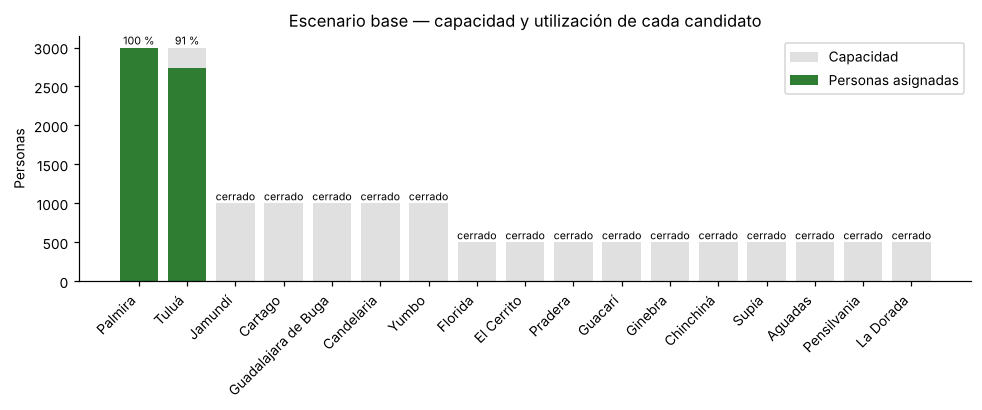

In [11]:
fig, ax = plt.subplots(figsize=(9, 3.8))
t = cam_b.sort_values(["abierto", "capacidad"], ascending=False)
ax.bar(t.municipio, t.capacidad, color="#e0e0e0", label="Capacidad")
ax.bar(t.municipio, t.asignados, color=[VERDE if a else GRIS for a in t.abierto], label="Personas asignadas")
for k_, r in enumerate(t.itertuples()):
    ax.text(k_, r.capacidad + 40, pct(r.utilizacion, 0) if r.abierto else "cerrado", ha="center", fontsize=7)
ax.set_ylabel("Personas"); ax.set_title("Escenario base — capacidad y utilización de cada candidato")
plt.xticks(rotation=45, ha="right"); ax.legend(); plt.tight_layout()
plt.savefig(FIG / "02_utilizacion_base.png", dpi=160); plt.show()

### 6.2 Asignación de población por origen y campamento ($x_{ij}$)

In [12]:
abiertos_b = [j for j in INST_BASE["J"] if BASE["y"][j]]
MATRIZ_X = pd.DataFrame(0, index=I, columns=abiertos_b, dtype=int)
for (i, j), q in BASE["x"].items():
    if q > 0:
        MATRIZ_X.loc[i, j] = q
MATRIZ_X.columns = [NOM[j] for j in abiertos_b]
cols_c = list(MATRIZ_X.columns)
MATRIZ_X.insert(0, "Departamento", dem.departamento); MATRIZ_X.insert(0, "Municipio", dem.municipio)
MATRIZ_X["Demanda d_i"] = dem_b.demanda; MATRIZ_X["Atendidos"] = MATRIZ_X[cols_c].sum(axis=1)
MATRIZ_X["No atendidos u_i"] = MATRIZ_X["Demanda d_i"] - MATRIZ_X["Atendidos"]
MATRIZ_X["Cobertura"] = MATRIZ_X.Atendidos / MATRIZ_X["Demanda d_i"]
MATRIZ_X = MATRIZ_X.sort_values(["Departamento", "Demanda d_i"], ascending=[True, False])
display(MATRIZ_X.style.format({**{c: (lambda v: es(v) if v else "") for c in cols_c}, "Demanda d_i": es, "Atendidos": es,
                                "No atendidos u_i": es, "Cobertura": lambda v: pct(v, 0)})
        .background_gradient(subset=cols_c, cmap="Greens", vmin=0)
        .map(lambda v: "color:#c62828;font-weight:600" if v > 0 else "", subset=["No atendidos u_i"]).hide(axis="index"))

Municipio,Departamento,Palmira,Tuluá,Demanda d_i,Atendidos,No atendidos u_i,Cobertura
Manizales,Caldas,,,722,0,722,0 %
Villamaría,Caldas,,,138,0,138,0 %
Armenia,Quindío,,1.222,1.365,1.222,143,90 %
Quimbaya,Quindío,,,374,0,374,0 %
Montenegro,Quindío,,,240,0,240,0 %
Circasia,Quindío,,,73,0,73,0 %
Calarcá,Quindío,,,68,0,68,0 %
Pereira,Risaralda,,,5.607,0,5.607,0 %
Dosquebradas,Risaralda,,,914,0,914,0 %
Santa Rosa de Cabal,Risaralda,,,436,0,436,0 %


In [13]:
tabla_rutas = asig_b[["municipio", "departamento", "campamento", "personas", "distancia_km", "costo_transporte"]].sort_values(["campamento", "distancia_km"])
display(tabla_rutas.style.format({"personas": es, "distancia_km": lambda v: es(v, 1), "costo_transporte": mcop}).hide(axis="index"))

municipio,departamento,campamento,personas,distancia_km,costo_transporte
Cali,Valle del Cauca,Palmira,3.000,"34,4","$51,6 M"
Riofrío,Valle del Cauca,Tuluá,89,"14,3","$0,6 M"
Bugalagrande,Valle del Cauca,Tuluá,91,"17,6","$0,8 M"
Trujillo,Valle del Cauca,Tuluá,155,"23,9","$1,9 M"
Yotoco,Valle del Cauca,Tuluá,161,"37,9","$3,1 M"
Zarzal,Valle del Cauca,Tuluá,114,"41,6","$2,4 M"
Roldanillo,Valle del Cauca,Tuluá,230,"47,3","$5,4 M"
Sevilla,Valle del Cauca,Tuluá,112,"54,5","$3,0 M"
Restrepo,Valle del Cauca,Tuluá,126,"60,3","$3,8 M"
La Unión,Valle del Cauca,Tuluá,134,"66,1","$4,4 M"


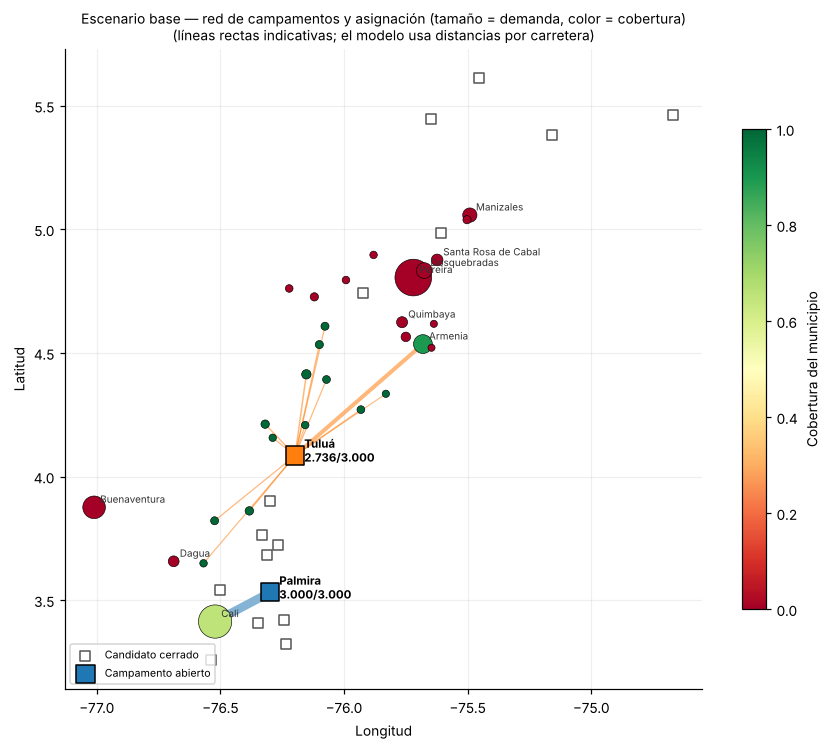

In [14]:
def mapa(res, titulo, archivo):
    asig, t_c, t_d = tablas(res)
    fig, ax = plt.subplots(figsize=(8, 9))
    pmax = max(asig.personas.max(), 1)
    colores = plt.cm.tab10.colors
    col_j = {j: colores[k % 10] for k, j in enumerate(t_c[t_c.abierto == 1].index)}
    for r in asig.itertuples():
        o, dd = dem.loc[r.origen], cand.loc[r.destino]
        ax.plot([o.lon, dd.lon], [o.lat, dd.lat], color=col_j[r.destino], alpha=0.55, lw=0.6 + 5 * r.personas / pmax, zorder=1)
    cob = t_d.cobertura.values
    sc = ax.scatter(dem.lon, dem.lat, s=15 + t_d.demanda.values / 10,
                    c=cob, cmap="RdYlGn", vmin=0, vmax=1, edgecolor="k", linewidth=0.4, zorder=3)
    cer = t_c[t_c.abierto == 0].index; ab = t_c[t_c.abierto == 1].index
    ax.scatter(cand.loc[cer, "lon"], cand.loc[cer, "lat"], marker="s", s=35, facecolor="white", edgecolor="#555", zorder=4, label="Candidato cerrado")
    ax.scatter(cand.loc[ab, "lon"], cand.loc[ab, "lat"], marker="s", s=140, c=[col_j[j] for j in ab], edgecolor="k", zorder=5, label="Campamento abierto")
    for j in ab:
        ax.annotate(f"{NOM[j]}\n{es(t_c.loc[j,'asignados'])}/{es(t_c.loc[j,'capacidad'])}", (cand.loc[j, "lon"], cand.loc[j, "lat"]),
                    xytext=(6, -4), textcoords="offset points", fontsize=7.5, weight="bold")
    for i in I:
        if t_d.loc[i, "demanda"] >= 300:
            ax.annotate(NOM[i], (dem.loc[i, "lon"], dem.loc[i, "lat"]), xytext=(4, 3), textcoords="offset points", fontsize=6.5, color="#333")
    cb = plt.colorbar(sc, ax=ax, shrink=0.5); cb.set_label("Cobertura del municipio")
    ax.set_title(titulo + "\n(líneas rectas indicativas; el modelo usa distancias por carretera)", fontsize=9)
    ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud"); ax.set_aspect("equal"); ax.legend(loc="lower left", fontsize=7)
    ax.grid(alpha=0.2); plt.tight_layout(); plt.savefig(FIG / archivo, dpi=160); plt.show()

mapa(BASE, "Escenario base — red de campamentos y asignación (tamaño = demanda, color = cobertura)", "03_mapa_red_base.png")

### 6.3 Población atendida y no atendida

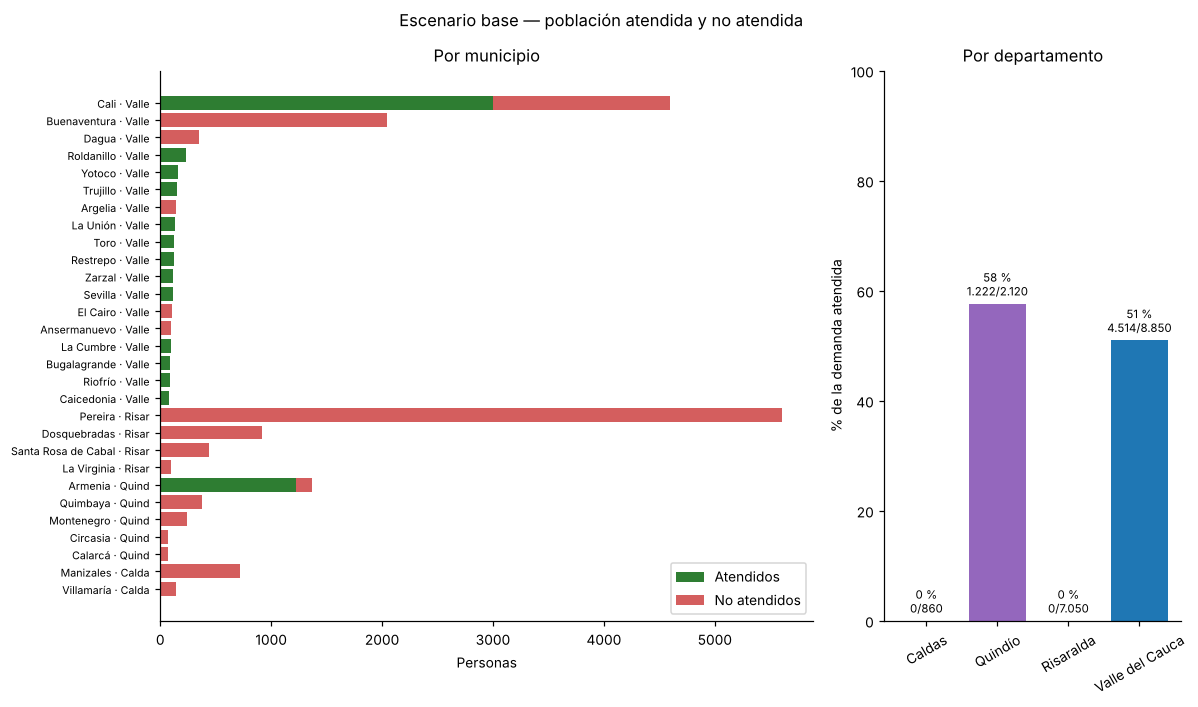

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(11, 6.5), gridspec_kw={"width_ratios": [2.2, 1]})
t = dem_b.sort_values(["departamento", "demanda"], ascending=[True, True])
etq = t.municipio + " · " + t.departamento.str[:5]
axs[0].barh(etq, t.atendidos, color=VERDE, label="Atendidos")
axs[0].barh(etq, t.no_atendidos, left=t.atendidos, color=ROJO, alpha=0.75, label="No atendidos")
axs[0].set_xlabel("Personas"); axs[0].set_title("Por municipio"); axs[0].legend(loc="lower right"); axs[0].tick_params(axis="y", labelsize=7)
cd = dem_b.groupby("departamento")[["demanda", "atendidos"]].sum()
cd["cobertura"] = cd.atendidos / cd.demanda
axs[1].bar(cd.index, cd.cobertura * 100, color=[COL_DEP[d] for d in cd.index])
for k_, (dpto, r) in enumerate(cd.iterrows()):
    axs[1].text(k_, r.cobertura * 100 + 1.5, f"{pct(r.cobertura, 0)}\n{es(r.atendidos)}/{es(r.demanda)}", ha="center", fontsize=7.5)
axs[1].set_ylim(0, 100); axs[1].set_ylabel("% de la demanda atendida"); axs[1].set_title("Por departamento"); axs[1].tick_params(axis="x", rotation=30)
fig.suptitle("Escenario base — población atendida y no atendida"); plt.tight_layout()
plt.savefig(FIG / "04_cobertura_base.png", dpi=160); plt.show()

### 6.4 Costos y distancias
**Umbrales de distancia definidos por el grupo** (el enunciado pide el porcentaje de población atendida dentro de umbrales propios):

| Umbral | Justificación |
|---|---|
| 50 km | Traslado corto, dentro del área metropolitana o a un municipio vecino (≈ 1 h por carretera); la familia puede volver a su vivienda o trabajo en el día. |
| 100 km | Traslado típico dentro del mismo departamento (≈ 2 h); todavía permite mantener vínculos con el municipio de origen. |
| 150 km | Traslado interdepartamental o de montaña (≈ 3 h); es el último umbral antes del límite y muestra cuánta gente queda cerca de él. |
| 180 km | Distancia máxima del enunciado (R5); por construcción el 100 % de los atendidos queda dentro, y sirve de control. |

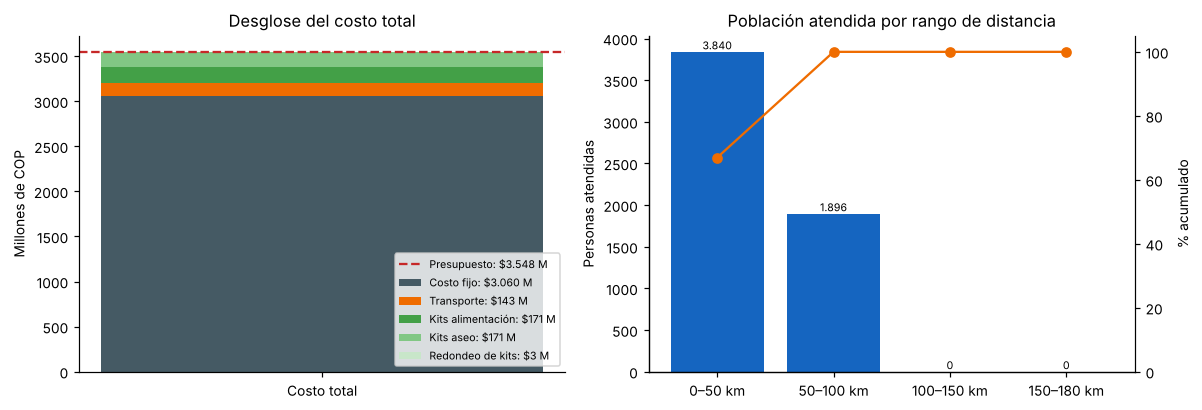

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
comp = {"Costo fijo": K_BASE["Costo fijo"], "Transporte": K_BASE["Costo transporte"],
        "Kits alimentación": K_BASE["Costo kits alimentación"], "Kits aseo": K_BASE["Costo kits aseo"],
        "Redondeo de kits": K_BASE["Costo ajuste por redondeo de kits"]}
acum = 0
for (nombre, val_), col in zip(comp.items(), ["#455a64", NARANJA, "#43a047", "#81c784", "#c8e6c9"]):
    axs[0].bar(["Costo total"], [val_ / 1e6], bottom=acum / 1e6, color=col, label=f"{nombre}: {mcop(val_, 0)}")
    acum += val_
axs[0].axhline(K_BASE["Presupuesto"] / 1e6, color=ROJO, ls="--", label=f"Presupuesto: {mcop(K_BASE['Presupuesto'], 0)}")
axs[0].set_ylabel("Millones de COP"); axs[0].set_title("Desglose del costo total"); axs[0].legend(fontsize=7, loc="lower right")
bins = [0] + UMBRALES_KM
rng = pd.cut(asig_b.distancia_km, bins=bins, labels=[f"{a}–{b} km" for a, b in zip(bins[:-1], bins[1:])], include_lowest=True)
tt = asig_b.groupby(rng, observed=False).personas.sum()
axs[1].bar(tt.index.astype(str), tt.values, color=AZUL)
ax2 = axs[1].twinx(); ax2.plot(tt.index.astype(str), tt.cumsum() / tt.sum() * 100, color=NARANJA, marker="o")
ax2.set_ylim(0, 105); ax2.set_ylabel("% acumulado"); ax2.spines["right"].set_visible(True)
for k_, v_ in enumerate(tt.values):
    axs[1].text(k_, v_, es(v_), ha="center", va="bottom", fontsize=7)
axs[1].set_ylabel("Personas atendidas"); axs[1].set_title("Población atendida por rango de distancia")
plt.tight_layout(); plt.savefig(FIG / "05_costos_distancias_base.png", dpi=160); plt.show()

In [17]:
llenos = cam_b[(cam_b.abierto == 1) & (cam_b.utilizacion >= 0.99)].municipio.tolist()
sin_atencion = dem_b[dem_b.atendidos == 0].sort_values("demanda", ascending=False)
cats_ab = cand.loc[[j for j in BASE["y"] if BASE["y"][j]], "categoria"].value_counts()
deps_cero = [d_ for d_ in DEPTOS if K_BASE[f"Cobertura {d_}"] == 0]
flujo_max = asig_b.sort_values("personas", ascending=False).iloc[0]
pe_b = dem_b.loc[dem.municipio == "Pereira"].iloc[0]
md(f'''### Resultado matemático
- Se abren **{K_BASE["Campamentos abiertos"]} campamentos** ({", ".join(f"{n_} {c_.lower()}{'s' if n_ > 1 else ''}" for c_, n_ in cats_ab.items())}): {K_BASE["Sitios abiertos"]} ({es(K_BASE["Capacidad instalada"])} plazas).
- Se atiende a **{es(K_BASE["Población atendida"])} de {es(K_BASE["Población que requiere campamento"])} personas ({pct(K_BASE["% atendida"])})**;
  quedan **{es(K_BASE["Población no atendida"])}** sin campamento.
- Utilización: {", ".join(f"{r.municipio} {pct(r.utilizacion)}" for r in cam_b[cam_b.abierto==1].itertuples())}.
- Costo total **{mcop(K_BASE["Costo total"])}** = fijo {mcop(K_BASE["Costo fijo"])} + transporte {mcop(K_BASE["Costo transporte"])} + kits {mcop(K_BASE["Costo atención (kits)"])};
  usa el {pct(K_BASE["% presupuesto usado"], 2)} del presupuesto (holgura {mcop(K_BASE["Holgura presupuestal"], 2)}).
- Distancia promedio ponderada **{es(K_BASE["Distancia promedio ponderada (km)"], 1)} km**, máxima **{es(K_BASE["Distancia máxima recorrida (km)"], 1)} km**;
  {pct(K_BASE["% de atendidos a ≤50 km"])} de los atendidos viaja ≤ 50 km y {pct(K_BASE["% de atendidos a ≤100 km"])} ≤ 100 km.
- **{len(sin_atencion)} municipios sin ninguna atención**, entre ellos {", ".join(f"{r.municipio} ({es(r.demanda)})" for r in sin_atencion.head(5).itertuples())}.
- Cobertura por departamento: {"; ".join(f"{dp} {pct(K_BASE[f'Cobertura {dp}'])}" for dp in DEPTOS)}.

### Interpretación
El **presupuesto determina la solución**: se gasta completo y la capacidad abierta casi se llena. Con un objetivo que maximiza
personas, el modelo compra las **plazas más baratas** ({es(costo_plaza["Grande"])} COP/plaza en campamentos grandes frente a
{es(costo_plaza["Intermedia"])} en intermedios y {es(costo_plaza["Pequeña"])} en pequeños) y las llena con la demanda más cercana. El flujo
más grande es {flujo_max.municipio} → {flujo_max.campamento} ({es(flujo_max.personas)} personas, {es(flujo_max.distancia_km, 1)} km).
Pereira —el municipio con más demanda ({es(pe_b.demanda)})— recibe {es(pe_b.atendidos)} cupos y {("quedan en 0 % los departamentos de " + ", ".join(deps_cero)) if deps_cero else "todos los departamentos reciben algo"}:
su campamento alcanzable más barato está más lejos que la demanda del Valle. Es una solución eficiente pero **territorialmente
inequitativa**, lo que motiva la extensión de la sección 10. La distancia máxima de 180 km no limita la solución base (la asignación
más larga es de {es(K_BASE["Distancia máxima recorrida (km)"], 1)} km; ver umbral en la sección 7.3).
''')

### Resultado matemático
- Se abren **2 campamentos** (2 grandes): Palmira, Tuluá (6.000 plazas).
- Se atiende a **5.736 de 18.880 personas (30,4 %)**;
  quedan **13.144** sin campamento.
- Utilización: Palmira 100,0 %, Tuluá 91,2 %.
- Costo total **$3.547,5 M** = fijo $3.060,0 M + transporte $143,3 M + kits $344,2 M;
  usa el 100,00 % del presupuesto (holgura $0,02 M).
- Distancia promedio ponderada **50,0 km**, máxima **89,1 km**;
  66,9 % de los atendidos viaja ≤ 50 km y 100,0 % ≤ 100 km.
- **15 municipios sin ninguna atención**, entre ellos Pereira (5.607), Buenaventura (2.041), Dosquebradas (914), Manizales (722), Santa Rosa de Cabal (436).
- Cobertura por departamento: Caldas 0,0 %; Quindío 57,6 %; Risaralda 0,0 %; Valle del Cauca 51,0 %.

### Interpretación
El **presupuesto determina la solución**: se gasta completo y la capacidad abierta casi se llena. Con un objetivo que maximiza
personas, el modelo compra las **plazas más baratas** (510.000 COP/plaza en campamentos grandes frente a
600.000 en intermedios y 690.000 en pequeños) y las llena con la demanda más cercana. El flujo
más grande es Cali → Palmira (3.000 personas, 34,4 km).
Pereira —el municipio con más demanda (5.607)— recibe 0 cupos y quedan en 0 % los departamentos de Caldas, Risaralda:
su campamento alcanzable más barato está más lejos que la demanda del Valle. Es una solución eficiente pero **territorialmente
inequitativa**, lo que motiva la extensión de la sección 10. La distancia máxima de 180 km no limita la solución base (la asignación
más larga es de 89,1 km; ver umbral en la sección 7.3).


## 7. ¿Por qué esta red?
### 7.1 Costo de atender una persona en cada candidato
Costo marginal de una persona alojada en $j$ si el campamento se llena = costo fijo por plaza + kits + transporte desde el municipio
afectado más cercano. Explica la preferencia del modelo por los campamentos grandes.

In [18]:
cpp = pd.DataFrame({"municipio": base_c.municipio, "categoria": base_c.categoria, "capacidad": base_c.capacidad_K,
                    "costo_fijo_por_plaza": base_c.costo_fijo_fj / base_c.capacidad_K,
                    "dist_min_km": dist[J_BASE].min(axis=0), "municipio_mas_cercano": dist[J_BASE].idxmin(axis=0).map(NOM),
                    "demanda_a_180km": [sum(dem_b.demanda[i] for i in I if dist.loc[i, j] <= D_MAX) for j in J_BASE]})
cpp["costo_persona_lleno"] = cpp.costo_fijo_por_plaza + V_KIT + TARIFA * cpp.dist_min_km
cpp["abierto_base"] = pd.Series(BASE["y"])
display(cpp.sort_values("costo_persona_lleno").style.format({"capacidad": es, "costo_fijo_por_plaza": es, "dist_min_km": lambda v: es(v, 1),
        "demanda_a_180km": es, "costo_persona_lleno": es}))

,municipio,categoria,capacidad,costo_fijo_por_plaza,dist_min_km,municipio_mas_cercano,demanda_a_180km,costo_persona_lleno,abierto_base
C02,Tuluá,Grande,3.000,510.000,"14,3",Riofrío,18.880,577.156,1
C01,Palmira,Grande,3.000,510.000,"34,4",Cali,10.347,587.200,1
C04,Cartago,Intermedia,1.000,600.000,"11,5",Ansermanuevo,11.798,665.737,0
C05,Guadalajara de Buga,Intermedia,1.000,600.000,"12,8",Yotoco,17.917,666.402,0
C07,Yumbo,Intermedia,1.000,600.000,"17,7",Cali,10.175,668.867,0
C03,Jamundí,Intermedia,1.000,600.000,"19,6",Cali,8.294,669.800,0
C06,Candelaria,Intermedia,1.000,600.000,"27,7",Cali,10.107,673.850,0
C13,Chinchiná,Pequeña,500,690.000,"14,7",Santa Rosa de Cabal,11.511,757.350,0
C11,Guacarí,Pequeña,500,690.000,"27,4",Yotoco,17.917,763.694,0
C09,El Cerrito,Pequeña,500,690.000,"36,4",Yotoco,17.481,768.206,0


### 7.2 Formación de la red con presupuesto creciente (hasta ×4) y restricciones activas
Se resuelve de nuevo con el 10 %, 20 %, …, 400 % del presupuesto base. En cada nivel se identifica qué limita la solución:
- **Presupuesto:** limita mientras los atendidos estén por debajo de la cota física (con más dinero se llega a ella). Como
  diagnóstico local se reporta también el cambio con +10 % de presupuesto, que puede ser 0 cuando el 10 % adicional no alcanza para
  abrir otro campamento (efecto de la variable binaria).
- **Capacidad:** se vuelve a resolver con +10 % de plazas en todos los sitios (sin cambiar su costo fijo); si aumentan los atendidos,
  hay campamentos llenos que limitan.
- **Distancia:** se vuelve a resolver sin límite de distancia; si aumentan los atendidos, el límite de 180 km es activo.

Además se calcula la **cota física** de la red: el máximo de personas atendibles con presupuesto ilimitado (todos los sitios
abiertos, solo capacidad y distancia).

fraccion,presupuesto,n_abiertos,entran,salen,atendidos,pct,pct_presupuesto_usado,utilizacion,dist_media,dist_max,cobertura_min_dep,delta_si_B_mas_10,delta_si_K_mas_10,delta_sin_limite_distancia,restricciones_activas
10 %,"$354,8 M",1,Chinchiná,,144,"0,8 %","100,0 %","28,8 %","14,7","14,7","0,0 %",356,0,0,presupuesto
20 %,"$709,5 M",1,Yumbo,Chinchiná,1.000,"5,3 %","94,3 %","100,0 %","17,7","17,7","0,0 %",0,100,0,"presupuesto, capacidad (sitios llenos)"
30 %,"$1.064,2 M",2,Chinchiná,,1.500,"7,9 %","98,5 %","100,0 %","17,2","26,1","0,0 %",0,150,0,"presupuesto, capacidad (sitios llenos)"
40 %,"$1.419,0 M",2,Jamundí,Chinchiná,2.000,"10,6 %","94,3 %","100,0 %","18,7","19,6","0,0 %",0,200,0,"presupuesto, capacidad (sitios llenos)"
50 %,"$1.773,8 M",1,Palmira,"Jamundí, Yumbo",3.000,"15,9 %","99,3 %","100,0 %","34,4","34,4","0,0 %",0,157,0,"presupuesto, capacidad (sitios llenos)"
60 %,"$2.128,5 M",2,Chinchiná,,3.342,"17,7 %","100,0 %","95,5 %","31,7","34,4","0,0 %",158,3,0,"presupuesto, capacidad (sitios llenos)"
70 %,"$2.483,2 M",2,Yumbo,Chinchiná,4.000,"21,2 %","97,9 %","100,0 %","30,2","34,4","0,0 %",0,400,0,"presupuesto, capacidad (sitios llenos)"
80 %,"$2.838,0 M",3,Chinchiná,,4.500,"23,8 %","99,0 %","100,0 %","28,7","34,4","0,0 %",500,382,0,"presupuesto, capacidad (sitios llenos)"
90 %,"$3.192,8 M",3,Cartago,Chinchiná,5.000,"26,5 %","97,2 %","100,0 %","29,8","34,4","0,0 %",500,500,0,"presupuesto, capacidad (sitios llenos)"
100 %,"$3.547,5 M",2,Tuluá,"Cartago, Yumbo",5.736,"30,4 %","100,0 %","95,6 %","50,0","89,1","0,0 %",267,314,0,"presupuesto, capacidad (sitios llenos)"


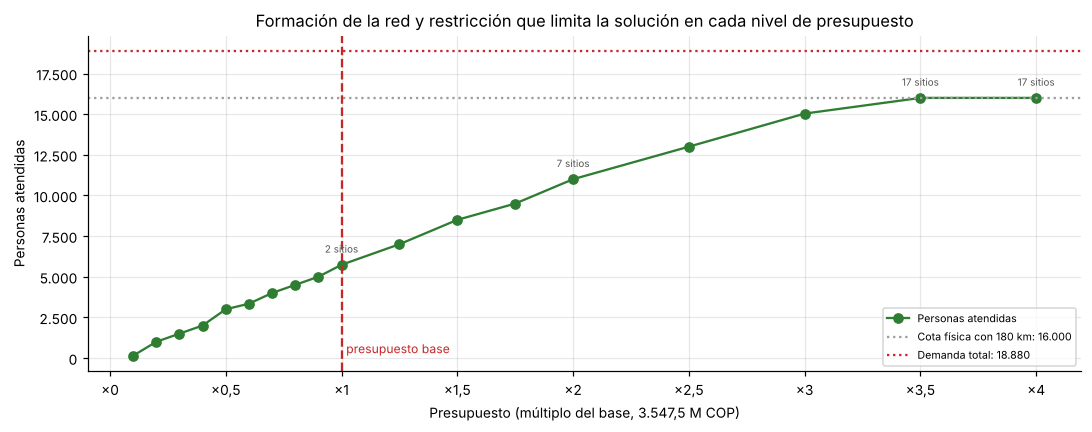

**Lectura.**
- **Presupuesto:** limita el total de atendidos en todos los niveles hasta ×3,00. El diagnóstico local (+10 % de
  presupuesto) es 0 en 5 niveles bajos porque ese 10 % no alcanza para abrir otro campamento: la respuesta
  es escalonada.
- **Capacidad:** con +10 % de plazas aumentan los atendidos en 17 de 18 niveles, porque casi siempre hay
  campamentos llenos (en la base, Palmira); pero mientras sobra capacidad en otro sitio abierto o en sitios cerrados, el total lo fija el dinero.
  Desde ×3,50 se abren los 17 candidatos, se atiende la cota física de **16.000 personas** y el presupuesto queda con holgura (10 % sin usar): ahí manda la **capacidad total**.
- **Distancia:** no es activa en ningún nivel. Con presupuesto ilimitado la cota es
  16.000 con el límite de 180 km y 16.000 sin él: todos los candidatos pueden llenarse con demanda a ≤ 180 km.
  La asignación más larga llega a 173,0 km (presupuesto ×3,50, cuando se abren sitios lejanos de Caldas); con ×3,00 ya supera 150 km.

In [19]:
FRACCIONES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0, 3.5, 4.0]
if RAPIDO:                       # modo rápido: 4 niveles (los niveles ×2,5–×3,5 son los más lentos)
    FRACCIONES = [0.5, 1.0, 1.5, 2.0]
COTA_FISICA = exigir_optimo(resolver(crear_instancia(factor_presupuesto=100), "cota_fisica"))["Z1"]
COTA_SIN_DIST = exigir_optimo(resolver(crear_instancia(factor_presupuesto=100, dmax=1e4), "cota_sin_distancia"))["Z1"]
ITER, previos = [], set()
for f_ in FRACCIONES:
    r = exigir_optimo(resolver(crear_instancia(factor_presupuesto=f_), f"presupuesto_{f_:.0%}"))
    k = kpis(r); ab = {j for j in r["y"] if r["y"][j]}
    z_b = exigir_optimo(resolver(crear_instancia(factor_presupuesto=f_ * 1.10), "relaja_B"))["Z1"]
    z_k = exigir_optimo(resolver(crear_instancia(factor_presupuesto=f_, factor_capacidad=1.10), "relaja_K"))["Z1"]
    z_d = exigir_optimo(resolver(crear_instancia(factor_presupuesto=f_, dmax=1e4), "relaja_D"))["Z1"]
    activas = (["presupuesto"] if r["Z1"] < COTA_FISICA else []) \
              + ([("capacidad (sitios llenos)" if r["Z1"] < COTA_FISICA else "capacidad total")] if z_k > r["Z1"] else []) \
              + (["distancia 180 km"] if z_d > r["Z1"] else [])
    ITER.append(dict(fraccion=f_, presupuesto=k["Presupuesto"], abiertos=", ".join(sorted(NOM[j] for j in ab)),
                     n_abiertos=len(ab), entran=", ".join(sorted(NOM[j] for j in ab - previos)),
                     salen=", ".join(sorted(NOM[j] for j in previos - ab)),
                     atendidos=k["Población atendida"], pct=k["% atendida"], pct_presupuesto_usado=k["% presupuesto usado"],
                     utilizacion=k["% utilización de la capacidad instalada"], dist_media=k["Distancia promedio ponderada (km)"],
                     dist_max=k["Distancia máxima recorrida (km)"], cobertura_min_dep=k["Cobertura mínima departamental"],
                     delta_si_B_mas_10=z_b - r["Z1"], delta_si_K_mas_10=z_k - r["Z1"], delta_sin_limite_distancia=z_d - r["Z1"],
                     restricciones_activas=", ".join(activas) or "ninguna"))
    previos = ab
tabla_iter = pd.DataFrame(ITER)
display(tabla_iter.drop(columns=["abiertos"]).style.format({"fraccion": lambda v: pct(v, 0), "presupuesto": mcop, "atendidos": es, "pct": pct,
        "pct_presupuesto_usado": pct, "utilizacion": pct, "dist_media": lambda v: es(v, 1), "dist_max": lambda v: es(v, 1),
        "cobertura_min_dep": pct, "delta_si_B_mas_10": es, "delta_si_K_mas_10": es, "delta_sin_limite_distancia": es}).hide(axis="index"))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tabla_iter.fraccion, tabla_iter.atendidos, marker="o", color=VERDE, label="Personas atendidas")
ax.axhline(COTA_FISICA, color=GRIS, ls=":", label=f"Cota física con 180 km: {es(COTA_FISICA)}")
ax.axhline(dem.d_f10.sum(), color=ROJO, ls=":", label=f"Demanda total: {es(dem.d_f10.sum())}")
ax.axvline(1.0, color=ROJO, ls="--"); ax.text(1.02, 300, "presupuesto base", color=ROJO, fontsize=8)
for r in tabla_iter.itertuples():
    if r.fraccion in (1.0, 2.0) or r.atendidos >= COTA_FISICA:
        ax.annotate(f"{r.n_abiertos} sitios", (r.fraccion, r.atendidos), xytext=(0, 8), textcoords="offset points",
                    fontsize=6.5, ha="center", color="#555")
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda v, _: es(v)))
ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda v, _: f"×{es(v, 2).rstrip('0').rstrip(',')}"))
ax.set_xlabel("Presupuesto (múltiplo del base, 3.547,5 M COP)"); ax.set_ylabel("Personas atendidas")
ax.set_title("Formación de la red y restricción que limita la solución en cada nivel de presupuesto")
ax.legend(fontsize=7, loc="lower right"); ax.grid(alpha=0.3); plt.tight_layout(); plt.savefig(FIG / "06_formacion_red.png", dpi=160); plt.show()

lim_B = tabla_iter[tabla_iter.atendidos < COTA_FISICA]
en_cota = tabla_iter[tabla_iter.atendidos >= COTA_FISICA]
md(f"""**Lectura.**
- **Presupuesto:** limita el total de atendidos en todos los niveles hasta ×{es(lim_B.fraccion.max(), 2)}. El diagnóstico local (+10 % de
  presupuesto) es 0 en {(lim_B.delta_si_B_mas_10 == 0).sum()} niveles bajos porque ese 10 % no alcanza para abrir otro campamento: la respuesta
  es escalonada.
- **Capacidad:** con +10 % de plazas aumentan los atendidos en {(tabla_iter.delta_si_K_mas_10 > 0).sum()} de {len(tabla_iter)} niveles, porque casi siempre hay
  campamentos llenos (en la base, Palmira); pero mientras sobra capacidad en otro sitio abierto o en sitios cerrados, el total lo fija el dinero.
  {("Desde ×" + es(en_cota.fraccion.min(), 2) + f" se abren los {int(en_cota.n_abiertos.iloc[0])} candidatos, se atiende la cota física de **{es(COTA_FISICA)} personas** y el presupuesto queda con holgura ({pct(1 - en_cota.pct_presupuesto_usado.iloc[0], 0)} sin usar): ahí manda la **capacidad total**.") if len(en_cota) else "La cota física no se alcanza en los niveles probados."}
- **Distancia:** {"no es activa en ningún nivel" if (tabla_iter.delta_sin_limite_distancia == 0).all() else "es activa en " + ", ".join("×" + es(v, 2) for v in tabla_iter.fraccion[tabla_iter.delta_sin_limite_distancia > 0])}. Con presupuesto ilimitado la cota es
  {es(COTA_FISICA)} con el límite de 180 km y {es(COTA_SIN_DIST)} sin él: {"todos los candidatos pueden llenarse con demanda a ≤ 180 km" if COTA_FISICA == COTA_SIN_DIST else "la distancia reduce la cota física"}.
  La asignación más larga llega a {es(tabla_iter.dist_max.max(), 1)} km (presupuesto ×{es(tabla_iter.fraccion.loc[tabla_iter.dist_max.idxmax()], 2)}, cuando se abren sitios lejanos de Caldas); con ×{es(tabla_iter.fraccion[tabla_iter.dist_max > 150].min(), 2)} ya supera 150 km.""")

### 7.3 ¿Desde qué distancia máxima cambia la red base?
Se resuelve el escenario base con límites de distancia de 40 a 250 km. Sirve para saber si el límite de 180 km del enunciado
influye en la decisión y cuál es el **umbral** a partir del cual deja de influir.

In [20]:
DMAX_SWEEP = [40, 50, 60, 70, 80, 85, 88, 89, 90, 95, 100, 120, 150, 180, 210, 250]
if RAPIDO:
    DMAX_SWEEP = [40, 89, 90, 180]
filas = []
for dm_ in DMAX_SWEEP:
    r = resolver(crear_instancia(dmax=dm_), f"dmax_{dm_}")
    if r["estado"] != "Optimal":
        filas.append(dict(dmax_km=dm_, estado=r["estado"])); continue
    k = kpis(r)
    filas.append(dict(dmax_km=dm_, estado=r["estado"], atendidos=k["Población atendida"], sitios=k["Sitios abiertos"],
                      costo=k["Costo total"], dist_media=k["Distancia promedio ponderada (km)"], dist_max=k["Distancia máxima recorrida (km)"],
                      mun_sin_atencion=k["Municipios con cobertura 0 %"]))
sweep_d = pd.DataFrame(filas)
sweep_d["igual_a_base"] = (sweep_d.atendidos == K_BASE["Población atendida"]) & (sweep_d.sitios == K_BASE["Sitios abiertos"])
display(sweep_d.style.format({"atendidos": es, "costo": mcop, "dist_media": lambda v: es(v, 1), "dist_max": lambda v: es(v, 1)}).hide(axis="index"))
UMBRAL_D = sweep_d.loc[sweep_d.igual_a_base, "dmax_km"].min()
ultimo_dist = sweep_d.loc[~sweep_d.igual_a_base & (sweep_d.dmax_km < UMBRAL_D), "dmax_km"].max()
md(f"**Lectura.** La red base aparece desde un límite de **{es(UMBRAL_D)} km** (con {es(ultimo_dist)} km ya cambia), coherente con "
   f"su asignación más larga ({es(K_BASE['Distancia máxima recorrida (km)'], 1)} km). Entre {es(UMBRAL_D)} y 250 km la red no cambia: el "
   "límite de 180 km del enunciado se cumple con holgura y **no es la restricción que decide**; sí lo sería un límite más estricto "
   f"(por ejemplo, con {es(sweep_d.dmax_km.min())} km se atiende a {es(sweep_d.atendidos.iloc[0])} personas).")

dmax_km,estado,atendidos,sitios,costo,dist_media,dist_max,mun_sin_atencion,igual_a_base
40,Optimal,5.500,"Palmira, Cartago, Yumbo, Chinchiná","$3.483,6 M","28,6","34,4",23,False
50,Optimal,5.500,"Palmira, Cartago, Yumbo, Chinchiná","$3.483,6 M","28,6","34,4",23,False
60,Optimal,5.500,"Palmira, Cartago, Yumbo, Chinchiná","$3.483,6 M","28,6","34,4",23,False
70,Optimal,5.500,"Palmira, Cartago, Yumbo, Chinchiná","$3.483,6 M","28,6","34,4",23,False
80,Optimal,5.500,"Palmira, Cartago, Yumbo, Chinchiná","$3.483,6 M","28,6","34,4",23,False
85,Optimal,5.500,"Palmira, Cartago, Yumbo, Chinchiná","$3.483,6 M","28,6","34,4",23,False
88,Optimal,5.500,"Palmira, Cartago, Yumbo, Chinchiná","$3.483,6 M","28,6","34,4",23,False
89,Optimal,5.500,"Palmira, Cartago, Yumbo, Chinchiná","$3.483,6 M","28,6","34,4",23,False
90,Optimal,5.736,"Palmira, Tuluá","$3.547,5 M","50,0","89,1",15,True
95,Optimal,5.736,"Palmira, Tuluá","$3.547,5 M","50,0","89,1",15,True


**Lectura.** La red base aparece desde un límite de **90 km** (con 89 km ya cambia), coherente con su asignación más larga (89,1 km). Entre 90 y 250 km la red no cambia: el límite de 180 km del enunciado se cumple con holgura y **no es la restricción que decide**; sí lo sería un límite más estricto (por ejemplo, con 40 km se atiende a 5.500 personas).

### 7.4 Redes casi óptimas
Para mostrar que la solución no es arbitraria ni trivial se enumeran las **5 mejores redes distintas**: después de cada solución
se agrega un corte *no-good* $\sum_{j\in S}(1-y_j)+\sum_{j\notin S}y_j\ge 1$ que prohíbe repetir el conjunto $S$ de sitios
abiertos, y se vuelve a resolver el modelo lexicográfico.

In [21]:
REDES, vistas = [], []
for k_ in range(2 if RAPIDO else 5):
    r = resolver(INST_BASE, f"red_{k_ + 1}", excluir=vistas)
    if r["estado"] != "Optimal":
        break
    kr = kpis(r); S = [j for j in r["y"] if r["y"][j]]; vistas.append(S)
    REDES.append(dict(ranking=k_ + 1, sitios=kr["Sitios abiertos"], atendidos=kr["Población atendida"],
                      diferencia_vs_optimo=kr["Población atendida"] - K_BASE["Población atendida"], costo=kr["Costo total"],
                      dist_media=kr["Distancia promedio ponderada (km)"], mun_sin_atencion=kr["Municipios con cobertura 0 %"],
                      **{f"cob_{d_[:5]}": kr[f"Cobertura {d_}"] for d_ in DEPTOS}))
redes = pd.DataFrame(REDES)
display(redes.style.format({"atendidos": es, "diferencia_vs_optimo": es, "costo": mcop, "dist_media": lambda v: es(v, 1),
                            **{f"cob_{d_[:5]}": pct for d_ in DEPTOS}}).hide(axis="index"))
cob_cols = [f"cob_{d_[:5]}" for d_ in DEPTOS]
md(f"**Lectura.** La red óptima es única: atiende a {es(K_BASE['Población atendida'])} personas y las redes 2 a {len(redes)} atienden a "
   f"{es(redes.atendidos.iloc[1:].max())} ({es(redes.diferencia_vs_optimo.iloc[1])}; {pct(redes.diferencia_vs_optimo.iloc[1] / K_BASE['Población atendida'])}). "
   f"Las alternativas son más cortas (distancia media {es(redes.dist_media.iloc[1:].min(), 0)}–{es(redes.dist_media.iloc[1:].max(), 0)} km frente a "
   f"{es(redes.dist_media.iloc[0], 0)} km) y redistribuyen la cobertura (Risaralda hasta {pct(redes.cob_Risar.max(), 0)}), pero todas dejan al menos un "
   f"departamento en 0 % (cobertura departamental mínima: {pct(redes[cob_cols].min(axis=1).max(), 0)}). La solución no es trivial ni arbitraria; "
   "para cubrir a todos los departamentos hay que imponerlo explícitamente (extensión, sección 10).")

ranking,sitios,atendidos,diferencia_vs_optimo,costo,dist_media,mun_sin_atencion,cob_Calda,cob_Quind,cob_Risar,cob_Valle
1,"Palmira, Tuluá",5.736,0,"$3.547,5 M","50,0",15,"0,0 %","57,6 %","0,0 %","51,0 %"
2,"Palmira, Cartago, Yumbo, Chinchiná",5.500,-236,"$3.483,6 M","28,6",23,"0,0 %","0,0 %","19,9 %","46,3 %"
3,"Palmira, Jamundí, Yumbo, Chinchiná",5.500,-236,"$3.484,0 M","28,7",22,"0,0 %","0,0 %","7,1 %","56,5 %"
4,"Palmira, Jamundí, Cartago, Chinchiná",5.500,-236,"$3.484,5 M","28,9",23,"0,0 %","0,0 %","19,9 %","46,3 %"
5,"Palmira, Candelaria, Yumbo, Chinchiná",5.500,-236,"$3.488,0 M","30,2",22,"0,0 %","0,0 %","7,1 %","56,5 %"


**Lectura.** La red óptima es única: atiende a 5.736 personas y las redes 2 a 5 atienden a 5.500 (-236; -4,1 %). Las alternativas son más cortas (distancia media 29–30 km frente a 50 km) y redistribuyen la cobertura (Risaralda hasta 20 %), pero todas dejan al menos un departamento en 0 % (cobertura departamental mínima: 0 %). La solución no es trivial ni arbitraria; para cubrir a todos los departamentos hay que imponerlo explícitamente (extensión, sección 10).

### 7.5 Análisis contrafactual
Para cada candidato se **re-optimiza la red forzando la decisión contraria** (cerrar el abierto o abrir el cerrado) y se mide el
cambio en personas atendidas. Distingue sitios indispensables de sitios sustituibles.

In [22]:
filas = []
for j in J_BASE:
    alt = resolver(INST_BASE, f"contrafactual_{j}", fijar={j: 1 - BASE["y"][j]})
    if alt["estado"] != "Optimal":
        filas.append((j, BASE["y"][j], np.nan, np.nan, "", alt["estado"])); continue
    ka = kpis(alt)
    filas.append((j, BASE["y"][j], ka["Población atendida"] - K_BASE["Población atendida"], (ka["Costo total"] - K_BASE["Costo total"]) / 1e6,
                  ka["Sitios abiertos"], "Optimal"))
cf = pd.DataFrame(filas, columns=["id", "abierto_base", "Δ atendidos", "Δ costo (M COP)", "red alternativa", "estado"]).set_index("id")
cf.insert(0, "municipio", cf.index.map(NOM))
def razon(r):
    if r.estado == "Infeasible":
        return "Forzar la decisión contraria hace infactible el modelo"
    if r.estado != "Optimal":
        return f"Sin solución óptima certificada: {r.estado}"
    if r.abierto_base == 1:
        return f"Indispensable: cerrarlo deja sin atención a {es(-r['Δ atendidos'])} personas" if r["Δ atendidos"] < 0 else "Sustituible"
    if r["Δ atendidos"] < 0:
        return f"Abrirlo consume presupuesto: {es(-r['Δ atendidos'])} personas menos"
    return "Abrirlo no cambia la cobertura"
cf["explicación"] = cf.apply(razon, axis=1)
display(cf.sort_values(["abierto_base", "Δ atendidos"], ascending=[False, True])
        .style.format({"Δ atendidos": lambda v: "—" if pd.isna(v) else f"{v:+,.0f}".replace(",", "."),
                       "Δ costo (M COP)": lambda v: "—" if pd.isna(v) else es(v, 1)}))
perd = cf["Δ atendidos"].dropna()
md(f"**Lectura:** cambiar la decisión de un solo sitio respecto a la red base cuesta "
   + (f"exactamente {es(-perd.max())} personas en todos los casos" if perd.max() == perd.min() else f"entre {es(-perd.max())} y {es(-perd.min())} personas") +
   f" ({'ningún cambio individual mejora la red' if perd.max() <= 0 else 'algún cambio mejora la red: revisar'}): todas las alternativas caen "
   f"en redes de {es(K_BASE['Población atendida'] + perd.max())} plazas llenas. "
   f"La ventaja de la red óptima sobre la mejor alternativa de un solo cambio es de {pct(-perd.max() / K_BASE['Población atendida'])}: el óptimo "
   "está bien definido pero la ventaja es moderada, lo que hace barata la equidad (sección 10).")

,municipio,abierto_base,Δ atendidos,Δ costo (M COP),red alternativa,estado,explicación
id,,,,,,,
C01,Palmira,1,-236,"-16,2","Tuluá, Jamundí, Yumbo, Chinchiná",Optimal,Indispensable: cerrarlo deja sin atención a 236 personas
C02,Tuluá,1,-236,"-63,9","Palmira, Cartago, Yumbo, Chinchiná",Optimal,Indispensable: cerrarlo deja sin atención a 236 personas
C03,Jamundí,0,-236,"-63,5","Palmira, Jamundí, Yumbo, Chinchiná",Optimal,Abrirlo consume presupuesto: 236 personas menos
C04,Cartago,0,-236,"-63,9","Palmira, Cartago, Yumbo, Chinchiná",Optimal,Abrirlo consume presupuesto: 236 personas menos
C05,Guadalajara de Buga,0,-236,"-54,6","Palmira, Guadalajara de Buga, Yumbo, Chinchiná",Optimal,Abrirlo consume presupuesto: 236 personas menos
C06,Candelaria,0,-236,"-59,5","Palmira, Candelaria, Yumbo, Chinchiná",Optimal,Abrirlo consume presupuesto: 236 personas menos
C07,Yumbo,0,-236,"-63,9","Palmira, Cartago, Yumbo, Chinchiná",Optimal,Abrirlo consume presupuesto: 236 personas menos
C08,Florida,0,-236,"-57,5","Palmira, Cartago, Yumbo, Florida",Optimal,Abrirlo consume presupuesto: 236 personas menos
C09,El Cerrito,0,-236,"-56,6","Palmira, Cartago, Yumbo, El Cerrito",Optimal,Abrirlo consume presupuesto: 236 personas menos


**Lectura:** cambiar la decisión de un solo sitio respecto a la red base cuesta exactamente 236 personas en todos los casos (ningún cambio individual mejora la red): todas las alternativas caen en redes de 5.500 plazas llenas. La ventaja de la red óptima sobre la mejor alternativa de un solo cambio es de 4,1 %: el óptimo está bien definido pero la ventaja es moderada, lo que hace barata la equidad (sección 10).

## 8. Escenarios de reducción presupuestal
El grupo definió dos reducciones dentro del rango del enunciado: **−15 %** (extremo inferior) y **−30 %** (extremo superior).
Se agregan −20 % y −25 % solo para dibujar la curva.

In [23]:
ESCENARIOS = {"Base": BASE}
for red in [0.15, 0.20, 0.25, 0.30]:
    n = f"Presupuesto −{red:.0%}"
    ESCENARIOS[n] = resolver(crear_instancia(factor_presupuesto=1 - red, nombre=n), n)
    assert ESCENARIOS[n]["estado"] == "Optimal" and (pruebas_post(ESCENARIOS[n]).Resultado == "PASS").all()
N_A, N_B = f"Presupuesto −{RED_A:.0%}", f"Presupuesto −{RED_B:.0%}"
cols_esc = ["Presupuesto", "Costo total", "Holgura presupuestal", "Población atendida", "% atendida", "Campamentos abiertos", "Sitios abiertos",
            "Capacidad instalada", "% utilización de la capacidad instalada", "Costo fijo", "Costo transporte", "Costo atención (kits)",
            "Distancia promedio ponderada (km)", "Distancia máxima recorrida (km)", "% de atendidos a ≤50 km", "% de atendidos a ≤100 km",
            "Municipios con cobertura 0 %", "Cobertura mínima departamental", "Costo por persona atendida"] + [f"Cobertura {d}" for d in DEPTOS]
comp_esc = pd.DataFrame({n: kpis(r) for n, r in ESCENARIOS.items()}).T[cols_esc]
fmt_esc = {c: mcop for c in ["Presupuesto", "Costo total", "Holgura presupuestal", "Costo fijo", "Costo transporte", "Costo atención (kits)"]}
fmt_esc.update({c: pct for c in cols_esc if c.startswith("%") or c.startswith("Cobertura")})
fmt_esc.update({"Población atendida": es, "Campamentos abiertos": es, "Capacidad instalada": es, "Municipios con cobertura 0 %": es,
                "Distancia promedio ponderada (km)": lambda v: es(v, 1), "Distancia máxima recorrida (km)": lambda v: es(v, 1),
                "Costo por persona atendida": lambda v: "$" + es(v)})
disp_esc = comp_esc.T.copy().astype(object)
for c in comp_esc.columns:
    if c in fmt_esc:
        disp_esc.loc[c] = [fmt_esc[c](v) for v in comp_esc[c]]
display(disp_esc)

,Base,Presupuesto −15%,Presupuesto −20%,Presupuesto −25%,Presupuesto −30%
Presupuesto,"$3.547,5 M","$3.015,4 M","$2.838,0 M","$2.660,6 M","$2.483,2 M"
Costo total,"$3.547,5 M","$2.809,5 M","$2.809,5 M","$2.430,5 M","$2.430,5 M"
Holgura presupuestal,"$0,0 M","$205,9 M","$28,5 M","$230,2 M","$52,8 M"
Población atendida,5.736,4.500,4.500,4.000,4.000
% atendida,"30,4 %","23,8 %","23,8 %","21,2 %","21,2 %"
Campamentos abiertos,2,3,3,2,2
Sitios abiertos,"Palmira, Tuluá","Palmira, Yumbo, Chinchiná","Palmira, Yumbo, Chinchiná","Palmira, Yumbo","Palmira, Yumbo"
Capacidad instalada,6.000,4.500,4.500,4.000,4.000
% utilización de la capacidad instalada,"95,6 %","100,0 %","100,0 %","100,0 %","100,0 %"
Costo fijo,"$3.060,0 M","$2.475,0 M","$2.475,0 M","$2.130,0 M","$2.130,0 M"


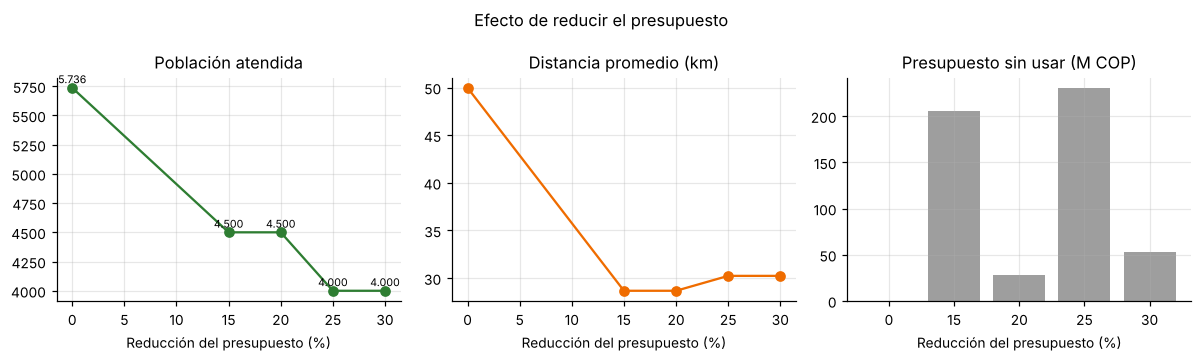

In [24]:
x_red = [0, 15, 20, 25, 30]
fig, axs = plt.subplots(1, 3, figsize=(11, 3.3))
axs[0].plot(x_red, comp_esc["Población atendida"].astype(float), marker="o", color=VERDE)
for xx, yy in zip(x_red, comp_esc["Población atendida"]):
    axs[0].text(xx, yy + 40, es(yy), ha="center", fontsize=7)
axs[0].set_title("Población atendida")
axs[1].plot(x_red, comp_esc["Distancia promedio ponderada (km)"].astype(float), marker="o", color=NARANJA); axs[1].set_title("Distancia promedio (km)")
axs[2].bar([str(v) for v in x_red], comp_esc["Holgura presupuestal"].astype(float) / 1e6, color=GRIS); axs[2].set_title("Presupuesto sin usar (M COP)")
for a_ in axs:
    a_.set_xlabel("Reducción del presupuesto (%)"); a_.grid(alpha=0.3)
plt.suptitle("Efecto de reducir el presupuesto"); plt.tight_layout(); plt.savefig(FIG / "07_escenarios_presupuesto.png", dpi=160); plt.show()

In [25]:
def comparar(nombre):
    E = ESCENARIOS[nombre]; kE = kpis(E); _, cE, dE = tablas(E)
    ab_b = {j for j in BASE["y"] if BASE["y"][j]}; ab_e = {j for j in E["y"] if E["y"][j]}
    cm = dem_b[["municipio", "departamento", "demanda"]].assign(cob_base=dem_b.cobertura, cob_esc=dE.cobertura)
    cm["Δ cobertura"] = cm.cob_esc - cm.cob_base
    gana, pierde = cm[cm["Δ cobertura"] > 0.001], cm[cm["Δ cobertura"] < -0.001]
    md(f'''#### Base vs. {nombre}
- **Estables** (abiertos en ambos): {", ".join(sorted(NOM[j] for j in ab_b & ab_e)) or "ninguno"}. **Se cierran:** {", ".join(sorted(NOM[j] for j in ab_b - ab_e)) or "ninguno"}.
  **Se abren:** {", ".join(sorted(NOM[j] for j in ab_e - ab_b)) or "ninguno"}.
- Atendidos: {es(K_BASE["Población atendida"])} → **{es(kE["Población atendida"])}** ({es(kE["Población atendida"] - K_BASE["Población atendida"])};
  {pct(kE["Población atendida"] / K_BASE["Población atendida"] - 1)}) con un recorte de {mcop(K_BASE["Presupuesto"] - kE["Presupuesto"])}.
- Presupuesto usado: {pct(kE["% presupuesto usado"])} (sin usar: {mcop(kE["Holgura presupuestal"])}); distancia promedio
  {es(K_BASE["Distancia promedio ponderada (km)"], 1)} → {es(kE["Distancia promedio ponderada (km)"], 1)} km.
- Municipios que **pierden** cobertura: {len(pierde)} · que **ganan**: {len(gana)} ({", ".join(gana.municipio) or "—"}).
- Cobertura por departamento: {"; ".join(f"{dp} {pct(K_BASE[f'Cobertura {dp}'], 0)} → {pct(kE[f'Cobertura {dp}'], 0)}" for dp in DEPTOS)}.''')
    return cm

cm_A = comparar(N_A); cm_B = comparar(N_B)

#### Base vs. Presupuesto −15%
- **Estables** (abiertos en ambos): Palmira. **Se cierran:** Tuluá.
  **Se abren:** Chinchiná, Yumbo.
- Atendidos: 5.736 → **4.500** (-1.236;
  -21,5 %) con un recorte de $532,1 M.
- Presupuesto usado: 93,2 % (sin usar: $205,9 M); distancia promedio
  50,0 → 28,7 km.
- Municipios que **pierden** cobertura: 13 · que **ganan**: 3 (Cali, Dosquebradas, Santa Rosa de Cabal).
- Cobertura por departamento: Caldas 0 % → 0 %; Quindío 58 % → 0 %; Risaralda 0 % → 7 %; Valle del Cauca 51 % → 45 %.

#### Base vs. Presupuesto −30%
- **Estables** (abiertos en ambos): Palmira. **Se cierran:** Tuluá.
  **Se abren:** Yumbo.
- Atendidos: 5.736 → **4.000** (-1.736;
  -30,3 %) con un recorte de $1.064,2 M.
- Presupuesto usado: 97,9 % (sin usar: $52,8 M); distancia promedio
  50,0 → 30,2 km.
- Municipios que **pierden** cobertura: 13 · que **ganan**: 1 (Cali).
- Cobertura por departamento: Caldas 0 % → 0 %; Quindío 58 % → 0 %; Risaralda 0 % → 0 %; Valle del Cauca 51 % → 45 %.

In [26]:
kA, kB = kpis(ESCENARIOS[N_A]), kpis(ESCENARIOS[N_B])
ESC_PRES = ["Base"] + [f"Presupuesto −{r_:.0%}" for r_ in (0.15, 0.20, 0.25, 0.30)]
estables_pres = [NOM[j] for j in J_BASE if all(ESCENARIOS[n]["y"][j] for n in ESC_PRES)]
at_pres = [kpis(ESCENARIOS[n])["Población atendida"] for n in ESC_PRES]
saltos = "; ".join(f"{a_} → {b_}: {es(y2 - y1)}" for a_, b_, y1, y2 in
                   zip(["0 %", "−15 %", "−20 %", "−25 %"], ["−15 %", "−20 %", "−25 %", "−30 %"], at_pres[:-1], at_pres[1:]))
llenos_esc = all((tablas(ESCENARIOS[n])[1].query("abierto == 1").utilizacion >= 0.999).all() for n in ESC_PRES[1:])
# Prueba de relajación en los tres escenarios oficiales: ¿qué restricción limita la solución?
REL = []
for n_, fac in (("Base", 1.0), (N_A, 1 - RED_A), (N_B, 1 - RED_B)):
    z0 = ESCENARIOS[n_]["Z1"]
    zb = exigir_optimo(resolver(crear_instancia(factor_presupuesto=fac * 1.10), "rel_B"))["Z1"]
    zk = exigir_optimo(resolver(crear_instancia(factor_presupuesto=fac, factor_capacidad=1.10), "rel_K"))["Z1"]
    zd = exigir_optimo(resolver(crear_instancia(factor_presupuesto=fac, dmax=1e4), "rel_D"))["Z1"]
    _, c_, _ = tablas(ESCENARIOS[n_])
    REL.append(dict(escenario=n_, atendidos=z0, delta_presupuesto_mas_10=zb - z0, delta_capacidad_mas_10=zk - z0,
                    delta_sin_limite_distancia=zd - z0, holgura_presupuestal=kpis(ESCENARIOS[n_])["Holgura presupuestal"],
                    sitios_llenos=", ".join(c_[(c_.abierto == 1) & (c_.utilizacion >= 0.999)].municipio) or "—",
                    sitios_con_holgura=", ".join(f"{r_.municipio} ({pct(r_.utilizacion, 0)})" for r_ in c_[(c_.abierto == 1) & (c_.utilizacion < 0.999)].itertuples()) or "—"))
relaj = pd.DataFrame(REL)
display(relaj.style.format({"atendidos": es, "delta_presupuesto_mas_10": es, "delta_capacidad_mas_10": es,
                            "delta_sin_limite_distancia": es, "holgura_presupuestal": mcop}).hide(axis="index"))

ab_b = {j for j in BASE["y"] if BASE["y"][j]}
ab_A = {j for j in ESCENARIOS[N_A]["y"] if ESCENARIOS[N_A]["y"][j]}
ab_B = {j for j in ESCENARIOS[N_B]["y"] if ESCENARIOS[N_B]["y"][j]}
cerrados_A = sorted(NOM[j] for j in ab_b - ab_A)
j_cali = dem.index[dem.municipio == "Cali"][0]
md(f'''### Interpretación de los escenarios
- **Qué permanece:** {", ".join(estables_pres) or "ningún sitio"} se abre en los cinco niveles de presupuesto
  {"(Palmira está a " + es(dist.loc[j_cali, "C01"], 0) + " km de Cali, el mayor foco de demanda del Valle)" if "Palmira" in estables_pres else ""}: es el núcleo
  robusto de la red y la decisión que conviene ejecutar primero.
- **Qué cambia:** con −15 % se cierra {", ".join(cerrados_A) or "ningún sitio"} y se abren {", ".join(sorted(NOM[j] for j in ab_A - ab_b)) or "ningún sitio"};
  con −30 % la red queda en {", ".join(sorted(NOM[j] for j in ab_B))}. Los reemplazos son sitios más pequeños y más cercanos a la demanda,
  por eso la distancia promedio **baja** de {es(K_BASE["Distancia promedio ponderada (km)"], 0)} km a {es(kA["Distancia promedio ponderada (km)"], 0)} km (−15 %) y
  {es(kB["Distancia promedio ponderada (km)"], 0)} km (−30 %) aunque se atiende a menos gente.
- **Saltos discretos:** la respuesta no es proporcional al recorte (cambio en atendidos: {saltos}). Un recorte de 15 % reduce la
  población atendida en {pct(1 - kA["Población atendida"] / K_BASE["Población atendida"], 0)} y uno de 30 % en {pct(1 - kB["Población atendida"] / K_BASE["Población atendida"], 0)}.
  La causa es la variable binaria $y_j$: los campamentos se abren completos, y con −15 % quedan {mcop(kA["Holgura presupuestal"], 0)} sin usar
  porque no alcanzan para abrir el campamento más barato ({mcop(base_c.costo_fijo_fj.min(), 0)}) ni para llenar más plazas.
- **Recurso que manda (prueba de relajación):** con +10 % de presupuesto los atendidos suben en
  {"; ".join(f"{r_.escenario}: +{es(r_.delta_presupuesto_mas_10)}" for r_ in relaj.itertuples())}. Sin límite de distancia el cambio es
  {"; ".join(f"{r_.escenario}: {es(r_.delta_sin_limite_distancia)}" for r_ in relaj.itertuples())}: **la distancia de 180 km no es activa**.
  Con +10 % de capacidad: {"; ".join(f"{r_.escenario}: +{es(r_.delta_capacidad_mas_10)}" for r_ in relaj.itertuples())}. La capacidad de los
  sitios que quedan llenos ({relaj.sitios_llenos.iloc[0]} en la base) sí es activa individualmente, pero el total de personas lo fija el
  **presupuesto**: en la base sobra capacidad en {relaj.sitios_con_holgura.iloc[0]} y no hay dinero para llenarla.
''')

escenario,atendidos,delta_presupuesto_mas_10,delta_capacidad_mas_10,delta_sin_limite_distancia,holgura_presupuestal,sitios_llenos,sitios_con_holgura
Base,5.736,267,314,0,"$0,0 M",Palmira,Tuluá (91 %)
Presupuesto −15%,4.500,500,450,0,"$205,9 M","Palmira, Yumbo, Chinchiná",—
Presupuesto −30%,4.000,0,400,0,"$52,8 M","Palmira, Yumbo",—


### Interpretación de los escenarios
- **Qué permanece:** Palmira se abre en los cinco niveles de presupuesto
  (Palmira está a 34 km de Cali, el mayor foco de demanda del Valle): es el núcleo
  robusto de la red y la decisión que conviene ejecutar primero.
- **Qué cambia:** con −15 % se cierra Tuluá y se abren Chinchiná, Yumbo;
  con −30 % la red queda en Palmira, Yumbo. Los reemplazos son sitios más pequeños y más cercanos a la demanda,
  por eso la distancia promedio **baja** de 50 km a 29 km (−15 %) y
  30 km (−30 %) aunque se atiende a menos gente.
- **Saltos discretos:** la respuesta no es proporcional al recorte (cambio en atendidos: 0 % → −15 %: -1.236; −15 % → −20 %: 0; −20 % → −25 %: -500; −25 % → −30 %: 0). Un recorte de 15 % reduce la
  población atendida en 22 % y uno de 30 % en 30 %.
  La causa es la variable binaria $y_j$: los campamentos se abren completos, y con −15 % quedan $206 M sin usar
  porque no alcanzan para abrir el campamento más barato ($345 M) ni para llenar más plazas.
- **Recurso que manda (prueba de relajación):** con +10 % de presupuesto los atendidos suben en
  Base: +267; Presupuesto −15%: +500; Presupuesto −30%: +0. Sin límite de distancia el cambio es
  Base: 0; Presupuesto −15%: 0; Presupuesto −30%: 0: **la distancia de 180 km no es activa**.
  Con +10 % de capacidad: Base: +314; Presupuesto −15%: +450; Presupuesto −30%: +400. La capacidad de los
  sitios que quedan llenos (Palmira en la base) sí es activa individualmente, pero el total de personas lo fija el
  **presupuesto**: en la base sobra capacidad en Tuluá (91 %) y no hay dinero para llenarla.


## 9. Análisis de sensibilidad
Se varía un supuesto a la vez. Los supuestos y rangos son los que el grupo ya había definido en la hoja `Parametros`
(fracción $f$, tamaño de hogar, costo fijo por plaza $c_f$) más pruebas de robustez: rango ABAG/Hazus de $f$, distancia máxima,
economías de escala $\phi$, fuente de distancias (solo OSRM, o con los 48 pares de 140–160 km verificados en Google Maps el
5-oct-2026), reserva, tarifa de transporte y las dos lecturas pendientes del profesor (sección 9.0).

In [27]:
SENS = {
    "f = 2 % (cercano a lo observado)": dict(col_demanda="d_f02"),
    "f = 5 %": dict(col_demanda="d_f05"),
    "f = 8,3 % (mínimo ABAG/Hazus)": dict(demanda=demanda_f(0.083)),
    "f = 11,6 % (central ABAG/Hazus)": dict(demanda=demanda_f(0.116)),
    "f = 13 % (extremo ABAG)": dict(col_demanda="d_f13"),
    "Hogar = 3,0 personas": dict(col_demanda="d_f10_hogar3"),
    "Distancia máx. 120 km": dict(dmax=120),
    "Distancia máx. 150 km": dict(dmax=150),
    "Distancia máx. 210 km": dict(dmax=210),
    "Sin economías de escala (φ = 1)": dict(phi_uniforme=True),
    "c_f = 150.000 con B fijo": dict(factor_cf=0.75, presupuesto_fijo=True),
    "c_f = 250.000 con B fijo": dict(factor_cf=1.25, presupuesto_fijo=True),
    "Distancias solo OSRM (sin verificación Google)": dict(matriz=dist_osrm),
    "Distancias + 48 pares Google de 140–160 km": dict(matriz=dist_alt),
    "Con reserva La Tebaida": dict(incluir_reserva=True),
    # Candidatos pequeños (PENDIENTE profesor): sin pequeños, con B conservado (3.547,5 M, calculado con los 17) o recalculado con los 7 elegibles
    "Solo intermedios y grandes (B conservado)": dict(solo_intermedias_grandes=True),
    "Solo intermedios y grandes (B conservado), −15 %": dict(solo_intermedias_grandes=True, factor_presupuesto=1 - RED_A),
    "Solo intermedios y grandes (B conservado), −30 %": dict(solo_intermedias_grandes=True, factor_presupuesto=1 - RED_B),
    "Solo intermedios y grandes (B recalculado)": dict(solo_intermedias_grandes=True, recalcular_B=True),
    "Solo intermedios y grandes (B recalculado), −15 %": dict(solo_intermedias_grandes=True, recalcular_B=True, factor_presupuesto=1 - RED_A),
    "Solo intermedios y grandes (B recalculado), −30 %": dict(solo_intermedias_grandes=True, recalcular_B=True, factor_presupuesto=1 - RED_B),
    # Alcance del presupuesto (PENDIENTE profesor): R4' = tope solo sobre costos fijos
    "Presupuesto solo sobre costos fijos (R4')": dict(presupuesto_solo_fijos=True),
    "Presupuesto solo sobre costos fijos (R4'), −15 %": dict(presupuesto_solo_fijos=True, factor_presupuesto=1 - RED_A),
    "Presupuesto solo sobre costos fijos (R4'), −30 %": dict(presupuesto_solo_fijos=True, factor_presupuesto=1 - RED_B),
    "Tarifa de transporte × 1,5": dict(factor_tarifa=1.5),
}
for n, kw in SENS.items():
    ESCENARIOS[n] = exigir_optimo(resolver(crear_instancia(nombre=n, **kw), n))
    assert (pruebas_post(ESCENARIOS[n]).Resultado == "PASS").all(), n
cols_s = ["Población que requiere campamento", "Población atendida", "% atendida", "Campamentos abiertos", "Sitios abiertos", "Presupuesto",
          "% presupuesto usado", "Distancia promedio ponderada (km)", "Distancia máxima recorrida (km)", "Municipios con cobertura 0 %", "Cobertura mínima departamental"]
tabla_s = pd.DataFrame({n: kpis(ESCENARIOS[n]) for n in ["Base"] + list(SENS)}).T[cols_s]
display(tabla_s.style.format({"Población que requiere campamento": es, "Población atendida": es, "% atendida": pct, "Campamentos abiertos": es,
                              "Presupuesto": mcop, "% presupuesto usado": pct, "Distancia promedio ponderada (km)": lambda v: es(v, 1),
                              "Distancia máxima recorrida (km)": lambda v: es(v, 1), "Municipios con cobertura 0 %": es,
                              "Cobertura mínima departamental": pct}))

,Población que requiere campamento,Población atendida,% atendida,Campamentos abiertos,Sitios abiertos,Presupuesto,% presupuesto usado,Distancia promedio ponderada (km),Distancia máxima recorrida (km),Municipios con cobertura 0 %,Cobertura mínima departamental
Base,18.880,5.736,"30,4 %",2,"Palmira, Tuluá","$3.547,5 M","100,0 %","50,0","89,1",15,"0,0 %"
f = 2 % (cercano a lo observado),3.777,3.777,"100,0 %",2,"Tuluá, Cartago","$3.547,5 M","71,0 %","85,8","135,1",0,"100,0 %"
f = 5 %,9.438,5.500,"58,3 %",4,"Palmira, Cartago, Guadalajara de Buga, Chinchiná","$3.547,5 M","99,9 %","50,8","144,0",9,"0,0 %"
"f = 8,3 % (mínimo ABAG/Hazus)",15.669,5.683,"36,3 %",2,"Palmira, Tuluá","$3.547,5 M","100,0 %","51,6","94,8",13,"0,0 %"
"f = 11,6 % (central ABAG/Hazus)",21.901,5.782,"26,4 %",2,"Palmira, Tuluá","$3.547,5 M","100,0 %","48,6","89,1",15,"0,0 %"
f = 13 % (extremo ABAG),24.546,5.822,"23,7 %",2,"Palmira, Tuluá","$3.547,5 M","100,0 %","47,4","89,1",15,"0,0 %"
"Hogar = 3,0 personas",26.428,5.880,"22,2 %",2,"Palmira, Tuluá","$3.547,5 M","100,0 %","45,8","89,1",15,"0,0 %"
Distancia máx. 120 km,18.880,5.736,"30,4 %",2,"Palmira, Tuluá","$3.547,5 M","100,0 %","50,0","89,1",15,"0,0 %"
Distancia máx. 150 km,18.880,5.736,"30,4 %",2,"Palmira, Tuluá","$3.547,5 M","100,0 %","50,0","89,1",15,"0,0 %"
Distancia máx. 210 km,18.880,5.736,"30,4 %",2,"Palmira, Tuluá","$3.547,5 M","100,0 %","50,0","89,1",15,"0,0 %"


### 9.0 Lecturas que dependen del profesor: candidatos pequeños y alcance del presupuesto
Dos decisiones del modelo base no se pueden confirmar con el enunciado y quedan **PENDIENTES (profesor)**; se resuelven ambas
lecturas para que el efecto quede a la vista:

1. **Candidatos pequeños.** El enunciado pide candidatos en ciudades "intermedias o grandes", pero define capacidad para "municipios
   pequeños". Sin pequeños quedan 7 elegibles (Palmira, Tuluá, Jamundí, Cartago, Buga, Candelaria, Yumbo). Si se excluyen, hay dos
   formas de fijar $B$: **conservarlo** (3.547,5 M, calculado con los 10 mayores de los 17 candidatos) o **recalcularlo** con la misma
   regla sobre los elegibles (50 % de la suma de $F_j$ de los 7 sitios = 50 % × 6.060 M = **3.030 M**).
2. **Alcance del presupuesto.** El modelo base (R4) pone el tope sobre el costo total. La lectura alternativa (R4') lo pone solo sobre
   los costos fijos, con kits y transporte fuera del tope; el objetivo lexicográfico no cambia.

In [28]:
GRUPOS_ALT = [
    ("Modelo base: 17 candidatos, R4 (costo total)", "B = 50 % de ΣF de los 10 mayores de 17", ["Base", N_A, N_B]),
    ("Sin pequeños, B conservado", "B base (calculado con los 17)", [n for n in SENS if n.startswith("Solo intermedios y grandes (B conservado)")]),
    ("Sin pequeños, B recalculado", "B = 50 % de ΣF de los 7 elegibles", [n for n in SENS if n.startswith("Solo intermedios y grandes (B recalculado)")]),
    ("R4': tope solo sobre costos fijos", "B base; kits y transporte fuera del tope", [n for n in SENS if n.startswith("Presupuesto solo sobre costos fijos")]),
]
filas = []
for grupo, regla, nombres in GRUPOS_ALT:
    assert len(nombres) == 3
    for nivel, n in zip(["base", "−15 %", "−30 %"], nombres):
        r = ESCENARIOS[n]; k = kpis(r)
        filas.append(dict(grupo=grupo, regla_presupuesto=regla, nivel=nivel, escenario=n, candidatos=len(r["inst"]["J"]),
                          presupuesto=r["inst"]["B"], atendidos=k["Población atendida"], sitios=k["Sitios abiertos"],
                          costo_fijo=k["Costo fijo"], costo_total=k["Costo total"], costo_fijo_sobre_B=k["Costo fijo"] / r["inst"]["B"],
                          costo_total_sobre_B=k["Costo total"] / r["inst"]["B"], dist_max=k["Distancia máxima recorrida (km)"],
                          mun_sin_atencion=k["Municipios con cobertura 0 %"]))
alt_pres = pd.DataFrame(filas)
display(alt_pres.drop(columns=["escenario", "regla_presupuesto"]).style.format({"presupuesto": mcop, "atendidos": es, "costo_fijo": mcop,
        "costo_total": mcop, "costo_fijo_sobre_B": pct, "costo_total_sobre_B": pct, "dist_max": lambda v: es(v, 1)}).hide(axis="index"))
B_ELEG = alt_pres.loc[alt_pres.grupo.str.startswith("Sin pequeños, B recalculado") & (alt_pres.nivel == "base"), "presupuesto"].iloc[0]
assert abs(B_ELEG - 0.5 * cand.loc[[j for j in J_BASE if cand.loc[j, "categoria"] != "Pequeña"], "costo_fijo_fj"].sum()) < 1
g_ = {g: alt_pres[alt_pres.grupo == g].set_index("nivel") for g, _, _ in GRUPOS_ALT}
gb, gc, gr, g4 = (g_[g] for g, _, _ in GRUPOS_ALT)
md(f'''**Lectura.**
- **Sin candidatos pequeños, B conservado:** la base no cambia ({gc.loc["base", "sitios"]}, {es(gc.loc["base", "atendidos"])} atendidos); con −15 % se
  atiende a {es(gc.loc["−15 %", "atendidos"])} (frente a {es(gb.loc["−15 %", "atendidos"])} con pequeños) y con −30 % a {es(gc.loc["−30 %", "atendidos"])}
  (frente a {es(gb.loc["−30 %", "atendidos"])}).
- **Sin candidatos pequeños, B recalculado ({mcop(B_ELEG)}):** la base **baja a {es(gr.loc["base", "atendidos"])}** ({gr.loc["base", "sitios"]}); con −15 %
  {es(gr.loc["−15 %", "atendidos"])} ({gr.loc["−15 %", "sitios"]}) y con −30 % {es(gr.loc["−30 %", "atendidos"])} ({gr.loc["−30 %", "sitios"]}).
  Por eso la frase "sin pequeños la base no cambia" **solo vale con B conservado**.
- **R4' (tope solo sobre costos fijos):** base {es(g4.loc["base", "atendidos"])} ({g4.loc["base", "sitios"]}); −15 % {es(g4.loc["−15 %", "atendidos"])}
  ({g4.loc["−15 %", "sitios"]}); −30 % {es(g4.loc["−30 %", "atendidos"])} ({g4.loc["−30 %", "sitios"]}). Con R4' el gasto total supera $B$
  ({pct(g4.loc["base", "costo_total_sobre_B"], 0)} de $B$ en la base), porque kits y transporte se pagan aparte: es otra lectura del
  enunciado, no un cambio del modelo base.
- Ninguna de estas variantes reemplaza al modelo base; cuál aplica es una decisión **PENDIENTE (profesor)**.''')

grupo,nivel,candidatos,presupuesto,atendidos,sitios,costo_fijo,costo_total,costo_fijo_sobre_B,costo_total_sobre_B,dist_max,mun_sin_atencion
"Modelo base: 17 candidatos, R4 (costo total)",base,17,"$3.547,5 M",5.736,"Palmira, Tuluá","$3.060,0 M","$3.547,5 M","86,3 %","100,0 %","89,1",15
"Modelo base: 17 candidatos, R4 (costo total)",−15 %,17,"$3.015,4 M",4.500,"Palmira, Yumbo, Chinchiná","$2.475,0 M","$2.809,5 M","82,1 %","93,2 %","34,4",26
"Modelo base: 17 candidatos, R4 (costo total)",−30 %,17,"$2.483,2 M",4.000,"Palmira, Yumbo","$2.130,0 M","$2.430,5 M","85,8 %","97,9 %","34,4",28
"Sin pequeños, B conservado",base,7,"$3.547,5 M",5.736,"Palmira, Tuluá","$3.060,0 M","$3.547,5 M","86,3 %","100,0 %","89,1",15
"Sin pequeños, B conservado",−15 %,7,"$3.015,4 M",4.000,"Palmira, Yumbo","$2.130,0 M","$2.430,5 M","70,6 %","80,6 %","34,4",28
"Sin pequeños, B conservado",−30 %,7,"$2.483,2 M",4.000,"Palmira, Yumbo","$2.130,0 M","$2.430,5 M","85,8 %","97,9 %","34,4",28
"Sin pequeños, B recalculado",base,7,"$3.030,0 M",4.089,"Palmira, Jamundí, Yumbo","$2.730,0 M","$3.029,9 M","90,1 %","100,0 %","34,4",28
"Sin pequeños, B recalculado",−15 %,7,"$2.575,5 M",4.000,"Palmira, Yumbo","$2.130,0 M","$2.430,5 M","82,7 %","94,4 %","34,4",28
"Sin pequeños, B recalculado",−30 %,7,"$2.121,0 M",3.000,Palmira,"$1.530,0 M","$1.761,6 M","72,1 %","83,1 %","34,4",28
R4': tope solo sobre costos fijos,base,17,"$3.547,5 M",6.500,"Palmira, Tuluá, Chinchiná","$3.405,0 M","$3.954,2 M","96,0 %","111,5 %","90,8",12


**Lectura.**
- **Sin candidatos pequeños, B conservado:** la base no cambia (Palmira, Tuluá, 5.736 atendidos); con −15 % se
  atiende a 4.000 (frente a 4.500 con pequeños) y con −30 % a 4.000
  (frente a 4.000).
- **Sin candidatos pequeños, B recalculado ($3.030,0 M):** la base **baja a 4.089** (Palmira, Jamundí, Yumbo); con −15 %
  4.000 (Palmira, Yumbo) y con −30 % 3.000 (Palmira).
  Por eso la frase "sin pequeños la base no cambia" **solo vale con B conservado**.
- **R4' (tope solo sobre costos fijos):** base 6.500 (Palmira, Tuluá, Chinchiná); −15 % 5.000
  (Palmira, Cartago, Yumbo); −30 % 4.500 (Palmira, Yumbo, Chinchiná). Con R4' el gasto total supera $B$
  (111 % de $B$ en la base), porque kits y transporte se pagan aparte: es otra lectura del
  enunciado, no un cambio del modelo base.
- Ninguna de estas variantes reemplaza al modelo base; cuál aplica es una decisión **PENDIENTE (profesor)**.

### 9.1 Costo fijo por plaza $c_f$ × fracción $f$ × presupuesto (reemplaza la tabla preliminar)
El grupo había calculado una tabla preliminar de "techo de personas" (`data/raw/preliminar/sensibilidad_costo_fijo_preliminar.csv`)
con distancias no documentadas. Aquí se recalcula **con el MILP y la matriz final de distancias** para las mismas 72 combinaciones
y se compara. Se reportan **dos lecturas**:

- **B escala con $c_f$ (regla del enunciado):** $B$ = 50 % del costo fijo de los 10 mayores, así que al cambiar $c_f$ cambian en la
  misma proporción $F_j$ y $B$. Es la que reproduce la tabla preliminar.
- **B fijo en COP:** el presupuesto disponible no depende de cuánto cueste operar; mide el efecto real de que los campamentos
  sean más caros o más baratos con el mismo dinero.

✔ Con la regla del enunciado, presupuestos y demandas coinciden con la tabla preliminar. **Atendidos:** el modelo coincide con el 'techo' preliminar en 51 de 72 combinaciones; difiere en 21 (máxima diferencia 459 personas). Las cifras preliminares quedan **reemplazadas** por estas.

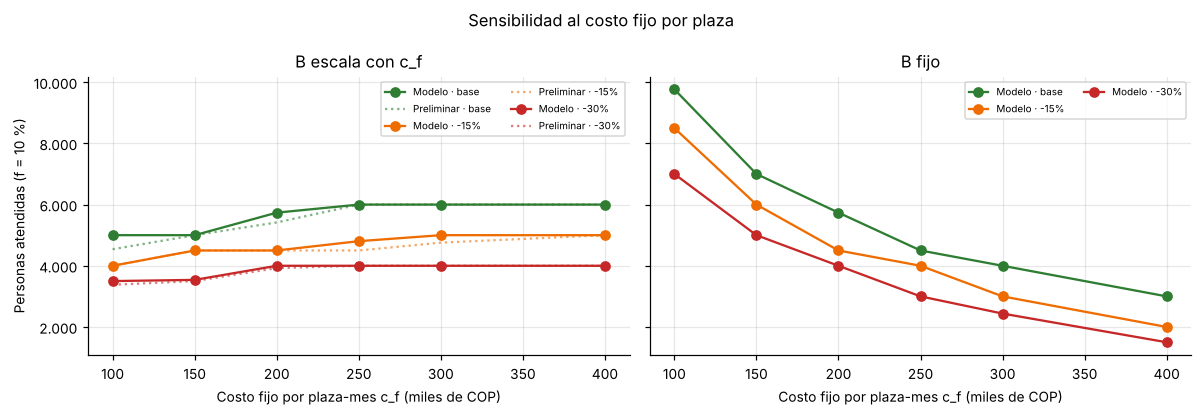

In [29]:
pre = pd.read_csv(RAW / "preliminar" / "sensibilidad_costo_fijo_preliminar.csv")
if RAPIDO:                       # modo rápido: solo f = 10 % (18 de las 72 combinaciones)
    pre = pre[pre.f == "10%"].reset_index(drop=True)
map_f = {"2%": "d_f02", "5%": "d_f05", "10%": "d_f10", "13%": "d_f13"}
map_e = {"base": 1.0, "-15%": 1 - RED_A, "-30%": 1 - RED_B}
filas = []
for r in pre.itertuples():
    for regla, fijo in (("B escala con c_f", False), ("B fijo", True)):
        sol = exigir_optimo(resolver(crear_instancia(col_demanda=map_f[r.f], factor_presupuesto=map_e[r.escenario],
                                                     factor_cf=r.c_f / 200000, presupuesto_fijo=fijo), "cf"))
        k = kpis(sol); cats = cand.loc[[j for j in sol["y"] if sol["y"][j]], "categoria"].value_counts()
        filas.append(dict(regla_presupuesto=regla, c_f=r.c_f, escenario=r.escenario, f=r.f, presupuesto_MM=round(k["Presupuesto"] / 1e6, 1),
                          demanda=k["Población que requiere campamento"], atendidos_modelo=k["Población atendida"],
                          pct_modelo=round(100 * k["% atendida"], 1),
                          sitios_g_i_p=f"({cats.get('Grande', 0)}, {cats.get('Intermedia', 0)}, {cats.get('Pequeña', 0)})",
                          sitios=k["Sitios abiertos"], dist_media_km=round(k["Distancia promedio ponderada (km)"], 1),
                          techo_preliminar=r.techo_personas if not fijo else np.nan, sitios_preliminar=r.sitios_g_i_p if not fijo else ""))
sens_cf = pd.DataFrame(filas)
sens_cf["diferencia_vs_preliminar"] = sens_cf.atendidos_modelo - sens_cf.techo_preliminar
esc_ = sens_cf[sens_cf.regla_presupuesto == "B escala con c_f"].reset_index(drop=True)
assert (esc_.presupuesto_MM == pre.presupuesto_MM).all() and (esc_.demanda == pre.demanda).all()
md(f"✔ Con la regla del enunciado, presupuestos y demandas coinciden con la tabla preliminar. **Atendidos:** el modelo coincide con el "
   f"'techo' preliminar en {(esc_.diferencia_vs_preliminar == 0).sum()} de {len(esc_)} combinaciones; difiere en {(esc_.diferencia_vs_preliminar != 0).sum()} "
   f"(máxima diferencia {es(esc_.diferencia_vs_preliminar.abs().max())} personas). Las cifras preliminares quedan **reemplazadas** por estas.")
piv = (sens_cf[sens_cf.f == "10%"].pivot_table(index="c_f", columns=["regla_presupuesto", "escenario"], values="atendidos_modelo")
       .reindex(columns=pd.MultiIndex.from_product([["B escala con c_f", "B fijo"], ["base", "-15%", "-30%"]])))
display(piv.style.format(es).set_caption("Personas atendidas con f = 10 % según c_f (COP/plaza-mes), regla de presupuesto y escenario"))

fig, axs = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, regla in zip(axs, ["B escala con c_f", "B fijo"]):
    for esc, col in zip(["base", "-15%", "-30%"], [VERDE, NARANJA, ROJO]):
        s_ = sens_cf[(sens_cf.f == "10%") & (sens_cf.escenario == esc) & (sens_cf.regla_presupuesto == regla)]
        ax.plot(s_.c_f / 1000, s_.atendidos_modelo, marker="o", color=col, label=f"Modelo · {esc}")
        if regla == "B escala con c_f":
            ax.plot(s_.c_f / 1000, s_.techo_preliminar, ls=":", color=col, alpha=0.6, label=f"Preliminar · {esc}")
    ax.set_xlabel("Costo fijo por plaza-mes c_f (miles de COP)"); ax.set_title(regla); ax.grid(alpha=0.3); ax.legend(fontsize=6.5, ncol=2)
axs[0].set_ylabel("Personas atendidas (f = 10 %)")
axs[0].yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda v, _: es(v)))
plt.suptitle("Sensibilidad al costo fijo por plaza"); plt.tight_layout(); plt.savefig(FIG / "08_sensibilidad_costo_fijo.png", dpi=160); plt.show()

In [30]:
ks = {n: kpis(ESCENARIOS[n]) for n in SENS}
f_ns = ["f = 2 % (cercano a lo observado)", "f = 5 %", "f = 8,3 % (mínimo ABAG/Hazus)", "Base", "f = 11,6 % (central ABAG/Hazus)", "f = 13 % (extremo ABAG)"]
f_tab = pd.DataFrame({n: kpis(ESCENARIOS[n]) for n in f_ns}).T[["Población que requiere campamento", "Población atendida", "% atendida"]]
at_f5 = f_tab.loc[f_ns[1:], "Población atendida"]
pb, pe = piv[("B escala con c_f", "base")], piv[("B fijo", "base")]
md(f'''### Interpretación de la sensibilidad
- **La fracción $f$ es el supuesto dominante sobre la necesidad**, no sobre la respuesta: con f = 2 % ({es(ks["f = 2 % (cercano a lo observado)"]["Población que requiere campamento"])} personas)
  se atiende al **{pct(ks["f = 2 % (cercano a lo observado)"]["% atendida"], 0)}**; con f ≥ 5 % el presupuesto se agota y los atendidos quedan entre
  **{es(at_f5.min())} y {es(at_f5.max())}** personas (f de 5 % a 13 %). Es decir, **el presupuesto fija cuántas personas se atienden; $f$ fija cuántas quedan por fuera**.
- **Distancia máxima:** con 120, 150 o 210 km la red base no cambia ({"; ".join(f"{n.split()[-2]} km: {ks[n]['Sitios abiertos']}, {es(ks[n]['Población atendida'])}" for n in ["Distancia máx. 120 km", "Distancia máx. 150 km", "Distancia máx. 210 km"])}).
  El umbral está en {es(UMBRAL_D)} km (sección 7.3).
- **Economías de escala (φ):** sin ellas (φ = 1 en todas las categorías, y $B$ recalculado con la regla del enunciado) se atiende a
  {es(ks["Sin economías de escala (φ = 1)"]["Población atendida"])} personas con {ks["Sin economías de escala (φ = 1)"]["Sitios abiertos"]}. La preferencia por los campamentos grandes
  depende en buena parte de φ, que es un supuesto propio.
- **Costo fijo $c_f$ — dos lecturas:** si $B$ escala con $c_f$ (regla del enunciado), un $c_f$ mayor deja relativamente más dinero para kits y
  transporte y los atendidos van de {es(pb.min())} a {es(pb.max())}; **con $B$ fijo en COP el efecto es el esperado**: los atendidos caen de
  {es(pe.max())} ($c_f$ = {es(pe.idxmax())}) a {es(pe.min())} ($c_f$ = {es(pe.idxmin())}). El resultado base es sensible a $c_f$, que sigue siendo un supuesto provisional.
- **Fuente de distancias:** con la matriz solo OSRM se atiende a {es(ks["Distancias solo OSRM (sin verificación Google)"]["Población atendida"])} personas con
  {ks["Distancias solo OSRM (sin verificación Google)"]["Sitios abiertos"]}: la verificación con Google Maps no cambia la decisión.
- **Reserva La Tebaida:** {"no cambia la red" if ks["Con reserva La Tebaida"]["Sitios abiertos"] == K_BASE["Sitios abiertos"] else "cambia la red: " + ks["Con reserva La Tebaida"]["Sitios abiertos"]}.
- **Fuente de distancias (+48 pares de 140–160 km verificados el 5-oct):** {es(ks["Distancias + 48 pares Google de 140–160 km"]["Población atendida"])} atendidos con
  {ks["Distancias + 48 pares Google de 140–160 km"]["Sitios abiertos"]}: la red base no cambia.
- **Candidatos pequeños y alcance del presupuesto (PENDIENTES del profesor):** ver la sección 9.0. Sin pequeños la base no cambia solo si se
  conserva $B$; con $B$ recalculado baja a {es(gr.loc["base", "atendidos"])}. Con R4' (tope solo sobre fijos) la base sube a {es(g4.loc["base", "atendidos"])}.
- **Tarifa de transporte × 1,5:** {es(ks["Tarifa de transporte × 1,5"]["Población atendida"])} atendidos con {ks["Tarifa de transporte × 1,5"]["Sitios abiertos"]}.
''')

### Interpretación de la sensibilidad
- **La fracción $f$ es el supuesto dominante sobre la necesidad**, no sobre la respuesta: con f = 2 % (3.777 personas)
  se atiende al **100 %**; con f ≥ 5 % el presupuesto se agota y los atendidos quedan entre
  **5.500 y 5.822** personas (f de 5 % a 13 %). Es decir, **el presupuesto fija cuántas personas se atienden; $f$ fija cuántas quedan por fuera**.
- **Distancia máxima:** con 120, 150 o 210 km la red base no cambia (120 km: Palmira, Tuluá, 5.736; 150 km: Palmira, Tuluá, 5.736; 210 km: Palmira, Tuluá, 5.736).
  El umbral está en 90 km (sección 7.3).
- **Economías de escala (φ):** sin ellas (φ = 1 en todas las categorías, y $B$ recalculado con la regla del enunciado) se atiende a
  5.500 personas con Jamundí, Cartago, Candelaria, Yumbo, Florida, Pradera, Chinchiná. La preferencia por los campamentos grandes
  depende en buena parte de φ, que es un supuesto propio.
- **Costo fijo $c_f$ — dos lecturas:** si $B$ escala con $c_f$ (regla del enunciado), un $c_f$ mayor deja relativamente más dinero para kits y
  transporte y los atendidos van de 5.000 a 6.000; **con $B$ fijo en COP el efecto es el esperado**: los atendidos caen de
  9.767 ($c_f$ = 100.000) a 3.000 ($c_f$ = 400.000). El resultado base es sensible a $c_f$, que sigue siendo un supuesto provisional.
- **Fuente de distancias:** con la matriz solo OSRM se atiende a 5.733 personas con
  Palmira, Tuluá: la verificación con Google Maps no cambia la decisión.
- **Reserva La Tebaida:** no cambia la red.
- **Fuente de distancias (+48 pares de 140–160 km verificados el 5-oct):** 5.736 atendidos con
  Palmira, Tuluá: la red base no cambia.
- **Candidatos pequeños y alcance del presupuesto (PENDIENTES del profesor):** ver la sección 9.0. Sin pequeños la base no cambia solo si se
  conserva $B$; con $B$ recalculado baja a 4.089. Con R4' (tope solo sobre fijos) la base sube a 6.500.
- **Tarifa de transporte × 1,5:** 5.500 atendidos con Palmira, Cartago, Yumbo, Chinchiná.


### 9.2 Robustez: ¿qué campamentos se abren en todos los escenarios?

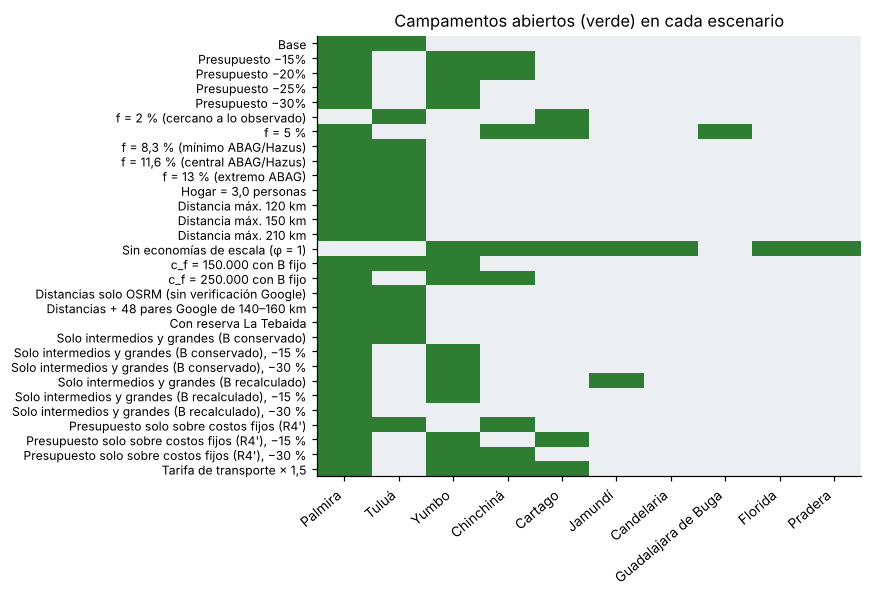

**Abiertos en todos los escenarios:** ninguno. Palmira se abre en 28 de 30 escenarios; no se abre en: f = 2 % (cercano a lo observado), Sin economías de escala (φ = 1) · **Dependen del escenario:** Palmira, Tuluá, Yumbo, Chinchiná, Cartago, Jamundí, Candelaria, Guadalajara de Buga, Florida, Pradera · **Nunca abiertos:** Aguadas, El Cerrito, Ginebra, Guacarí, La Dorada, Pensilvania, Supía.

In [31]:
mat = pd.DataFrame({n: {NOM[j]: r["y"].get(j, 0) for j in J_BASE + J_RESERVA} for n, r in ESCENARIOS.items() if r["estado"] == "Optimal"}).T
mat = mat.loc[:, mat.sum() > 0]
mat = mat[mat.mean().sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.imshow(mat.values, cmap=matplotlib.colors.ListedColormap(["#eceff1", VERDE]), aspect="auto")
ax.set_xticks(range(mat.shape[1])); ax.set_xticklabels(mat.columns, rotation=40, ha="right")
ax.set_yticks(range(mat.shape[0])); ax.set_yticklabels(mat.index, fontsize=8)
ax.set_title("Campamentos abiertos (verde) en cada escenario"); plt.tight_layout()
plt.savefig(FIG / "09_robustez_aperturas.png", dpi=160); plt.show()
freq = mat.mean()
sin_palmira = [n for n in mat.index if mat.loc[n, "Palmira"] == 0]
md(f"**Abiertos en todos los escenarios:** {', '.join(freq[freq == 1].index) or 'ninguno'}. Palmira se abre en {int(mat['Palmira'].sum())} de {len(mat)} "
   f"escenarios; no se abre en: {', '.join(sin_palmira) or '—'} · "
   f"**Dependen del escenario:** {', '.join(freq[(freq > 0) & (freq < 1)].index)} · "
   f"**Nunca abiertos:** {', '.join(sorted(set(NOM[j] for j in J_BASE) - set(mat.columns)))}.")

## 10. Extensión propia: equidad territorial (piso departamental α y piso municipal β)

**Problema que resuelve.** La solución base es eficiente pero deja departamentos y municipios grandes sin ninguna atención (ver
sección 6). En una respuesta humanitaria, dejar fuera territorios completos no es aceptable política ni éticamente (principio de
imparcialidad). La extensión agrega una **nueva variable de decisión** y **dos nuevas familias de restricciones**:

| Elemento | Definición |
|---|---|
| Nuevo conjunto | $k \in \mathcal{K}$ = departamentos (Valle del Cauca, Risaralda, Caldas, Quindío); $I_k \subseteq I$ municipios de $k$ |
| Nueva variable | $\alpha \in [0,1]$: cobertura mínima garantizada a **todos** los departamentos |
| (E1) nueva familia | $\displaystyle\sum_{i\in I_k}\sum_{j\in J_i} x_{ij} \;\ge\; \alpha \sum_{i\in I_k} d_i \qquad \forall k\in\mathcal{K}$ |
| (E2) piso de política | $\alpha \ge \underline{\alpha}$ (el decisor fija el piso) |
| (E3) nueva familia (piso municipal) | $\displaystyle\sum_{j\in J_i} x_{ij} \;\ge\; \beta\, d_i \qquad \forall i\in I$, con $\beta\in[0,1]$ parámetro de política |

**Uso.** (1) Se calcula el máximo piso alcanzable $\alpha^* = \max \alpha$ s.a. R1–R5 y E1 (problema *max-min*) **resolviendo el MILP
directamente** (MILP max α) y se comprueba que el piso de la siguiente décima de punto es infactible. Como $x_{ij}$ es entero, $\alpha^*$ es un cociente exacto
(personas / demanda del departamento que limita) y se reporta con dos decimales; **no se redondea hacia arriba**, porque un piso
mayor que $\alpha^*$ es infactible. (2) Para cada piso $\underline{\alpha}\in[0,\alpha^*]$ se resuelve el modelo lexicográfico con
E1–E2 y se traza la **frontera eficiencia–equidad**; la pérdida de personas atendidas frente a la base es el **precio de la equidad**.
(3) Igual con el piso municipal $\beta$ (E3), que además obliga a que **ningún municipio** quede en 0 %.

In [32]:
def _modelo_equidad(inst, nombre, beta_min=None, alpha_var=True):
    m, y, x, u, atendidos, costo, Ji = construir_modelo(inst, nombre)
    alpha = agregar_equidad(m, x, Ji, inst, beta_min=beta_min, alpha_var=alpha_var)
    return m, x, Ji, alpha, atendidos

def alpha_maximo(inst, beta_min=None):
    """α* exacto: max α s.a. R1–R5, E1 (y E3 si se da β). Devuelve (α*, estado)."""
    m, x, Ji, alpha, _ = _modelo_equidad(inst, "alpha_max", beta_min)
    m.setObjective(alpha); m.sense = pulp.LpMaximize
    e = resolver_cbc(m, "alpha_max", "máx. α", SOLVER_EQ)
    if e == "Infeasible":
        return np.nan, e
    if e != "Optimal":
        raise RuntimeError(f"α* sin optimalidad certificada: {e}")
    return float(alpha.value()), e

def beta_maximo(inst):
    """β* exacto: max β s.a. R1–R5 y Σ_j x_ij ≥ β d_i ∀i."""
    m, y, x, u, atendidos, costo, Ji = construir_modelo(inst, "beta_max")
    beta = pulp.LpVariable("beta", lowBound=0, upBound=1)
    for i in I:
        m += pulp.lpSum(x[(i, j)] for j in Ji[i]) >= beta * inst["d"][i], f"E3_{i}"
    m.setObjective(beta); m.sense = pulp.LpMaximize
    e = resolver_cbc(m, "beta_max", "máx. β", SOLVER_EQ)
    if e != "Optimal":
        raise RuntimeError(f"β* sin optimalidad certificada: {e}")
    return float(beta.value())

def factible_pisos(inst, alpha_min=None, beta_min=None, nombre="factibilidad"):
    """Solo factibilidad (etapa 1). Un corte por tiempo con solución entera sí prueba factibilidad; sin solución, se detiene."""
    m, y, x, u, atendidos, costo, Ji = construir_modelo(inst, nombre)
    agregar_equidad(m, x, Ji, inst, alpha_min=alpha_min, beta_min=beta_min)
    m.setObjective(atendidos); m.sense = pulp.LpMaximize
    e = resolver_cbc(m, nombre, "factibilidad de pisos", SOLVER_EQ)
    if e == "Infeasible":
        return False
    if e == "Optimal" or e.startswith("Factible"):
        return True
    raise RuntimeError(f"Factibilidad indeterminada: {e}")

t0 = time.time()
ALPHA_MAX, _ = alpha_maximo(INST_BASE)
ALPHA_APLICA = ALPHA_MAX - 1e-7          # tolerancia numérica para imponer exactamente α*
ALPHA_SIG = np.ceil(ALPHA_MAX * 1000 + 1e-9) / 1000   # siguiente décima de punto porcentual
assert factible_pisos(INST_BASE, alpha_min=ALPHA_APLICA, nombre="factibilidad_alpha_max")
assert not factible_pisos(INST_BASE, alpha_min=ALPHA_SIG, nombre="prueba_infactible_alpha_siguiente_decima")   # infactible A PROPÓSITO
md(f"**Resultado matemático:** el máximo piso departamental alcanzable con el presupuesto base es **α\\* = {pct_abajo(ALPHA_MAX, 2)}** "
   f"(MILP max α, óptimo certificado, {es(time.time() - t0, 1)} s). Comprobación: el piso α\\* es factible y un piso de {pct(ALPHA_SIG, 1)} es "
   f"**infactible**; con un decimal α\\* se reporta como {pct_abajo(ALPHA_MAX, 1)} (truncado hacia abajo), nunca como un valor mayor. "
   f"La cobertura total máxima sin piso es {pct(K_BASE['% atendida'])}.")

**Resultado matemático:** el máximo piso departamental alcanzable con el presupuesto base es **α\* = 29,05 %** (MILP max α, óptimo certificado, 8,3 s). Comprobación: el piso α\* es factible y un piso de 29,1 % es **infactible**; con un decimal α\* se reporta como 29,0 % (truncado hacia abajo), nunca como un valor mayor. La cobertura total máxima sin piso es 30,4 %.

In [33]:
PISOS = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25]
PISOS = [p_ for p_ in PISOS if p_ < ALPHA_MAX] + [ALPHA_APLICA]
FRONTERA = []
for a_ in PISOS:
    r = exigir_optimo(resolver(INST_BASE, f"equidad_{a_:.4f}", alpha_min=a_))
    assert (pruebas_post(r).Resultado == "PASS").all()
    k = kpis(r)
    FRONTERA.append(dict(piso_alpha=a_ if a_ != ALPHA_APLICA else ALPHA_MAX, es_alpha_max=a_ == ALPHA_APLICA,
                         atendidos=k["Población atendida"], pct=k["% atendida"], sitios=k["Sitios abiertos"],
                         costo=k["Costo total"], dist_media=k["Distancia promedio ponderada (km)"], dist_max=k["Distancia máxima recorrida (km)"],
                         mun_sin_atencion=k["Municipios con cobertura 0 %"], cobertura_min_dep=k["Cobertura mínima departamental"],
                         **{f"cob_{d_[:5]}": k[f"Cobertura {d_}"] for d_ in DEPTOS}, res=r))
fr = pd.DataFrame(FRONTERA)
fr["precio_equidad"] = fr.atendidos.iloc[0] - fr.atendidos
display(fr.drop(columns="res").style.format({"piso_alpha": lambda v: pct_abajo(v, 2), "atendidos": es, "pct": pct, "costo": mcop,
        "dist_media": lambda v: es(v, 1), "dist_max": lambda v: es(v, 1), "cobertura_min_dep": lambda v: pct(v, 2),
        "precio_equidad": es, **{f"cob_{d_[:5]}": pct for d_ in DEPTOS}}).hide(axis="index"))

piso_alpha,es_alpha_max,atendidos,pct,sitios,costo,dist_media,dist_max,mun_sin_atencion,cobertura_min_dep,cob_Calda,cob_Quind,cob_Risar,cob_Valle,precio_equidad
"0,00 %",False,5.736,"30,4 %","Palmira, Tuluá","$3.547,5 M","50,0","89,1",15,"0,00 %","0,0 %","57,6 %","0,0 %","51,0 %",0
"5,00 %",False,5.674,"30,1 %","Palmira, Tuluá","$3.547,5 M","51,8","171,0",12,"5,00 %","5,0 %","36,0 %","5,0 %","51,0 %",62
"10,00 %",False,5.610,"29,7 %","Palmira, Tuluá","$3.547,5 M","53,8","171,0",12,"10,00 %","10,0 %","14,4 %","10,0 %","51,0 %",126
"15,00 %",False,5.505,"29,2 %","Palmira, Tuluá","$3.547,4 M","57,1","171,0",16,"15,00 %","15,0 %","15,0 %","15,0 %","45,2 %",231
"20,00 %",False,5.500,"29,1 %","Palmira, Cartago, Guadalajara de Buga, Chinchiná","$3.514,5 M","39,8","141,9",17,"20,00 %","20,0 %","20,0 %","20,0 %","39,5 %",236
"25,00 %",False,5.500,"29,1 %","Palmira, Cartago, Guadalajara de Buga, Chinchiná","$3.541,6 M","49,7","167,0",22,"25,00 %","25,0 %","25,0 %","25,0 %","33,8 %",236
"29,05 %",True,5.486,"29,1 %","Tuluá, Cartago, Yumbo, Chinchiná","$3.547,5 M","52,2","117,0",10,"29,05 %","29,1 %","29,1 %","29,1 %","29,1 %",250


In [34]:
ACEPTABLE = 0.05   # criterio propuesto: perder como máximo 5 % de los atendidos frente a la solución eficiente
ELEG = fr[fr.atendidos >= (1 - ACEPTABLE) * fr.atendidos.iloc[0]].iloc[-1]
EQ = ELEG.res; K_EQ = kpis(EQ); _, cam_eq, dem_eq = tablas(EQ)
ETQ_ALPHA = f"α = {pct_abajo(ELEG.piso_alpha, 2)}" + (" (α*)" if ELEG.es_alpha_max else "")

### 10.1 Piso municipal β (familia E3)
El piso departamental puede cumplirse concentrando cupos en pocos municipios de cada departamento. E3 protege a **cada municipio**.
Se calcula $\beta^*$ (máximo piso municipal factible) y la frontera para $\beta \in [0, \beta^*]$; para cada β se reporta también el
máximo piso departamental $\alpha^*(\beta)$ que sigue siendo alcanzable.

In [35]:
BETA_MAX = beta_maximo(INST_BASE)
BETAS = [b_ for b_ in [0.0, 0.025, 0.05, 0.075, 0.10, 0.15, 0.20, 0.25] if b_ < BETA_MAX] + [BETA_MAX - 1e-7]
FR_B = []
for b_ in BETAS:
    r = exigir_optimo(resolver(INST_BASE, f"beta_{b_:.4f}", beta_min=b_))
    assert (pruebas_post(r).Resultado == "PASS").all()
    k = kpis(r); a_b, _ = alpha_maximo(INST_BASE, beta_min=b_)
    _, _, t_d = tablas(r)
    FR_B.append(dict(piso_beta=min(b_ + 1e-7, BETA_MAX) if b_ > 0 else 0.0, atendidos=k["Población atendida"], pct=k["% atendida"],
                     precio_equidad=K_BASE["Población atendida"] - k["Población atendida"], sitios=k["Sitios abiertos"],
                     n_sitios=k["Campamentos abiertos"], costo=k["Costo total"], dist_media=k["Distancia promedio ponderada (km)"],
                     dist_max=k["Distancia máxima recorrida (km)"], mun_sin_atencion=k["Municipios con cobertura 0 %"],
                     cobertura_min_municipal=t_d.cobertura.min(), cobertura_min_dep=k["Cobertura mínima departamental"],
                     alpha_max_con_beta=a_b, res=r))
frb = pd.DataFrame(FR_B)
display(frb.drop(columns="res").style.format({"piso_beta": lambda v: pct_abajo(v, 2), "atendidos": es, "pct": pct, "precio_equidad": es,
        "costo": mcop, "dist_media": lambda v: es(v, 1), "dist_max": lambda v: es(v, 1), "cobertura_min_municipal": lambda v: pct(v, 1),
        "cobertura_min_dep": lambda v: pct(v, 1), "alpha_max_con_beta": lambda v: pct_abajo(v, 2)}).hide(axis="index"))
ELEG_B = frb[(frb.piso_beta > 0) & (frb.atendidos >= (1 - ACEPTABLE) * K_BASE["Población atendida"])]
ELEG_B = ELEG_B.iloc[-1] if len(ELEG_B) else None
# Variante recomendada: el menor piso municipal positivo de la grilla (β = 2,5 %). Basta cualquier β > 0 para que ningún municipio
# quede en 0 %, y el menor β es el que menos personas cuesta.
BETA_REC = frb[frb.piso_beta > 0].iloc[0]
assert BETA_REC.mun_sin_atencion == 0

piso_beta,atendidos,pct,precio_equidad,sitios,n_sitios,costo,dist_media,dist_max,mun_sin_atencion,cobertura_min_municipal,cobertura_min_dep,alpha_max_con_beta
"0,00 %",5.736,"30,4 %",0,"Palmira, Tuluá",2,"$3.547,5 M","50,0","89,1",15,"0,0 %","0,0 %","29,05 %"
"2,50 %",5.687,"30,1 %",49,"Palmira, Tuluá",2,"$3.547,5 M","51,4","172,0",0,"2,5 %","2,5 %","28,97 %"
"5,00 %",5.639,"29,9 %",97,"Palmira, Tuluá",2,"$3.547,4 M","52,9","172,0",0,"5,0 %","5,0 %","28,90 %"
"7,50 %",5.592,"29,6 %",144,"Palmira, Tuluá",2,"$3.547,5 M","54,4","172,0",0,"7,5 %","7,5 %","28,80 %"
"10,00 %",5.531,"29,3 %",205,"Palmira, Tuluá",2,"$3.547,5 M","56,3","172,0",0,"10,0 %","10,0 %","28,69 %"
"15,00 %",5.500,"29,1 %",236,"Palmira, Cartago, Guadalajara de Buga, Chinchiná",4,"$3.515,5 M","40,2","121,9",0,"15,0 %","15,0 %","28,46 %"
"20,00 %",5.488,"29,1 %",248,"Palmira, Cartago, Guadalajara de Buga, Chinchiná",4,"$3.547,4 M","52,2","144,0",0,"20,0 %","20,0 %","28,18 %"
"25,00 %",5.311,"28,1 %",425,"Tuluá, Cartago, Yumbo, Chinchiná",4,"$3.547,4 M","57,9","135,1",0,"25,0 %","25,0 %","27,57 %"
"27,05 %",5.124,"27,1 %",612,"Tuluá, Cartago, Yumbo, Chinchiná",4,"$3.547,5 M","64,4","135,1",0,"27,1 %","27,1 %","27,07 %"


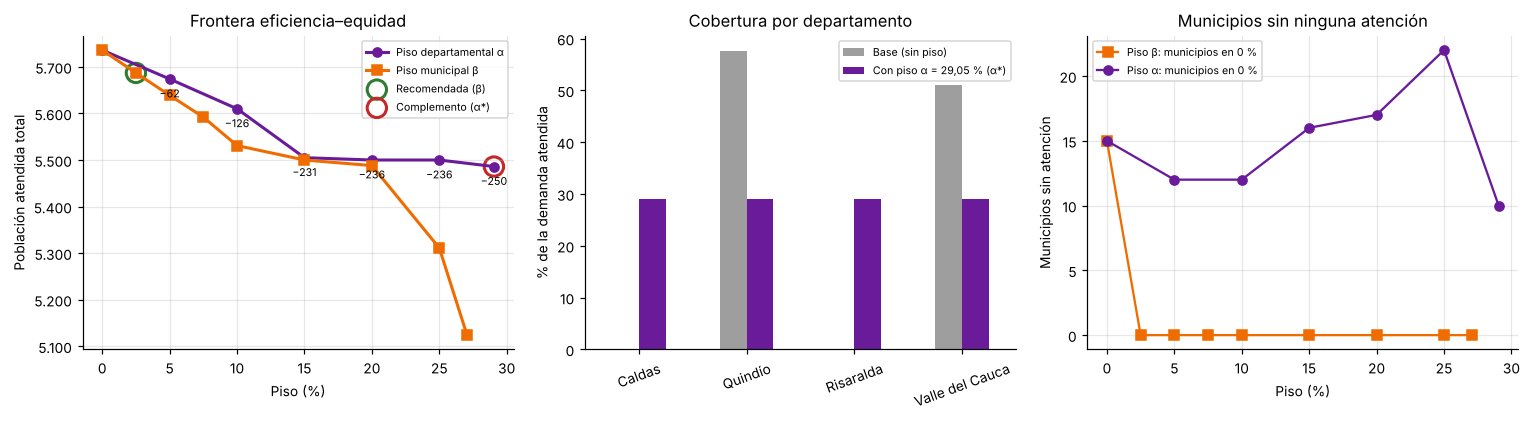

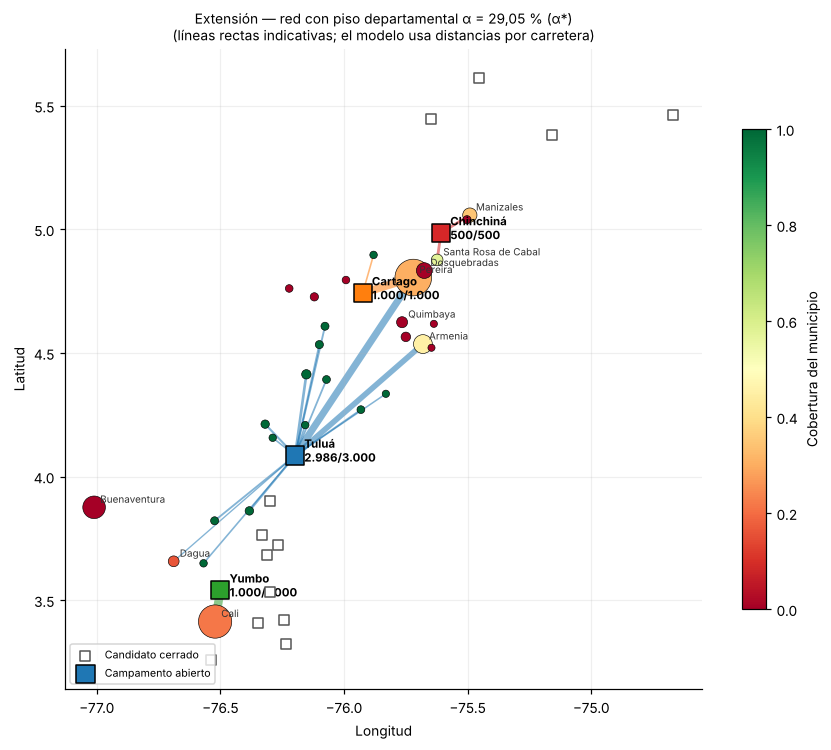

In [36]:
fig, axs = plt.subplots(1, 3, figsize=(14, 3.9))
axs[0].plot(fr.piso_alpha * 100, fr.atendidos, marker="o", color="#6a1b9a", lw=2, label="Piso departamental α")
axs[0].plot(frb.piso_beta * 100, frb.atendidos, marker="s", color=NARANJA, lw=2, label="Piso municipal β")
for r in fr.itertuples():
    axs[0].annotate(f"−{es(r.precio_equidad)}" if r.precio_equidad else "", (r.piso_alpha * 100, r.atendidos), xytext=(0, -12), textcoords="offset points", ha="center", fontsize=7)
axs[0].scatter([BETA_REC.piso_beta * 100], [BETA_REC.atendidos], s=160, facecolor="none", edgecolor=VERDE, lw=2, label="Recomendada (β)")
axs[0].scatter([ELEG.piso_alpha * 100], [ELEG.atendidos], s=160, facecolor="none", edgecolor=ROJO, lw=2, label="Complemento (α*)")
axs[0].set_xlabel("Piso (%)"); axs[0].set_ylabel("Población atendida total")
axs[0].yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda v, _: es(v)))
axs[0].set_title("Frontera eficiencia–equidad"); axs[0].legend(fontsize=7); axs[0].grid(alpha=0.3)
cdep = pd.DataFrame({"Base (sin piso)": [K_BASE[f"Cobertura {d_}"] for d_ in DEPTOS],
                     f"Con piso {ETQ_ALPHA}": [K_EQ[f"Cobertura {d_}"] for d_ in DEPTOS]}, index=DEPTOS)
cdep.mul(100).plot.bar(ax=axs[1], color=[GRIS, "#6a1b9a"], rot=20)
axs[1].set_ylabel("% de la demanda atendida"); axs[1].set_title("Cobertura por departamento"); axs[1].legend(fontsize=7)
axs[2].plot(frb.piso_beta * 100, frb.mun_sin_atencion, marker="s", color=NARANJA, label="Piso β: municipios en 0 %")
axs[2].plot(fr.piso_alpha * 100, fr.mun_sin_atencion, marker="o", color="#6a1b9a", label="Piso α: municipios en 0 %")
axs[2].set_xlabel("Piso (%)"); axs[2].set_ylabel("Municipios sin atención"); axs[2].set_title("Municipios sin ninguna atención")
axs[2].legend(fontsize=7); axs[2].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIG / "10_extension_equidad.png", dpi=160); plt.show()
mapa(EQ, f"Extensión — red con piso departamental {ETQ_ALPHA}", "11_mapa_red_equidad.png")

In [37]:
# La extensión bajo los presupuestos recortados (α* exacto en cada nivel)
ext_esc = []
for n, fac in (("Base", 1.0), (N_A, 1 - RED_A), (N_B, 1 - RED_B)):
    inst = crear_instancia(factor_presupuesto=fac)
    am, _ = alpha_maximo(inst)
    r0 = ESCENARIOS[n]; k0 = kpis(r0)
    r1 = exigir_optimo(resolver(inst, f"eq_{n}", alpha_min=am - 1e-7)); k1 = kpis(r1)
    bm = beta_maximo(inst)
    ext_esc.append(dict(escenario=n, alpha_max=am, atendidos_sin_piso=k0["Población atendida"], atendidos_con_alpha_max=k1["Población atendida"],
                        precio_equidad=k0["Población atendida"] - k1["Población atendida"],
                        cob_min_sin_piso=k0["Cobertura mínima departamental"], cob_min_con_piso=k1["Cobertura mínima departamental"],
                        mun_sin_atencion_sin_piso=k0["Municipios con cobertura 0 %"], mun_sin_atencion_con_piso=k1["Municipios con cobertura 0 %"],
                        sitios_con_piso=k1["Sitios abiertos"], beta_max=bm))
ext_esc = pd.DataFrame(ext_esc)
display(ext_esc.style.format({"alpha_max": lambda v: pct_abajo(v, 2), "atendidos_sin_piso": es, "atendidos_con_alpha_max": es,
                              "precio_equidad": es, "cob_min_sin_piso": lambda v: pct(v, 2), "cob_min_con_piso": lambda v: pct(v, 2),
                              "beta_max": lambda v: pct_abajo(v, 2)}).hide(axis="index"))

escenario,alpha_max,atendidos_sin_piso,atendidos_con_alpha_max,precio_equidad,cob_min_sin_piso,cob_min_con_piso,mun_sin_atencion_sin_piso,mun_sin_atencion_con_piso,sitios_con_piso,beta_max
Base,"29,05 %",5.736,5.486,250,"0,00 %","29,05 %",15,10,"Tuluá, Cartago, Yumbo, Chinchiná","27,05 %"
Presupuesto −15%,"23,82 %",4.500,4.500,0,"0,00 %","23,83 %",26,10,"Tuluá, Cartago, Chinchiná","23,75 %"
Presupuesto −30%,"20,21 %",4.000,3.818,182,"0,00 %","20,21 %",28,12,"Tuluá, Cartago","18,46 %"


In [38]:
pe_ = dem_eq.loc[dem.municipio == "Pereira"].iloc[0]
dep_cero = [d_ for d_ in DEPTOS if K_BASE[f"Cobertura {d_}"] == 0]
md(f'''### Interpretación de la extensión
- **Piso departamental:** α\\* = **{pct_abajo(ALPHA_MAX, 2)}**. Garantizar a cada departamento **{pct_abajo(ELEG.piso_alpha, 2)}** de su demanda cuesta
  **{es(ELEG.precio_equidad)} personas** ({pct(ELEG.precio_equidad / fr.atendidos.iloc[0])} de los atendidos) y cambia la red a: **{ELEG.sitios}**.
- Departamentos en 0 % en la base: {", ".join(dep_cero) or "ninguno"}; con el piso, la cobertura por departamento queda en
  {"; ".join(f"{d_} {pct(K_EQ[f'Cobertura {d_}'], 2)}" for d_ in DEPTOS)}. Pereira recibe {es(pe_.atendidos)} cupos ({pct(pe_.cobertura, 0)}).
  La distancia máxima sube de {es(K_BASE["Distancia máxima recorrida (km)"], 1)} a {es(K_EQ["Distancia máxima recorrida (km)"], 1)} km y, con pisos intermedios, llega a
  {es(fr.dist_max.max(), 0)} km: **con equidad el límite de 180 km sí empieza a importar**.
  Municipios sin atención: {K_BASE["Municipios con cobertura 0 %"]} → {K_EQ["Municipios con cobertura 0 %"]}.
- El precio de la equidad crece de {es(fr.precio_equidad.iloc[1])} personas (α = {pct(fr.piso_alpha.iloc[1], 0)}) a {es(fr.precio_equidad.iloc[-1])} (α\\*).
  α\\* no puede superar la cobertura total máxima ({pct(K_BASE["% atendida"])}), así que el piso máximo casi iguala a todos los departamentos.
- **Matiz: el piso departamental no protege municipios.** Los municipios sin atención según el piso α fueron
  {", ".join(f"{es(r.mun_sin_atencion)} (α = {(pct_abajo(r.piso_alpha, 2) if r.es_alpha_max else pct(r.piso_alpha, 0))})" for r in fr.itertuples())}: con pisos intermedios el modelo concentra cupos
  en pocos municipios y puede dejar **más** municipios en 0 % que la base.
- **Piso municipal β (E3, implementado):** el máximo factible es **β\\* = {pct_abajo(BETA_MAX, 2)}**. Exigir β > 0 obliga a que ningún municipio
  quede en 0 %; con β = {pct(frb.piso_beta.iloc[1], 1)} se atiende a {es(frb.atendidos.iloc[1])} personas (precio {es(frb.precio_equidad.iloc[1])})
  y con β\\* a {es(frb.atendidos.iloc[-1])} (precio {es(frb.precio_equidad.iloc[-1])}).
  {("El mayor β de la grilla que pierde ≤ " + pct(ACEPTABLE, 0) + " de los atendidos es β = " + pct(ELEG_B.piso_beta, 1) + f" ({ELEG_B.sitios}).") if ELEG_B is not None else "Ningún β > 0 de la grilla cumple el criterio de pérdida ≤ " + pct(ACEPTABLE, 0) + ": proteger a todos los municipios es caro con este presupuesto."}
- **Variante recomendada: piso municipal β = {pct(BETA_REC.piso_beta, 1)}.** Cuesta solo **{es(BETA_REC.precio_equidad)} personas**
  ({pct(BETA_REC.precio_equidad / K_BASE["Población atendida"])}), conserva la red base ({BETA_REC.sitios}) y deja **{int(BETA_REC.mun_sin_atencion)} municipios
  en 0 %** (frente a {K_BASE["Municipios con cobertura 0 %"]} en la base). El piso departamental no logra eso: con α = {pct(fr.piso_alpha.iloc[-2], 0)} quedan
  **{int(fr.mun_sin_atencion.iloc[-2])} municipios en 0 %** y con α\\* {int(fr.mun_sin_atencion.iloc[-1])}. Costo de β: la asignación más larga sube a
  {es(BETA_REC.dist_max, 0)} km (algunos municipios pequeños se atienden lejos, cerca del límite de 180 km).
- **α como complemento:** α\\* equilibra los departamentos (cada uno ≈ {pct_abajo(ALPHA_MAX, 1)}) a cambio de {es(ELEG.precio_equidad)} personas, pero no
  protege municipios. Si la autoridad exige ambos, $\\alpha^*(\\beta)$ sigue siendo alto (con β = {pct(BETA_REC.piso_beta, 1)}, α\\* = {pct_abajo(BETA_REC.alpha_max_con_beta, 2)}).
- El modelo no decide qué piso es correcto: muestra el costo exacto de cada nivel para que la autoridad decida. Ninguna extensión se
  eliminó: E1–E2 (α) y E3 (β) siguen formuladas e implementadas.
- Con recortes, α\\* cae ({", ".join(f"{r.escenario}: {pct_abajo(r.alpha_max, 2)}" for r in ext_esc.itertuples())}) y el precio de aplicarlo es
  {", ".join(f"{r.escenario}: {es(r.precio_equidad)} personas" for r in ext_esc.itertuples())}{" — en algún nivel la equidad es gratuita: existen redes igual de eficientes y más equitativas" if (ext_esc.precio_equidad == 0).any() else ""}.
''')

### Interpretación de la extensión
- **Piso departamental:** α\* = **29,05 %**. Garantizar a cada departamento **29,05 %** de su demanda cuesta
  **250 personas** (4,4 % de los atendidos) y cambia la red a: **Tuluá, Cartago, Yumbo, Chinchiná**.
- Departamentos en 0 % en la base: Caldas, Risaralda; con el piso, la cobertura por departamento queda en
  Caldas 29,07 %; Quindío 29,06 %; Risaralda 29,06 %; Valle del Cauca 29,05 %. Pereira recibe 1.706 cupos (30 %).
  La distancia máxima sube de 89,1 a 117,0 km y, con pisos intermedios, llega a
  171 km: **con equidad el límite de 180 km sí empieza a importar**.
  Municipios sin atención: 15 → 10.
- El precio de la equidad crece de 62 personas (α = 5 %) a 250 (α\*).
  α\* no puede superar la cobertura total máxima (30,4 %), así que el piso máximo casi iguala a todos los departamentos.
- **Matiz: el piso departamental no protege municipios.** Los municipios sin atención según el piso α fueron
  15 (α = 0 %), 12 (α = 5 %), 12 (α = 10 %), 16 (α = 15 %), 17 (α = 20 %), 22 (α = 25 %), 10 (α = 29,05 %): con pisos intermedios el modelo concentra cupos
  en pocos municipios y puede dejar **más** municipios en 0 % que la base.
- **Piso municipal β (E3, implementado):** el máximo factible es **β\* = 27,05 %**. Exigir β > 0 obliga a que ningún municipio
  quede en 0 %; con β = 2,5 % se atiende a 5.687 personas (precio 49)
  y con β\* a 5.124 (precio 612).
  El mayor β de la grilla que pierde ≤ 5 % de los atendidos es β = 20,0 % (Palmira, Cartago, Guadalajara de Buga, Chinchiná).
- **Variante recomendada: piso municipal β = 2,5 %.** Cuesta solo **49 personas**
  (0,9 %), conserva la red base (Palmira, Tuluá) y deja **0 municipios
  en 0 %** (frente a 15 en la base). El piso departamental no logra eso: con α = 25 % quedan
  **22 municipios en 0 %** y con α\* 10. Costo de β: la asignación más larga sube a
  172 km (algunos municipios pequeños se atienden lejos, cerca del límite de 180 km).
- **α como complemento:** α\* equilibra los departamentos (cada uno ≈ 29,0 %) a cambio de 250 personas, pero no
  protege municipios. Si la autoridad exige ambos, $\alpha^*(\beta)$ sigue siendo alto (con β = 2,5 %, α\* = 28,97 %).
- El modelo no decide qué piso es correcto: muestra el costo exacto de cada nivel para que la autoridad decida. Ninguna extensión se
  eliminó: E1–E2 (α) y E3 (β) siguen formuladas e implementadas.
- Con recortes, α\* cae (Base: 29,05 %, Presupuesto −15%: 23,82 %, Presupuesto −30%: 20,21 %) y el precio de aplicarlo es
  Base: 250 personas, Presupuesto −15%: 0 personas, Presupuesto −30%: 182 personas — en algún nivel la equidad es gratuita: existen redes igual de eficientes y más equitativas.


## 11. Auditoría del solver y exportación de resultados
Cada llamada al solver quedó registrada con `LpStatus` y `sol_status`. Una resolución cortada por `timeLimit` aparecería como
"Factible sin prueba de optimalidad" y **no** se usó como resultado (la función `exigir_optimo` detiene el notebook).

In [39]:
reg_solver = pd.DataFrame(REGISTRO_SOLVER)
resumen_solver = reg_solver.groupby("estado").agg(llamadas=("modelo", "count"), segundos_max=("segundos", "max"),
                                                  segundos_total=("segundos", "sum")).reset_index()
display(resumen_solver.style.format({"segundos_max": lambda v: es(v, 2), "segundos_total": lambda v: es(v, 1)}).hide(axis="index"))
cortes_tiempo = reg_solver.estado.str.startswith("Factible").sum()
assert set(reg_solver.estado) <= {"Optimal", "Infeasible"}, "Hay resoluciones sin optimalidad certificada"
infact = reg_solver[reg_solver.estado == "Infeasible"]
assert infact.modelo.str.startswith("prueba_infactible").all(), "Hay una resolución infactible que no es una prueba intencional"
N_OPT, N_INF = int((reg_solver.estado == "Optimal").sum()), len(infact)
por_solver = ", ".join(f"{k_}: {v_}" for k_, v_ in reg_solver.solver.value_counts().items())
md(f"✔ {len(reg_solver)} llamadas al solver ({por_solver}): **{N_OPT} óptimas certificadas + {N_INF} infactible a propósito** "
   f"(prueba de que el piso de la siguiente décima, {pct(ALPHA_SIG, 1)}, es infactible) y **{cortes_tiempo} cortadas por tiempo**. "
   f"Tiempo máximo de una llamada: {es(reg_solver.segundos.max(), 2)} s (límite {LIMITE_TIEMPO} s).")

estado,llamadas,segundos_max,segundos_total
Infeasible,1,"1,47","1,5"
Optimal,646,"32,71","560,3"


✔ 647 llamadas al solver (CBC: 592, HiGHS: 55): **646 óptimas certificadas + 1 infactible a propósito** (prueba de que el piso de la siguiente décima, 29,1 %, es infactible) y **0 cortadas por tiempo**. Tiempo máximo de una llamada: 32,71 s (límite 600 s).

### 11.1 ¿Se usan los pares que cambian de factibilidad con Google Maps?
Siete pares cambian de factibilidad a 180 km al pasar de OSRM a Google Maps; tres están a ≤ 3 km del corte (Google muestra km enteros).
Se revisa si alguna solución reportada asigna personas por esos arcos.

In [40]:
pares_cambio = [(i, j) for i in I for j in J_BASE if (dist.loc[i, j] <= D_MAX) != (dist_osrm.loc[i, j] <= D_MAX)]
assert len(pares_cambio) == 7
SOLUCIONES = {**{n: r for n, r in ESCENARIOS.items() if r["estado"] == "Optimal"},
              **{f"Frontera α = {pct_abajo(r_.piso_alpha, 2)}": r_.res for r_ in fr.itertuples()},
              **{f"Frontera β = {pct_abajo(r_.piso_beta, 2)}": r_.res for r_ in frb.itertuples()}}
filas = []
for (i, j) in pares_cambio:
    usos = {n: r["x"].get((i, j), 0) for n, r in SOLUCIONES.items() if r["x"].get((i, j), 0) > 0}
    filas.append(dict(origen=NOM[i], sitio=NOM[j], km_OSRM=round(dist_osrm.loc[i, j], 1), km_final=dist.loc[i, j],
                      factible_final=int(dist.loc[i, j] <= D_MAX), a_3km_del_corte=int(abs(dist.loc[i, j] - D_MAX) <= 3),
                      usado_en_base_o_recortes=int(any(n in usos for n in ("Base", N_A, N_B))),
                      soluciones_que_lo_usan=", ".join(f"{n} ({es(q)})" for n, q in usos.items()) or "ninguna"))
uso_pares = pd.DataFrame(filas).sort_values("a_3km_del_corte", ascending=False)
display(uso_pares.style.hide(axis="index"))
assert uso_pares.usado_en_base_o_recortes.sum() == 0, "Un arco frágil se usa en un escenario oficial: revisar"
dmax_ofic = max(kpis(ESCENARIOS[n])["Distancia máxima recorrida (km)"] for n in ("Base", N_A, N_B))
md(f"**Lectura.** Ningún arco que cambia de factibilidad se usa en la base, −15 % ni −30 % (asignación más larga de los tres: "
   f"{es(dmax_ofic, 1)} km). " + ("Sí aparecen en: " + "; ".join(f"{r.origen}–{r.sitio}: {r.soluciones_que_lo_usan}" for r in uso_pares.itertuples()
                                  if r.soluciones_que_lo_usan != "ninguna") + ". Esas soluciones son sensibilidades o pisos de equidad y dependen de un "
                                  "valor de Google Maps cercano al corte." if (uso_pares.soluciones_que_lo_usan != "ninguna").any()
                                  else "Tampoco se usan en las sensibilidades ni en las fronteras de equidad."))

origen,sitio,km_OSRM,km_final,factible_final,a_3km_del_corte,usado_en_base_o_recortes,soluciones_que_lo_usan
Armenia,Pradera,182.600000,178.000000,1,1,0,ninguna
Caicedonia,Supía,206.100000,178.000000,1,1,0,ninguna
El Cairo,Guadalajara de Buga,180.000000,181.000000,0,1,0,ninguna
Villamaría,La Dorada,212.900000,165.000000,1,0,0,ninguna
Manizales,La Dorada,213.800000,166.000000,1,0,0,ninguna
Ansermanuevo,Aguadas,177.800000,190.000000,0,0,0,ninguna
La Cumbre,Cartago,176.700000,187.000000,0,0,0,ninguna


**Lectura.** Ningún arco que cambia de factibilidad se usa en la base, −15 % ni −30 % (asignación más larga de los tres: 89,1 km). Tampoco se usan en las sensibilidades ni en las fronteras de equidad.

In [41]:
asig_eq = tablas(EQ)[0]
COL_EXT = f"Extensión α={pct_abajo(ELEG.piso_alpha, 2)}"
resumen = pd.DataFrame({n: pd.Series(kpis(r)) for n, r in [("Base", BASE), (N_A, ESCENARIOS[N_A]), (N_B, ESCENARIOS[N_B]), (COL_EXT, EQ)]})
todos_esc = pd.DataFrame({n: kpis(r) for n, r in ESCENARIOS.items() if r["estado"] == "Optimal"}).T
validaciones = pd.concat([val.assign(Etapa="Datos")] +
                         [pruebas_post(r).rename(columns={"Descripción": "Detalle"}).assign(Etapa=f"Post-solución {n}")
                          for n, r in [("Base", BASE), (N_A, ESCENARIOS[N_A]), (N_B, ESCENARIOS[N_B]), ("Extensión", EQ)]])
parametros_ext = pd.DataFrame([("alpha_max", ALPHA_MAX), ("alpha_infactible_comprobado", ALPHA_SIG),
                               ("alpha_propuesto", ELEG.piso_alpha), ("beta_max", BETA_MAX), ("criterio_perdida_max", ACEPTABLE),
                               ("umbral_distancia_km_red_base", UMBRAL_D), ("cota_fisica_atendidos_180km", COTA_FISICA),
                               ("cota_atendidos_sin_limite_distancia", COTA_SIN_DIST)], columns=["parametro", "valor"])
param_nuevos = pd.DataFrame([("beta_recomendado", BETA_REC.piso_beta), ("precio_beta_recomendado", BETA_REC.precio_equidad),
                             ("presupuesto_sin_pequenos_recalculado_COP", B_ELEG), ("costo_kit_alimentacion_COP", KIT_ALIM),
                             ("costo_kit_aseo_COP", KIT_ASEO), ("ajuste_redondeo_kits_COP", AJUSTE_KITS)], columns=["parametro", "valor"])
salidas = {
    "resumen_kpis": resumen.reset_index().rename(columns={"index": "indicador"}),
    "campamentos_base": cam_b.reset_index(), "asignacion_base": asig_b, "cobertura_municipal_base": dem_b.reset_index(),
    "matriz_x_base": MATRIZ_X.reset_index(drop=True),
    "campamentos_reduccion_15": tablas(ESCENARIOS[N_A])[1].reset_index(), "asignacion_reduccion_15": tablas(ESCENARIOS[N_A])[0],
    "campamentos_reduccion_30": tablas(ESCENARIOS[N_B])[1].reset_index(), "asignacion_reduccion_30": tablas(ESCENARIOS[N_B])[0],
    "comparacion_escenarios": comp_esc.reset_index().rename(columns={"index": "escenario"}),
    "relajacion_escenarios": relaj,
    "todos_los_escenarios": todos_esc.reset_index().rename(columns={"index": "escenario"}),
    "sensibilidad_costo_fijo_modelo": sens_cf, "formacion_red": tabla_iter, "umbral_distancia": sweep_d,
    "redes_casi_optimas": redes, "contrafactual": cf.reset_index(),
    "robustez_aperturas": mat.reset_index().rename(columns={"index": "escenario"}),
    "costo_por_persona_candidato": cpp.reset_index(),
    "extension_frontera": fr.drop(columns="res"), "extension_frontera_beta": frb.drop(columns="res"), "extension_escenarios": ext_esc,
    "extension_parametros": parametros_ext, "parametros_revision": param_nuevos,
    "extension_asignacion": asig_eq, "extension_cobertura_municipal": dem_eq.reset_index(),
    "validaciones": validaciones, "registro_solver": reg_solver,
    # Tablas nuevas (revisión 5-oct-2026)
    "escenarios_presupuesto_alternativo": alt_pres, "uso_pares_cambio_factibilidad": uso_pares,
}
for nombre, df in salidas.items():
    df.to_csv(TAB / f"{nombre}.csv", index=False, encoding="utf-8")
with pd.ExcelWriter(SALIDA / "resultados_modelo.xlsx", engine="openpyxl") as w:
    pd.DataFrame({"Campo": ["Proyecto", "Modo", "Fuente de distancias", "Fuente de coordenadas", "Costo variable", "Solver", "Estado del solver",
                            "Fecha de ejecución", "Tablas"],
                  "Valor": ["Caso 2 · Terremoto en Colombia — red temporal de campamentos",
                            "RÁPIDO (cuadrículas reducidas; no son las cifras oficiales)" if RAPIDO else "Completo (cifras oficiales)",
                            meta["fuente_distancias"], meta["fuente_coordenadas"],
                            f"v = {es(V_KIT)} COP = kit de alimentación {es(KIT_ALIM)} + kit de aseo {es(KIT_ASEO)} + redondeo {es(AJUSTE_KITS)}",
                            f"PuLP {pulp.__version__} + CBC (modelo y escenarios) y {NOMBRE[id(SOLVER_EQ)]} (pisos de equidad), lexicográfico (máx. atendidos → mín. costo), gapRel = 0, timeLimit = {LIMITE_TIEMPO} s",
                            f"{len(reg_solver)} llamadas: {N_OPT} óptimas certificadas + {N_INF} infactible a propósito; {cortes_tiempo} cortadas por tiempo (se verifica LpStatus y sol_status)",
                            pd.Timestamp.now().strftime("%Y-%m-%d %H:%M"), ", ".join(salidas)]}
                 ).to_excel(w, sheet_name="LEEME", index=False)
    for nombre, df in salidas.items():
        df.to_excel(w, sheet_name=nombre[:31], index=False)
md(f"✔ {len(salidas)} tablas exportadas a `{TAB.relative_to(ROOT)}/` y `{(SALIDA / 'resultados_modelo.xlsx').relative_to(ROOT)}`; figuras en `{FIG.relative_to(ROOT)}/`.")

✔ 30 tablas exportadas a `results/tablas/` y `results/resultados_modelo.xlsx`; figuras en `results/figuras/`.

## 12. Conclusiones

In [42]:
cats_b = cand.loc[[j for j in BASE["y"] if BASE["y"][j]], "categoria"].value_counts()
desc_cats = ", ".join(f"{n_} {c_.lower()}{'s' if n_ > 1 else ''}" for c_, n_ in cats_b.items())
util_b = ", ".join(f"{r_.municipio} {pct(r_.utilizacion, 0)}" for r_ in cam_b[cam_b.abierto == 1].itertuples())
md(f'''**1. La red base.** Con {mcop(B_BASE)} se abren {K_BASE["Campamentos abiertos"]} campamentos ({desc_cats}: {K_BASE["Sitios abiertos"]}) y se alojan
**{es(K_BASE["Población atendida"])} de {es(K_BASE["Población que requiere campamento"])} personas ({pct(K_BASE["% atendida"])})**, con una distancia
promedio de {es(K_BASE["Distancia promedio ponderada (km)"], 1)} km (máximo {es(K_BASE["Distancia máxima recorrida (km)"], 1)} km); el
{pct(K_BASE["% de atendidos a ≤50 km"], 0)} de los atendidos viaja ≤ 50 km y el {pct(K_BASE["% de atendidos a ≤100 km"], 0)} ≤ 100 km.

**2. El recurso escaso es el dinero.** Se usa el {pct(K_BASE["% presupuesto usado"], 1)} del presupuesto; utilización: {util_b}. La prueba de
relajación lo confirma: +10 % de presupuesto suma {es(relaj.delta_presupuesto_mas_10.iloc[0])} personas y quitar el límite de distancia suma
{es(relaj.delta_sin_limite_distancia.iloc[0])}. La distancia de 180 km no es activa (la red base aparece desde {es(UMBRAL_D)} km) y el presupuesto
limita el total hasta ×{es(lim_B.fraccion.max(), 2)} del base; desde ×{es(en_cota.fraccion.min(), 2) if len(en_cota) else "—"} se abren todos los candidatos y manda la capacidad total ({es(COTA_FISICA)} plazas).
Los campamentos grandes ganan porque su plaza cuesta {es(costo_plaza["Grande"])} COP frente a {es(costo_plaza["Intermedia"])} en los intermedios y
{es(costo_plaza["Pequeña"])} en los pequeños, diferencia que depende del supuesto de economías de escala φ.

**3. Recorte presupuestal.** Con −15 % se atiende a {es(kA["Población atendida"])} personas ({pct(kA["Población atendida"]/K_BASE["Población atendida"]-1)}) y con −30 %
a {es(kB["Población atendida"])} ({pct(kB["Población atendida"]/K_BASE["Población atendida"]-1)}). {", ".join(estables_pres) or "Ningún sitio"} se mantiene en todos los niveles;
{", ".join(cerrados_A) or "ningún sitio"} sale con −15 % y es reemplazado por sitios más pequeños y cercanos. La respuesta es escalonada por la apertura binaria.

**4. Equidad.** La solución eficiente deja en 0 % a {", ".join(dep_cero) or "ningún departamento"} y {K_BASE["Municipios con cobertura 0 %"]} municipios.
**Variante recomendada: piso municipal β = {pct(BETA_REC.piso_beta, 1)}**, que cuesta {es(BETA_REC.precio_equidad)} personas, conserva la red
({BETA_REC.sitios}) y deja 0 municipios sin atención (β\\* = {pct_abajo(BETA_MAX, 2)}). **Complemento:** el piso departamental α\\* =
**{pct_abajo(ELEG.piso_alpha, 2)}** cuesta {es(ELEG.precio_equidad)} personas ({pct(ELEG.precio_equidad / fr.atendidos.iloc[0])}) y lleva cobertura a todos
los departamentos, pero deja {K_EQ["Municipios con cobertura 0 %"]} municipios sin atención (con α = 25 %, {int(fr.mun_sin_atencion.iloc[-2])}).

**5. Supuesto dominante.** La fracción $f$ mueve la necesidad entre {es(dem.d_f02.sum())} y {es(dem.d_f13.sum())} personas; el
presupuesto fija el número de atendidos ({es(at_f5.min())}–{es(at_f5.max())} para f ≥ 5 %), por lo que $f$ determina sobre todo cuántas personas
quedan por fuera y necesitan otra solución (subsidio de arriendo, familias de acogida). Con $B$ fijo, $c_f$ mueve los atendidos entre
{es(pe.min())} y {es(pe.max())}.

**Limitaciones y pendientes de validación.** Costo fijo por plaza $c_f$ y factores φ provisionales (sin fuente colombiana); RUD de un agregador
secundario (corte 17-sep-2026, registro abierto); distancias de la ruta más rápida sobre la red previa al sismo (sin cierres); matriz que
combina Google Maps (164 pares verificados) y OSRM (resto; los 48 pares de 140–160 km se verificaron como control); un solo periodo; un punto
por municipio (cabecera DIVIPOLA). **PENDIENTES (profesor):** (a) aceptación de los candidatos pequeños y, si se rechazan, cómo se define $B$
(conservado: la base no cambia; recalculado: baja a {es(gr.loc["base", "atendidos"])}); (b) alcance del presupuesto (costo total R4 o solo
costos fijos R4'); (c) aceptación de la matriz combinada Google Maps/OSRM.
''')

**1. La red base.** Con $3.547,5 M se abren 2 campamentos (2 grandes: Palmira, Tuluá) y se alojan
**5.736 de 18.880 personas (30,4 %)**, con una distancia
promedio de 50,0 km (máximo 89,1 km); el
67 % de los atendidos viaja ≤ 50 km y el 100 % ≤ 100 km.

**2. El recurso escaso es el dinero.** Se usa el 100,0 % del presupuesto; utilización: Palmira 100 %, Tuluá 91 %. La prueba de
relajación lo confirma: +10 % de presupuesto suma 267 personas y quitar el límite de distancia suma
0. La distancia de 180 km no es activa (la red base aparece desde 90 km) y el presupuesto
limita el total hasta ×3,00 del base; desde ×3,50 se abren todos los candidatos y manda la capacidad total (16.000 plazas).
Los campamentos grandes ganan porque su plaza cuesta 510.000 COP frente a 600.000 en los intermedios y
690.000 en los pequeños, diferencia que depende del supuesto de economías de escala φ.

**3. Recorte presupuestal.** Con −15 % se atiende a 4.500 personas (-21,5 %) y con −30 %
a 4.000 (-30,3 %). Palmira se mantiene en todos los niveles;
Tuluá sale con −15 % y es reemplazado por sitios más pequeños y cercanos. La respuesta es escalonada por la apertura binaria.

**4. Equidad.** La solución eficiente deja en 0 % a Caldas, Risaralda y 15 municipios.
**Variante recomendada: piso municipal β = 2,5 %**, que cuesta 49 personas, conserva la red
(Palmira, Tuluá) y deja 0 municipios sin atención (β\* = 27,05 %). **Complemento:** el piso departamental α\* =
**29,05 %** cuesta 250 personas (4,4 %) y lleva cobertura a todos
los departamentos, pero deja 10 municipios sin atención (con α = 25 %, 22).

**5. Supuesto dominante.** La fracción $f$ mueve la necesidad entre 3.777 y 24.546 personas; el
presupuesto fija el número de atendidos (5.500–5.822 para f ≥ 5 %), por lo que $f$ determina sobre todo cuántas personas
quedan por fuera y necesitan otra solución (subsidio de arriendo, familias de acogida). Con $B$ fijo, $c_f$ mueve los atendidos entre
3.000 y 9.767.

**Limitaciones y pendientes de validación.** Costo fijo por plaza $c_f$ y factores φ provisionales (sin fuente colombiana); RUD de un agregador
secundario (corte 17-sep-2026, registro abierto); distancias de la ruta más rápida sobre la red previa al sismo (sin cierres); matriz que
combina Google Maps (164 pares verificados) y OSRM (resto; los 48 pares de 140–160 km se verificaron como control); un solo periodo; un punto
por municipio (cabecera DIVIPOLA). **PENDIENTES (profesor):** (a) aceptación de los candidatos pequeños y, si se rechazan, cómo se define $B$
(conservado: la base no cambia; recalculado: baja a 4.089); (b) alcance del presupuesto (costo total R4 o solo
costos fijos R4'); (c) aceptación de la matriz combinada Google Maps/OSRM.
